# Análise dos resultados da metaheurística Simulated Annealing (SA)

Resultados em `stochastic-results-sa/` no padrão:
`experiment-{alpha}-{temperature}-{temperature_max}-{alpha_sa}-{max_iters_sa}-{delta_type}-{first_improve}-{use_preprocessing}`

Objetivos:
1. Comparar solução inicial vs melhorada pelo SA
2. Impacto do alpha na solução do primeiro estágio (cenário 0)
3. Identificar melhor combinação de parâmetros SA
4. Integrar dados de entrada (grafos e cenários) para validar qualidade dos LBs
5. Análise por instância: como o alpha afeta LB, blocos atendidos e melhoria
6. Análise de heterogeneidade: heatmaps, correlações com estrutura das instâncias
7. Export LaTeX apenas da melhor combinação

In [304]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3

import analysis_utils
import importlib
importlib.reload(analysis_utils)

from analysis_utils import (
    parse_sa_result,
    parse_experiment_folder_sa,
    parse_experiment_name_sa,
    export_sa_best_to_latex,
    instance_sort_key,
    load_all_instance_data,
    parse_graph_file,
)

BASE_SA = Path("stochastic-results-sa")
INSTANCE_FOLDERS = ["instances/simulated-alto-santo", "instances/simulated-limoeiro"]
if not BASE_SA.exists():
    raise FileNotFoundError(f"Pasta {BASE_SA} não encontrada. Execute os experimentos SA primeiro.")

In [305]:
# Carregar todos os resultados SA
raw = parse_experiment_folder_sa(BASE_SA)
records = [r for _, r in raw]
df_raw = pd.DataFrame(records)

# Parâmetros do nome do experimento
params = [parse_experiment_name_sa(r["experiment"]) for _, r in raw]
for key in (params[0].keys() if params else []):
    df_raw[key] = [p.get(key) for p in params]

# --- Filtro: apenas a configuração executada no script ---
# temperature=5.0, temperature_max=100, alpha_sa=1.1, max_iters_sa=50,
# delta_type=moderate, first_improve=0, use_preprocessing=0
TARGET_CONFIG = {
    "temperature": 5.0,
    "temperature_max": 100,
    "alpha_sa": 1.1,
    "max_iters_sa": 50,
    "delta_type": "moderate",
    "first_improve": 0,
    "use_preprocessing": 0,
}

mask = pd.Series(True, index=df_raw.index)
for k, v in TARGET_CONFIG.items():
    mask &= df_raw[k] == v
df_all = df_raw[mask].copy().reset_index(drop=True)

# SA config label
df_all["sa_config"] = (
    "temp-" + df_all["temperature"].astype(str)
    + "-tmax-" + df_all["temperature_max"].astype(str)
    + "-asa-" + df_all["alpha_sa"].astype(str)
    + "-mi-" + df_all["max_iters_sa"].astype(str)
    + "-d-" + df_all["delta_type"]
    + "-fi-" + df_all["first_improve"].astype(str)
    + "-p-" + df_all["use_preprocessing"].astype(str)
)

# Extrair cidade e tamanho do mapa
df_all["city"] = df_all["instance_name"].apply(lambda x: "-".join(x.split("-")[:-2]))
df_all["map_size"] = df_all["instance_name"].apply(
    lambda x: int(x.split("-")[-2]) if x.split("-")[-2].isdigit() else 0
)

print(f"Total (pré-filtro): {len(df_raw)}")
print(f"Total (pós-filtro, config alvo): {len(df_all)}")
print(f"Experimentos: {sorted(df_all['experiment'].unique())}")
print(f"Instâncias: {df_all['instance_name'].nunique()}")
print(f"Valores de alpha: {sorted(df_all['alpha'].unique())}")
df_all.head()

Total (pré-filtro): 566
Total (pós-filtro, config alvo): 348
Experimentos: ['experiment-0.1-5.0-100-1.1-50-moderate-0-0', 'experiment-0.2-5.0-100-1.1-50-moderate-0-0', 'experiment-0.3-5.0-100-1.1-50-moderate-0-0', 'experiment-0.4-5.0-100-1.1-50-moderate-0-0', 'experiment-0.5-5.0-100-1.1-50-moderate-0-0', 'experiment-0.6-5.0-100-1.1-50-moderate-0-0', 'experiment-0.7-5.0-100-1.1-50-moderate-0-0', 'experiment-0.8-5.0-100-1.1-50-moderate-0-0', 'experiment-0.9-5.0-100-1.1-50-moderate-0-0', 'experiment-1.0-5.0-100-1.1-50-moderate-0-0']
Instâncias: 36
Valores de alpha: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]


,instance_name,attended_s0,attended_per_scenario,route_time_s0,attend_time_s0,N,M,B,S,Alpha,...,temperature,temperature_max,alpha_sa,max_iters_sa,delta_type,first_improve,use_preprocessing,sa_config,city,map_size
0,alto-santo-500-5,47,"[47, 23, 28, 26, 27, 19, 22, 20, 21, 23, 24, 2...",110.0,1047.0,117,336,52,50,0.1,...,5.0,100,1.1,50,moderate,0,0,temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-...,alto-santo,500
1,alto-santo-500-6,45,"[45, 12, 12, 11, 14, 18, 12, 19, 19, 23, 23, 2...",108.0,1089.0,117,336,52,50,0.1,...,5.0,100,1.1,50,moderate,0,0,temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-...,alto-santo,500
2,alto-santo-1000-5,37,"[37, 30, 30, 26, 31, 35, 27, 19, 31, 27, 30, 2...",157.0,1043.0,179,524,84,50,0.1,...,5.0,100,1.1,50,moderate,0,0,temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-...,alto-santo,1000
3,alto-santo-500-1,46,"[46, 26, 22, 23, 24, 19, 22, 18, 21, 15, 15, 2...",99.0,1090.0,117,336,52,50,0.1,...,5.0,100,1.1,50,moderate,0,0,temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-...,alto-santo,500
4,alto-santo-1000-2,35,"[35, 35, 28, 36, 35, 31, 34, 24, 21, 24, 31, 2...",198.0,886.0,179,524,84,50,0.1,...,5.0,100,1.1,50,moderate,0,0,temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-...,alto-santo,1000


## 1. Solução inicial vs SA: melhoria obtida

- **Start_LB**: LB da solução inicial (antes do SA).
- **LB**: LB da solução após SA (maior ou igual a Start_LB).
- **improvement** = LB - Start_LB (quanto o SA melhorou o LB).

In [306]:
df_all["improvement"] = df_all["LB"] - df_all["Start_LB"]
df_all["improvement_pct"] = np.where(
    df_all["Start_LB"] > 0,
    100 * df_all["improvement"] / df_all["Start_LB"],
    np.nan,
)

agg = df_all.groupby("experiment").agg(
    LB_medio=("LB", "mean"),
    Start_LB_medio=("Start_LB", "mean"),
    improvement_medio=("improvement", "mean"),
    improvement_pct_medio=("improvement_pct", "mean"),
    runtime_medio=("Runtime", "mean"),
    attended_s0_medio=("attended_s0", "mean"),
    n_instances=("instance_name", "nunique"),
).reset_index()
agg = agg.sort_values("LB_medio")
agg.head(15)

,experiment,LB_medio,Start_LB_medio,improvement_medio,improvement_pct_medio,runtime_medio,attended_s0_medio,n_instances
0,experiment-0.1-5.0-100-1.1-50-moderate-0-0,146.295611,146.093111,0.202500,0.091325,42.933497,36.138889,36
1,experiment-0.2-5.0-100-1.1-50-moderate-0-0,146.374333,146.133667,0.240667,0.146830,41.935001,34.361111,36
2,experiment-0.3-5.0-100-1.1-50-moderate-0-0,146.563111,146.193667,0.369444,0.230891,41.560590,36.222222,36
3,experiment-0.4-5.0-100-1.1-50-moderate-0-0,146.661444,146.243333,0.418111,0.270319,43.722398,34.722222,36
5,experiment-0.6-5.0-100-1.1-50-moderate-0-0,146.860444,146.418778,0.441667,0.284964,42.287288,36.305556,36
6,experiment-0.7-5.0-100-1.1-50-moderate-0-0,146.978000,146.400556,0.577444,0.437006,45.371468,34.638889,36
4,experiment-0.5-5.0-100-1.1-50-moderate-0-0,147.032222,146.352778,0.679444,0.356839,42.491429,37.083333,36
7,experiment-0.8-5.0-100-1.1-50-moderate-0-0,147.224000,146.677667,0.546333,0.402956,48.534977,35.444444,36
8,experiment-0.9-5.0-100-1.1-50-moderate-0-0,147.432111,146.667333,0.764778,0.510132,46.688136,35.222222,36
9,experiment-1.0-5.0-100-1.1-50-moderate-0-0,173.347500,172.465000,0.882500,0.574880,63.929540,33.625000,24


In [307]:
# Melhor combinação de parâmetros: menor LB médio (melhor qualidade)
best_exp = agg.iloc[0]["experiment"]
print("Melhor experimento (menor LB médio):", best_exp)
print(agg.iloc[0])

Melhor experimento (menor LB médio): experiment-0.1-5.0-100-1.1-50-moderate-0-0
experiment               experiment-0.1-5.0-100-1.1-50-moderate-0-0
LB_medio                                                 146.295611
Start_LB_medio                                           146.093111
improvement_medio                                            0.2025
improvement_pct_medio                                      0.091325
runtime_medio                                             42.933497
attended_s0_medio                                         36.138889
n_instances                                                      36
Name: 0, dtype: object


## 2. Impacto do alpha na solução (primeiro estágio – cenário 0)

Blocos atendidos no cenário 0 e valor da solução (LB) por alpha.

In [308]:
by_alpha = df_all.groupby("alpha").agg(
    LB_medio=("LB", "mean"),
    Start_LB_medio=("Start_LB", "mean"),
    improvement_medio=("improvement", "mean"),
    attended_s0_medio=("attended_s0", "mean"),
    attended_s0_std=("attended_s0", "std"),
).reset_index()
by_alpha

,alpha,LB_medio,Start_LB_medio,improvement_medio,attended_s0_medio,attended_s0_std
0,0.1,146.295611,146.093111,0.202500,36.138889,6.908185
1,0.2,146.374333,146.133667,0.240667,34.361111,6.298085
2,0.3,146.563111,146.193667,0.369444,36.222222,6.961573
3,0.4,146.661444,146.243333,0.418111,34.722222,6.826884
4,0.5,147.032222,146.352778,0.679444,37.083333,7.160906
5,0.6,146.860444,146.418778,0.441667,36.305556,7.198490
6,0.7,146.978000,146.400556,0.577444,34.638889,7.761269
7,0.8,147.224000,146.677667,0.546333,35.444444,8.030102
8,0.9,147.432111,146.667333,0.764778,35.222222,7.910612
9,1.0,173.347500,172.465000,0.882500,33.625000,2.916408


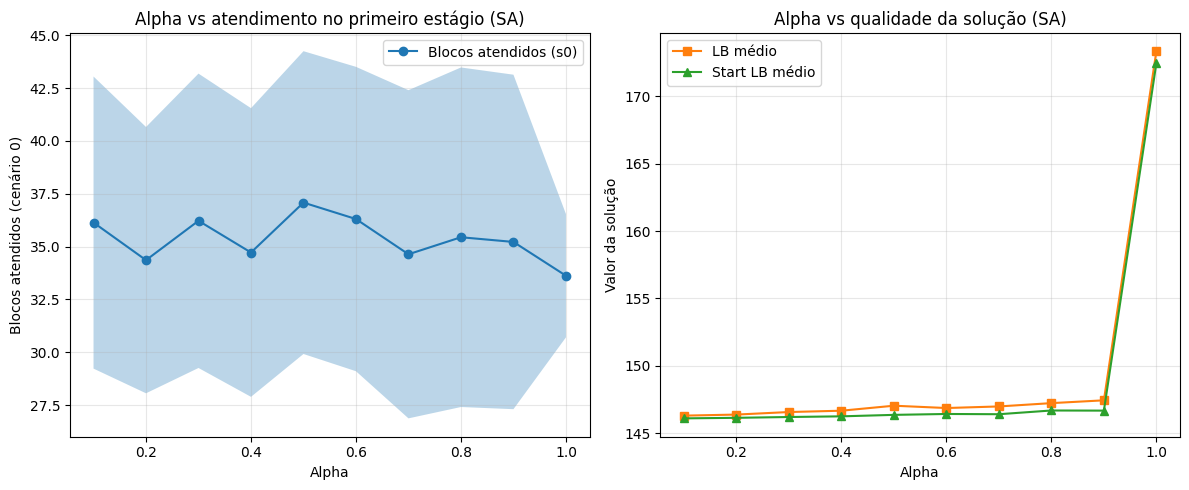

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axes
ax1.plot(by_alpha["alpha"], by_alpha["attended_s0_medio"], "o-", label="Blocos atendidos (s0)")
ax1.fill_between(
    by_alpha["alpha"],
    by_alpha["attended_s0_medio"] - by_alpha["attended_s0_std"].fillna(0),
    by_alpha["attended_s0_medio"] + by_alpha["attended_s0_std"].fillna(0),
    alpha=0.3,
)
ax1.set_xlabel("Alpha")
ax1.set_ylabel("Blocos atendidos (cenário 0)")
ax1.set_title("Alpha vs atendimento no primeiro estágio (SA)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(by_alpha["alpha"], by_alpha["LB_medio"], "s-", color="C1", label="LB médio")
ax2.plot(by_alpha["alpha"], by_alpha["Start_LB_medio"], "^-", color="C2", label="Start LB médio")
ax2.set_xlabel("Alpha")
ax2.set_ylabel("Valor da solução")
ax2.set_title("Alpha vs qualidade da solução (SA)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Quais parâmetros performaram melhor?

Ranking por LB médio; influência de temperature, alpha_sa, max_iters_sa, delta_type, first_improve, use_preprocessing.

In [310]:
# Top 20 combinações por LB médio
agg_sorted = agg.sort_values("LB_medio").head(20)
agg_sorted[["experiment", "LB_medio", "improvement_medio", "runtime_medio", "attended_s0_medio"]]

,experiment,LB_medio,improvement_medio,runtime_medio,attended_s0_medio
0,experiment-0.1-5.0-100-1.1-50-moderate-0-0,146.295611,0.202500,42.933497,36.138889
1,experiment-0.2-5.0-100-1.1-50-moderate-0-0,146.374333,0.240667,41.935001,34.361111
2,experiment-0.3-5.0-100-1.1-50-moderate-0-0,146.563111,0.369444,41.560590,36.222222
3,experiment-0.4-5.0-100-1.1-50-moderate-0-0,146.661444,0.418111,43.722398,34.722222
5,experiment-0.6-5.0-100-1.1-50-moderate-0-0,146.860444,0.441667,42.287288,36.305556
6,experiment-0.7-5.0-100-1.1-50-moderate-0-0,146.978000,0.577444,45.371468,34.638889
4,experiment-0.5-5.0-100-1.1-50-moderate-0-0,147.032222,0.679444,42.491429,37.083333
7,experiment-0.8-5.0-100-1.1-50-moderate-0-0,147.224000,0.546333,48.534977,35.444444
8,experiment-0.9-5.0-100-1.1-50-moderate-0-0,147.432111,0.764778,46.688136,35.222222
9,experiment-1.0-5.0-100-1.1-50-moderate-0-0,173.347500,0.882500,63.929540,33.625000


In [311]:
# Impacto de cada parâmetro: média de LB por nível
for param in ["alpha", "temperature", "temperature_max", "alpha_sa", "max_iters_sa", "delta_type", "first_improve", "use_preprocessing"]:
    if param not in df_all.columns:
        continue
    effect = df_all.groupby(param)["LB"].mean().sort_values()
    print(f"\n{param}: (menor LB = melhor)")
    print(effect.to_string())


alpha: (menor LB = melhor)
alpha
0.1    146.295611
0.2    146.374333
0.3    146.563111
0.4    146.661444
0.6    146.860444
0.7    146.978000
0.5    147.032222
0.8    147.224000
0.9    147.432111
1.0    173.347500

temperature: (menor LB = melhor)
temperature
5.0    148.653753

temperature_max: (menor LB = melhor)
temperature_max
100    148.653753

alpha_sa: (menor LB = melhor)
alpha_sa
1.1    148.653753

max_iters_sa: (menor LB = melhor)
max_iters_sa
50    148.653753

delta_type: (menor LB = melhor)
delta_type
moderate    148.653753

first_improve: (menor LB = melhor)
first_improve
0    148.653753

use_preprocessing: (menor LB = melhor)
use_preprocessing
0    148.653753


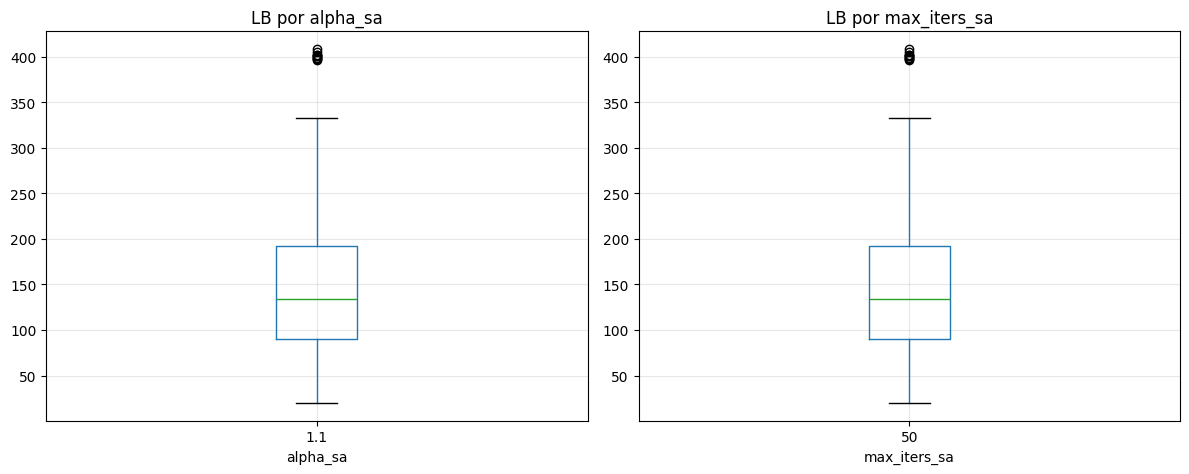

In [312]:
# Boxplot: LB por alpha_sa e por max_iters_sa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_all.boxplot(column="LB", by="alpha_sa", ax=axes[0])
axes[0].set_title("LB por alpha_sa")
axes[0].set_xlabel("alpha_sa")
df_all.boxplot(column="LB", by="max_iters_sa", ax=axes[1])
axes[1].set_title("LB por max_iters_sa")
axes[1].set_xlabel("max_iters_sa")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 4. Exportação LaTeX (apenas melhor configuração)

Exportamos uma única tabela com os resultados da **melhor combinação de parâmetros** (menor LB médio).

In [313]:
def export_best_sa_to_latex(df_full: pd.DataFrame, best_experiment: str, out_path: Path) -> str:
    df_best = df_full[df_full["experiment"] == best_experiment].copy()
    # Ordenar: cidade (alto-santo, limoeiro) -> tamanho (500, 1000, 2000) -> id (1, 2, 3, ...)
    df_best = df_best.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    caption = f"Results of Simulated Annealing for stochastic instances (best config: {best_experiment})."
    label = "tab:sa-stochastic-best"
    latex = export_sa_best_to_latex(df_best, caption=caption, label=label, use_rowcolor=True)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(latex, encoding="utf-8")
    return latex

In [314]:
OUT_LATEX_SA = Path("latex-tables-sa")
best_exp = agg.sort_values("LB_medio").iloc[0]["experiment"]
latex_str = export_best_sa_to_latex(df_all, best_exp, OUT_LATEX_SA / "table-sa-best.tex")
print(f"Melhor configuração: {best_exp}")
print(f"Tabela salva em {OUT_LATEX_SA / 'table-sa-best.tex'}")
print("\n--- Prévia LaTeX ---\n")
print(latex_str[:2000])

Melhor configuração: experiment-0.1-5.0-100-1.1-50-moderate-0-0
Tabela salva em latex-tables-sa/table-sa-best.tex

--- Prévia LaTeX ---

\begin{table}[ht!]
\centering
\caption{Results of Simulated Annealing for stochastic instances (best config: experiment-0.1-5.0-100-1.1-50-moderate-0-0).}
\label{tab:sa-stochastic-best}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrr}
\toprule
\multicolumn{1}{c}{\textbf{Instance}} & \multicolumn{1}{c}{\textbf{|V|}} & \multicolumn{1}{c}{\textbf{|A|}} & \multicolumn{1}{c}{\textbf{|B|}} & \multicolumn{1}{c}{\textbf{Alpha}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Start\\ LB\end{tabular}}} & \multicolumn{1}{c}{\textbf{LB}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Improve.\end{tabular}}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Att.\\ (s0)\end{tabular}}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Time (s)\end{tabular}}} \\
\midrule
\rowcolor{rowlight}alto-santo-500-1 & 117 & 336 & 52 & 0,1 & 

## 5. Foco na melhor configuração SA — Análise por alpha

Analogamente à análise do modelo estocástico, isolamos a melhor configuração SA (parâmetros excluindo alpha) e analisamos como o alpha impacta a qualidade das soluções.

O **alpha** controla o peso dado ao primeiro estágio na função objetivo. Alphas maiores priorizam a solução determinística (cenário 0), enquanto alphas menores dão mais peso aos cenários estocásticos.

In [315]:
# Identificar melhor configuração SA (menor LB médio, excluindo alpha)
agg_sa_config = df_all.groupby("sa_config").agg(
    LB_medio=("LB", "mean"),
    improvement_medio=("improvement", "mean"),
    attended_s0_medio=("attended_s0", "mean"),
    runtime_medio=("Runtime", "mean"),
    n_alphas=("alpha", "nunique"),
    n_results=("instance_name", "count"),
).reset_index().sort_values("LB_medio")

best_sa_config = agg_sa_config.iloc[0]["sa_config"]
print(f"Melhor configuração SA (menor LB médio): {best_sa_config}")
print(f"LB médio: {agg_sa_config.iloc[0]['LB_medio']:.2f}")
print(f"Improvement médio: {agg_sa_config.iloc[0]['improvement_medio']:.2f}")
print(f"Nº de alphas testados: {int(agg_sa_config.iloc[0]['n_alphas'])}")
print()
agg_sa_config.head(10)

Melhor configuração SA (menor LB médio): temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-0-p-0
LB médio: 148.65
Improvement médio: 0.50
Nº de alphas testados: 10



,sa_config,LB_medio,improvement_medio,attended_s0_medio,runtime_medio,n_alphas,n_results
0,temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-...,148.653753,0.499523,35.436782,45.325291,10,348


In [316]:
# Filtrar melhor config e analisar por alpha
df_best = df_all[df_all["sa_config"] == best_sa_config].copy()
df_best = df_best.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
print(f"Config: {best_sa_config}")
print(f"Resultados: {len(df_best)}, Instâncias: {df_best['instance_name'].nunique()}, Alphas: {df_best['alpha'].nunique()}")

by_alpha = df_best.groupby("alpha").agg(
    LB_medio=("LB", "mean"),
    LB_std=("LB", "std"),
    Start_LB_medio=("Start_LB", "mean"),
    improvement_medio=("improvement", "mean"),
    improvement_pct_medio=("improvement_pct", "mean"),
    attended_s0_medio=("attended_s0", "mean"),
    attended_s0_std=("attended_s0", "std"),
    runtime_medio=("Runtime", "mean"),
    n_results=("LB", "count"),
).reset_index()
by_alpha

Config: temp-5.0-tmax-100-asa-1.1-mi-50-d-moderate-fi-0-p-0
Resultados: 348, Instâncias: 36, Alphas: 10


,alpha,LB_medio,LB_std,Start_LB_medio,improvement_medio,improvement_pct_medio,attended_s0_medio,attended_s0_std,runtime_medio,n_results
0,0.1,146.295611,83.354647,146.093111,0.202500,0.091325,36.138889,6.908185,42.933497,36
1,0.2,146.374333,83.277378,146.133667,0.240667,0.146830,34.361111,6.298085,41.935001,36
2,0.3,146.563111,83.505599,146.193667,0.369444,0.230891,36.222222,6.961573,41.560590,36
3,0.4,146.661444,83.574422,146.243333,0.418111,0.270319,34.722222,6.826884,43.722398,36
4,0.5,147.032222,84.323401,146.352778,0.679444,0.356839,37.083333,7.160906,42.491429,36
5,0.6,146.860444,83.699167,146.418778,0.441667,0.284964,36.305556,7.198490,42.287288,36
6,0.7,146.978000,83.666674,146.400556,0.577444,0.437006,34.638889,7.761269,45.371468,36
7,0.8,147.224000,83.811404,146.677667,0.546333,0.402956,35.444444,8.030102,48.534977,36
8,0.9,147.432111,84.135439,146.667333,0.764778,0.510132,35.222222,7.910612,46.688136,36
9,1.0,173.347500,83.478841,172.465000,0.882500,0.574880,33.625000,2.916408,63.929540,24


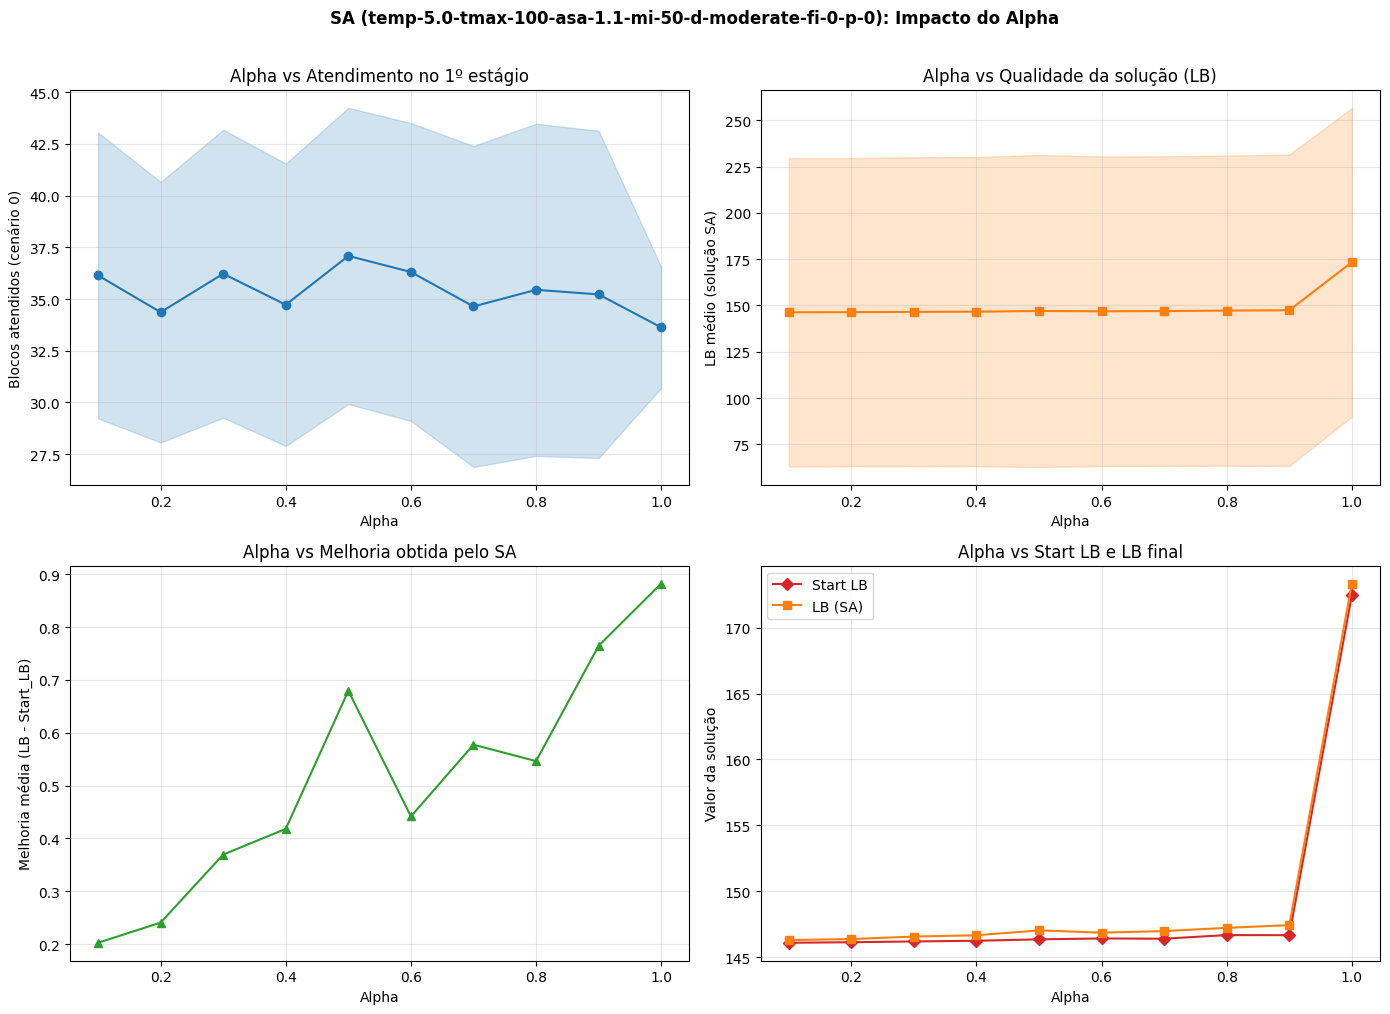

In [317]:
# 2x2 plot: Alpha vs (attended_s0, LB, improvement, Start_LB vs LB)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(by_alpha["alpha"], by_alpha["attended_s0_medio"], "o-", color="C0")
ax.fill_between(
    by_alpha["alpha"],
    by_alpha["attended_s0_medio"] - by_alpha["attended_s0_std"].fillna(0),
    by_alpha["attended_s0_medio"] + by_alpha["attended_s0_std"].fillna(0),
    alpha=0.2, color="C0",
)
ax.set_xlabel("Alpha")
ax.set_ylabel("Blocos atendidos (cenário 0)")
ax.set_title("Alpha vs Atendimento no 1º estágio")

ax = axes[0, 1]
ax.plot(by_alpha["alpha"], by_alpha["LB_medio"], "s-", color="C1")
ax.fill_between(
    by_alpha["alpha"],
    by_alpha["LB_medio"] - by_alpha["LB_std"].fillna(0),
    by_alpha["LB_medio"] + by_alpha["LB_std"].fillna(0),
    alpha=0.2, color="C1",
)
ax.set_xlabel("Alpha")
ax.set_ylabel("LB médio (solução SA)")
ax.set_title("Alpha vs Qualidade da solução (LB)")

ax = axes[1, 0]
ax.plot(by_alpha["alpha"], by_alpha["improvement_medio"], "^-", color="C2")
ax.set_xlabel("Alpha")
ax.set_ylabel("Melhoria média (LB - Start_LB)")
ax.set_title("Alpha vs Melhoria obtida pelo SA")

ax = axes[1, 1]
ax.plot(by_alpha["alpha"], by_alpha["Start_LB_medio"], "D-", color="C3", label="Start LB")
ax.plot(by_alpha["alpha"], by_alpha["LB_medio"], "s-", color="C1", label="LB (SA)")
ax.set_xlabel("Alpha")
ax.set_ylabel("Valor da solução")
ax.set_title("Alpha vs Start LB e LB final")
ax.legend()

plt.suptitle(f"SA ({best_sa_config}): Impacto do Alpha", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Integração com dados de entrada (grafos e cenários)

Carregamos os dados dos grafos e cenários para cruzar com os resultados do SA. Isso permite calcular:
- **B_total**: total de blocos na instância
- **att_s0_pct_blocks**: % dos blocos atendidos no cenário 0
- **total_cases_det**: total de casos no cenário determinístico
- Correlações entre estrutura da instância e qualidade da solução

In [318]:
# Carregar dados de entrada (grafos + cenários)
inst_data = load_all_instance_data(INSTANCE_FOLDERS)
print(f"Instâncias carregadas: {len(inst_data)}")

input_rows = []
for name, info in inst_data.items():
    g = info["graph"]
    sc = info.get("scenarios", {})
    avg_scenario_cases = 0
    if sc and sc.get("scenarios"):
        avg_scenario_cases = np.mean([s["total_cases"] for s in sc["scenarios"]])
    input_rows.append({
        "instance_name": name,
        "N_input": g["N"], "M_input": g["M"], "B_total": g["B"],
        "blocks_with_cases": g["blocks_with_cases"],
        "total_cases_det": g["total_cases"],
        "S": sc.get("S", 0),
        "avg_cases_per_scenario": avg_scenario_cases,
    })
df_input = pd.DataFrame(input_rows)
df_input = df_input.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
df_input

Instâncias carregadas: 36


,instance_name,N_input,M_input,B_total,blocks_with_cases,total_cases_det,S,avg_cases_per_scenario
12,alto-santo-500-1,117,336,52,31,142,50,29.92
13,alto-santo-500-2,117,336,52,14,33,50,32.60
14,alto-santo-500-3,117,336,52,23,76,50,30.18
15,alto-santo-500-4,117,336,52,22,60,50,30.58
16,alto-santo-500-5,117,336,52,17,53,50,30.72
17,alto-santo-500-6,117,336,52,32,157,50,32.82
0,alto-santo-1000-1,179,524,84,42,173,50,50.88
1,alto-santo-1000-2,179,524,84,18,38,50,51.52
2,alto-santo-1000-3,179,524,84,31,99,50,50.48
3,alto-santo-1000-4,179,524,84,30,81,50,46.70


In [319]:
# Cruzar dados de entrada com resultados da melhor config SA
df_merged = df_best.merge(df_input, on="instance_name", how="left")

df_merged["att_s0_pct_blocks"] = 100 * df_merged["attended_s0"] / df_merged["B_total"]

# Resumo por alpha: atendimento, cobertura e qualidade
att_summary = df_merged.groupby("alpha").agg(
    att_s0_medio=("attended_s0", "mean"),
    att_s0_pct_medio=("att_s0_pct_blocks", "mean"),
    B_medio=("B_total", "mean"),
    cases_det_medio=("total_cases_det", "mean"),
    LB_medio=("LB", "mean"),
    improvement_medio=("improvement", "mean"),
    runtime_medio=("Runtime", "mean"),
).reset_index()
print("Resumo por alpha (melhor config SA):")
att_summary

Resumo por alpha (melhor config SA):


,alpha,att_s0_medio,att_s0_pct_medio,B_medio,cases_det_medio,LB_medio,improvement_medio,runtime_medio
0,0.1,36.138889,39.514960,182.0,161.444444,146.295611,0.202500,42.933497
1,0.2,34.361111,36.045951,182.0,161.444444,146.374333,0.240667,41.935001
2,0.3,36.222222,39.558928,182.0,161.444444,146.563111,0.369444,41.560590
3,0.4,34.722222,36.833099,182.0,161.444444,146.661444,0.418111,43.722398
4,0.5,37.083333,40.758618,182.0,161.444444,147.032222,0.679444,42.491429
5,0.6,36.305556,39.256234,182.0,161.444444,146.860444,0.441667,42.287288
6,0.7,34.638889,36.233365,182.0,161.444444,146.978000,0.577444,45.371468
7,0.8,35.444444,38.116461,182.0,161.444444,147.224000,0.546333,48.534977
8,0.9,35.222222,37.603788,182.0,161.444444,147.432111,0.764778,46.688136
9,1.0,33.625000,24.222839,241.5,204.583333,173.347500,0.882500,63.929540


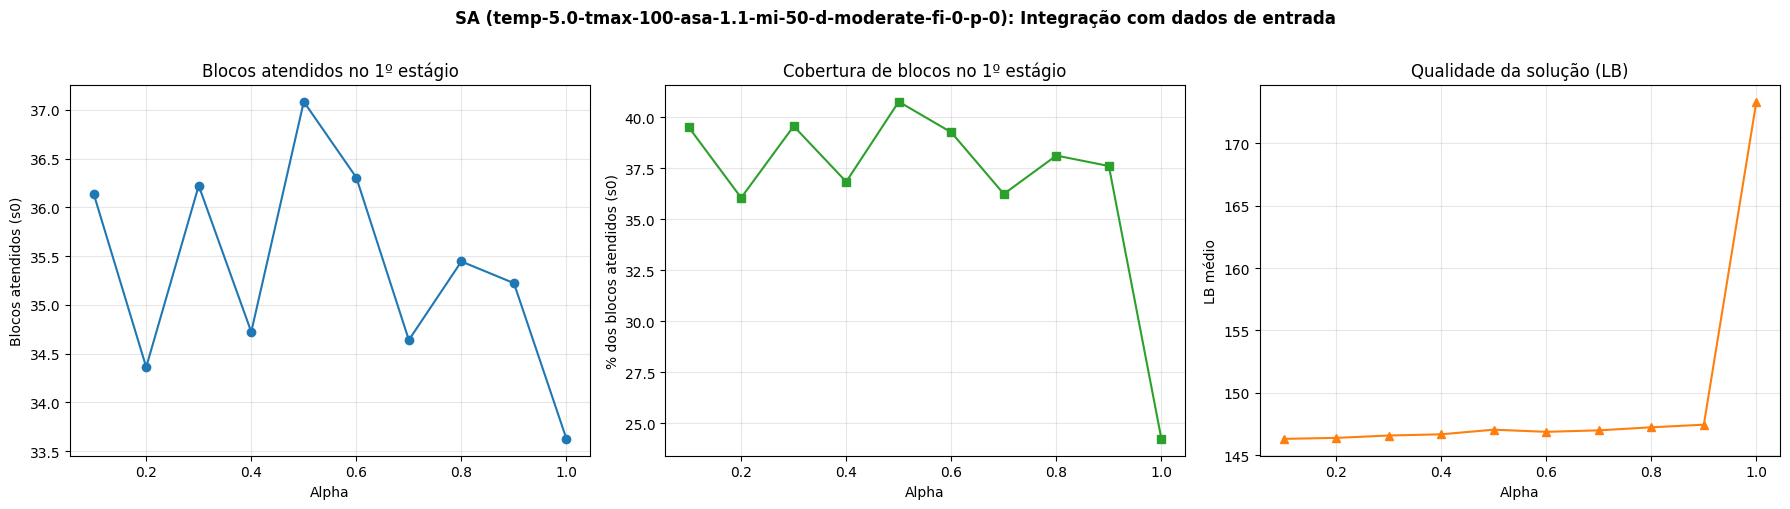

In [320]:
# Plot: Alpha vs (blocos atendidos, % blocos, LB)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(att_summary["alpha"], att_summary["att_s0_medio"], "o-", color="C0")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Blocos atendidos (s0)")
axes[0].set_title("Blocos atendidos no 1º estágio")

axes[1].plot(att_summary["alpha"], att_summary["att_s0_pct_medio"], "s-", color="C2")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("% dos blocos atendidos (s0)")
axes[1].set_title("Cobertura de blocos no 1º estágio")

axes[2].plot(att_summary["alpha"], att_summary["LB_medio"], "^-", color="C1")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("LB médio")
axes[2].set_title("Qualidade da solução (LB)")

plt.suptitle(f"SA ({best_sa_config}): Integração com dados de entrada", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [321]:
# Tabela detalhada por instância para alphas selecionados
alpha_values = sorted(df_merged["alpha"].unique())
selected_alphas = [alpha_values[0], alpha_values[len(alpha_values)//2], alpha_values[-1]]

for a in selected_alphas:
    sub = df_merged[df_merged["alpha"] == a][[
        "instance_name", "B_total", "total_cases_det",
        "attended_s0", "att_s0_pct_blocks", "Start_LB", "LB", "improvement", "Runtime"
    ]].copy()
    sub = sub.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    print(f"\n=== Alpha = {a} ===")
    print(sub.to_string(index=False))


=== Alpha = 0.1 ===
    instance_name  B_total  total_cases_det  attended_s0  att_s0_pct_blocks  Start_LB      LB  improvement   Runtime
 alto-santo-500-1       52              142           46          88.461538   171.920 171.920        0.000   3.93902
 alto-santo-500-2       52               33           47          90.384615    65.600  65.600        0.000   5.32459
 alto-santo-500-3       52               76           39          75.000000   106.180 106.180        0.000   2.90703
 alto-santo-500-4       52               60           48          92.307692    90.580  90.580        0.000   4.82034
 alto-santo-500-5       52               53           47          90.384615    83.720  83.720        0.000   5.04820
 alto-santo-500-6       52              157           45          86.538462   189.820 189.820        0.000   3.79497
alto-santo-1000-1       84              173           39          46.428571   219.880 220.880        1.000  17.25240
alto-santo-1000-2       84               38

## 7. Análise por instância — Impacto do alpha na qualidade do LB

Visualização detalhada de como cada instância responde ao alpha, separando por cidade.
Permite identificar se o comportamento é homogêneo ou se instâncias maiores/mais complexas reagem de forma diferente.

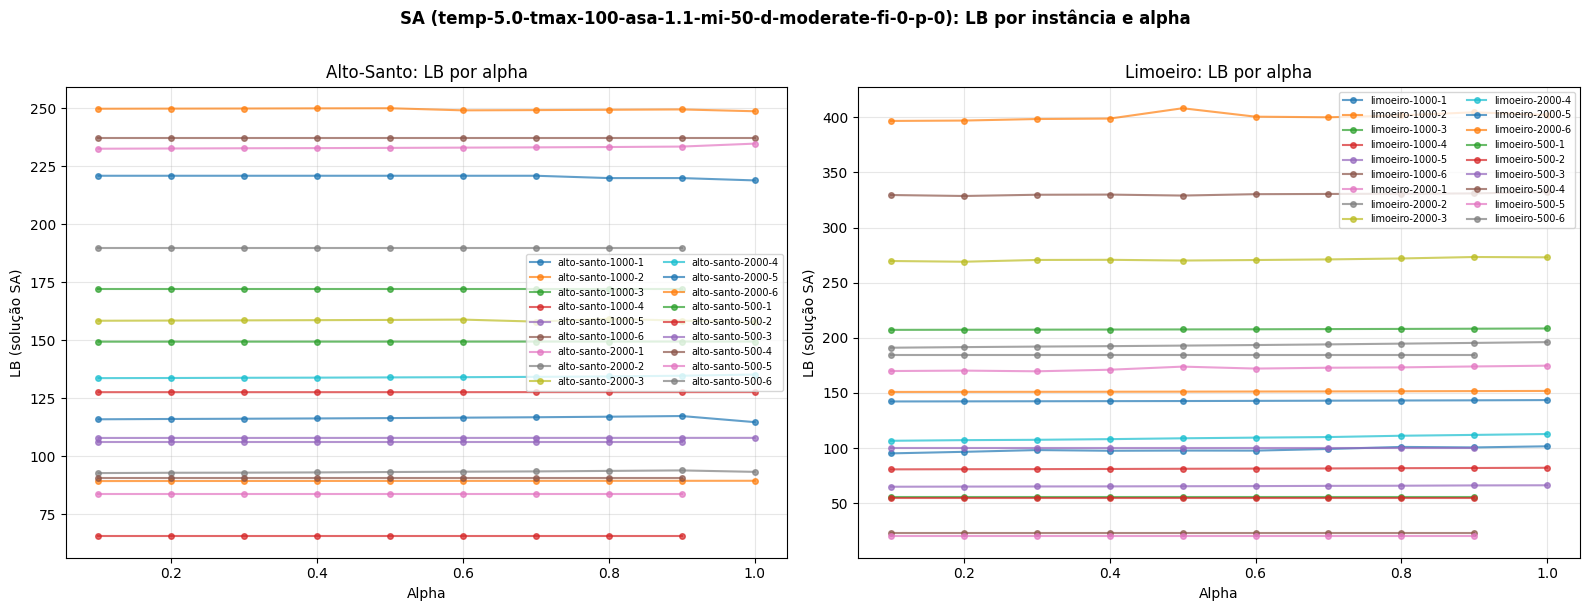

In [322]:
# LB por alpha para cada instância, separado por cidade
cities = sorted(df_best["city"].unique())
fig, axes = plt.subplots(1, len(cities), figsize=(8 * len(cities), 6))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_best[df_best["city"] == city]
    for inst_name, grp in city_data.groupby("instance_name"):
        grp_sorted = grp.sort_values("alpha")
        ax.plot(grp_sorted["alpha"], grp_sorted["LB"], "o-", label=inst_name, markersize=4, alpha=0.7)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("LB (solução SA)")
    ax.set_title(f"{city.title()}: LB por alpha")
    ax.legend(fontsize=7, ncol=2)

plt.suptitle(f"SA ({best_sa_config}): LB por instância e alpha", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

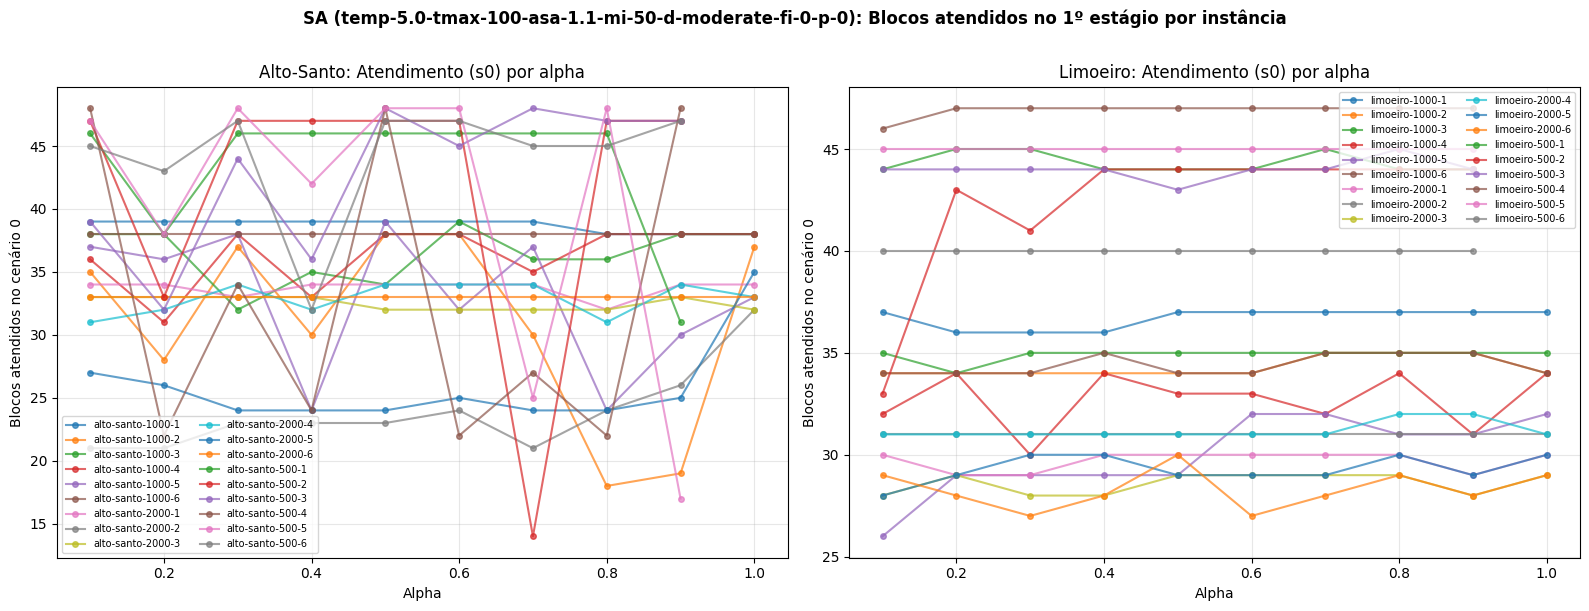

In [323]:
# Blocos atendidos (s0) por alpha para cada instância, separado por cidade
fig, axes = plt.subplots(1, len(cities), figsize=(8 * len(cities), 6))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_best[df_best["city"] == city]
    for inst_name, grp in city_data.groupby("instance_name"):
        grp_sorted = grp.sort_values("alpha")
        ax.plot(grp_sorted["alpha"], grp_sorted["attended_s0"], "o-", label=inst_name, markersize=4, alpha=0.7)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Blocos atendidos no cenário 0")
    ax.set_title(f"{city.title()}: Atendimento (s0) por alpha")
    ax.legend(fontsize=7, ncol=2)

plt.suptitle(f"SA ({best_sa_config}): Blocos atendidos no 1º estágio por instância", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

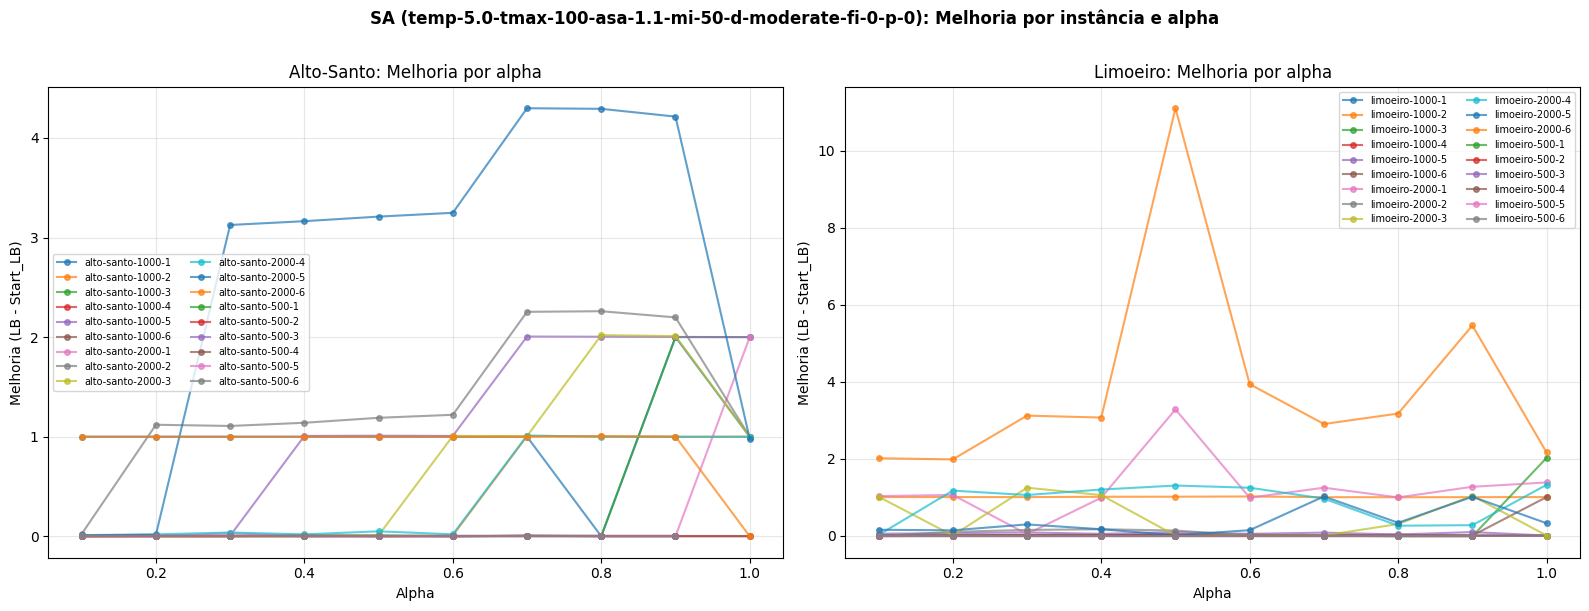

In [324]:
# Melhoria (improvement) por alpha para cada instância, separado por cidade
fig, axes = plt.subplots(1, len(cities), figsize=(8 * len(cities), 6))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_best[df_best["city"] == city]
    for inst_name, grp in city_data.groupby("instance_name"):
        grp_sorted = grp.sort_values("alpha")
        ax.plot(grp_sorted["alpha"], grp_sorted["improvement"], "o-", label=inst_name, markersize=4, alpha=0.7)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Melhoria (LB - Start_LB)")
    ax.set_title(f"{city.title()}: Melhoria por alpha")
    ax.legend(fontsize=7, ncol=2)

plt.suptitle(f"SA ({best_sa_config}): Melhoria por instância e alpha", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 8. Heterogeneidade — Entendendo a variação do LB

Análise por cidade e tamanho do mapa para entender se a resposta ao alpha é uniforme ou se depende das características da instância. Heatmap de LB por instância × alpha para visualizar a heterogeneidade.

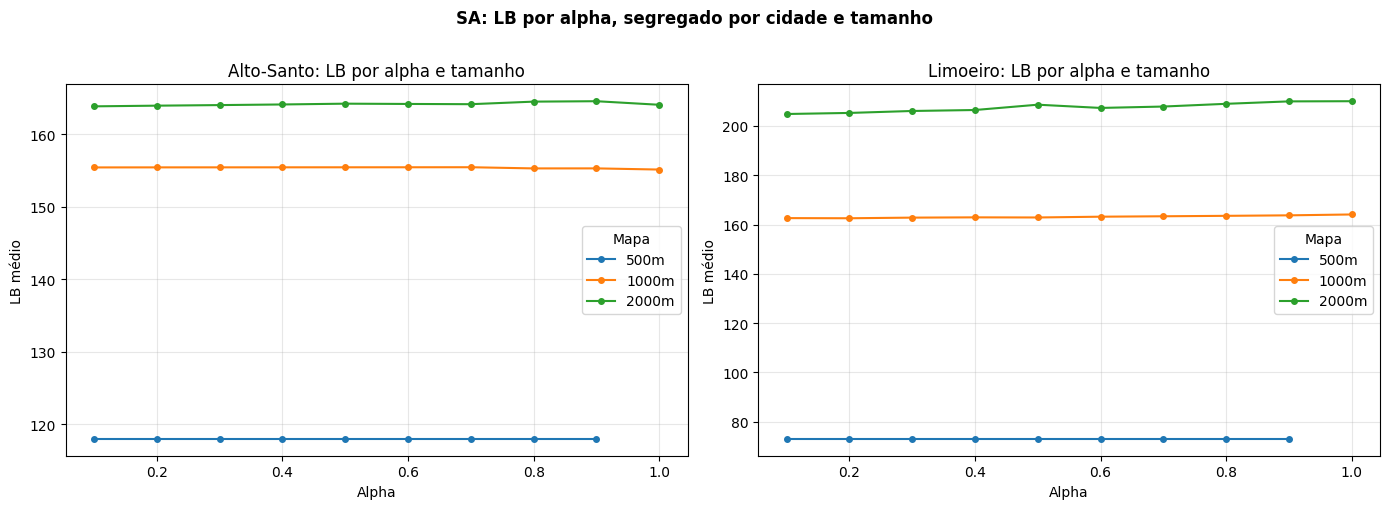

In [325]:
# LB médio por alpha, segregado por cidade e tamanho do mapa
fig, axes = plt.subplots(1, len(cities), figsize=(7 * len(cities), 5))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_merged[df_merged["city"] == city]
    for size, grp in city_data.groupby("map_size"):
        by_a = grp.groupby("alpha")["LB"].mean()
        ax.plot(by_a.index, by_a.values, "o-", label=f"{size}m", markersize=4)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("LB médio")
    ax.set_title(f"{city.title()}: LB por alpha e tamanho")
    ax.legend(title="Mapa")

plt.suptitle("SA: LB por alpha, segregado por cidade e tamanho", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

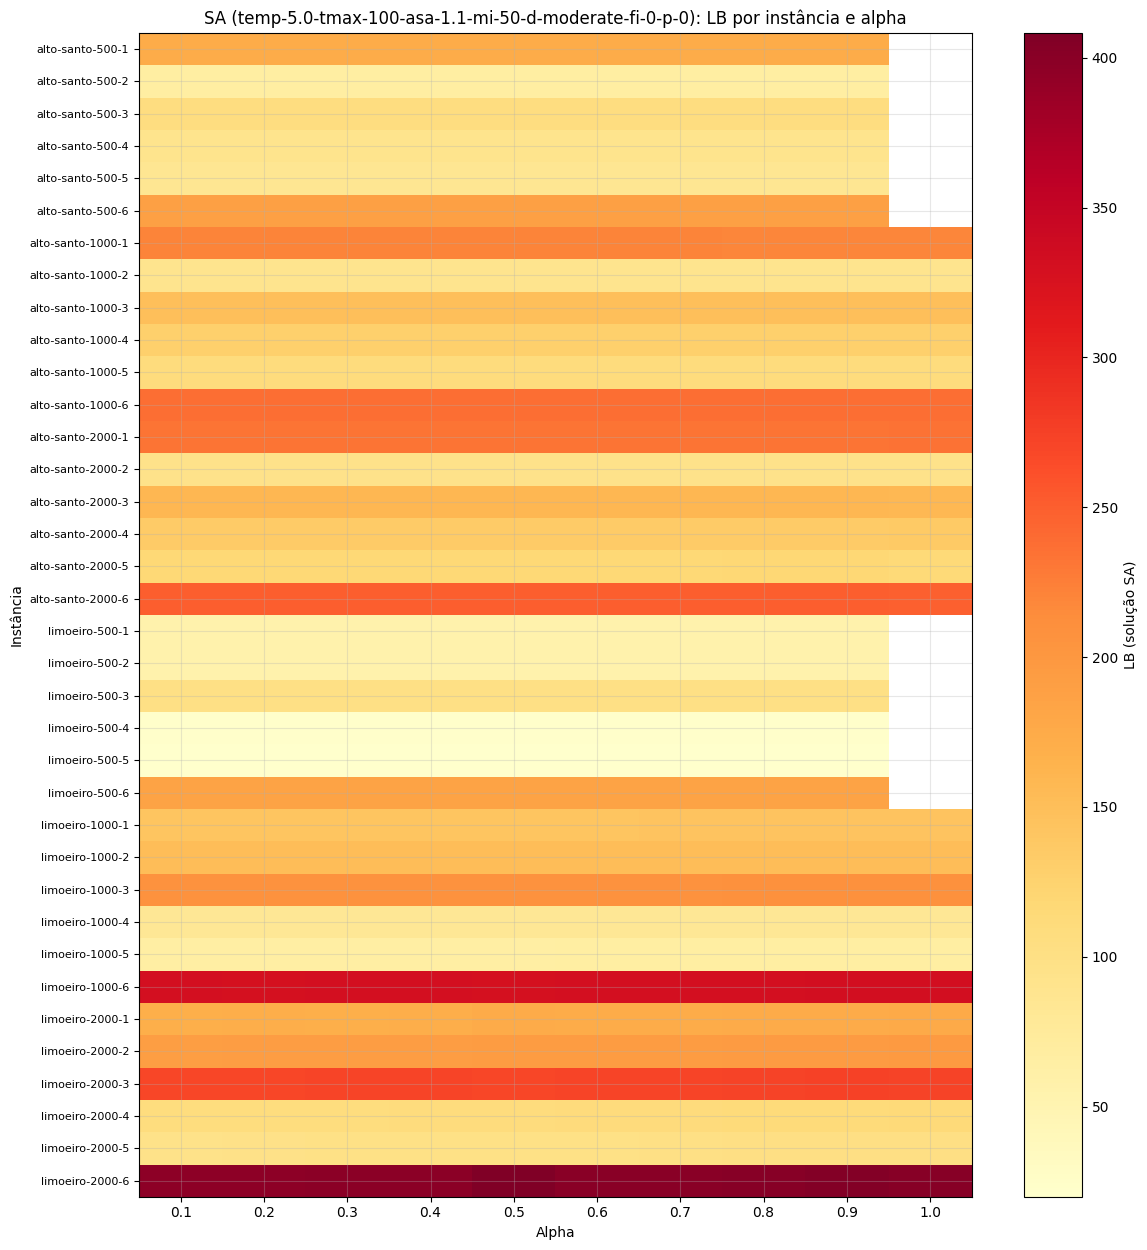

In [326]:
# Heatmap: LB por (instância × alpha) para ver a heterogeneidade
pivot_lb = df_best.pivot_table(index="instance_name", columns="alpha", values="LB")
pivot_lb = pivot_lb.loc[sorted(pivot_lb.index, key=instance_sort_key)]

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot_lb) * 0.35)))
im = ax.imshow(pivot_lb.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot_lb.columns)))
ax.set_xticklabels([f"{a:.1f}" for a in pivot_lb.columns])
ax.set_yticks(range(len(pivot_lb.index)))
ax.set_yticklabels(pivot_lb.index, fontsize=8)
ax.set_xlabel("Alpha")
ax.set_ylabel("Instância")
ax.set_title(f"SA ({best_sa_config}): LB por instância e alpha")
plt.colorbar(im, label="LB (solução SA)")
plt.tight_layout()
plt.show()

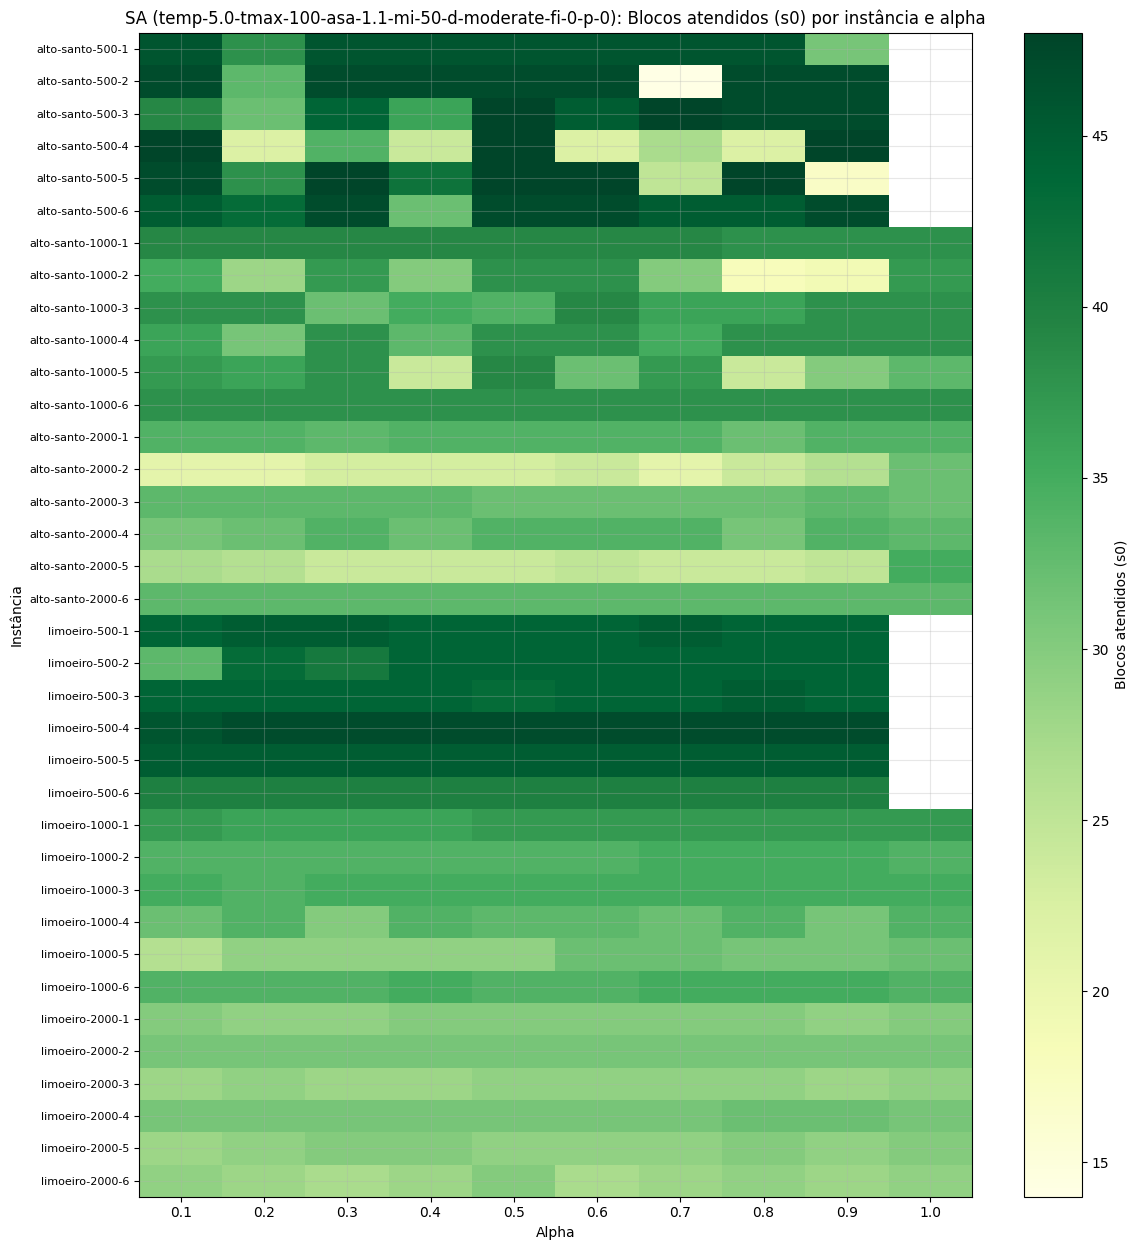

In [327]:
# Heatmap: Blocos atendidos (s0) por (instância × alpha)
pivot_att = df_best.pivot_table(index="instance_name", columns="alpha", values="attended_s0")
pivot_att = pivot_att.loc[sorted(pivot_att.index, key=instance_sort_key)]

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot_att) * 0.35)))
im = ax.imshow(pivot_att.values, aspect="auto", cmap="YlGn")
ax.set_xticks(range(len(pivot_att.columns)))
ax.set_xticklabels([f"{a:.1f}" for a in pivot_att.columns])
ax.set_yticks(range(len(pivot_att.index)))
ax.set_yticklabels(pivot_att.index, fontsize=8)
ax.set_xlabel("Alpha")
ax.set_ylabel("Instância")
ax.set_title(f"SA ({best_sa_config}): Blocos atendidos (s0) por instância e alpha")
plt.colorbar(im, label="Blocos atendidos (s0)")
plt.tight_layout()
plt.show()

In [328]:
# Correlação entre características do input e LB para um alpha fixo
ref_alpha = alpha_values[-1]  # maior alpha
sub_corr = df_merged[df_merged["alpha"] == ref_alpha].copy()
print(f"Correlação com LB (alpha={ref_alpha}):")
for col in ["N_input", "M_input", "B_total", "total_cases_det", "blocks_with_cases"]:
    if col in sub_corr.columns:
        corr = sub_corr["LB"].corr(sub_corr[col])
        print(f"  {col}: r = {corr:.3f}")

print(f"\nCorrelação com attended_s0 (alpha={ref_alpha}):")
for col in ["N_input", "M_input", "B_total", "total_cases_det", "blocks_with_cases"]:
    if col in sub_corr.columns:
        corr = sub_corr["attended_s0"].corr(sub_corr[col])
        print(f"  {col}: r = {corr:.3f}")

print(f"\nCorrelação com improvement (alpha={ref_alpha}):")
for col in ["N_input", "M_input", "B_total", "total_cases_det", "blocks_with_cases"]:
    if col in sub_corr.columns:
        corr = sub_corr["improvement"].corr(sub_corr[col])
        print(f"  {col}: r = {corr:.3f}")

Correlação com LB (alpha=1.0):
  N_input: r = 0.260
  M_input: r = 0.258
  B_total: r = 0.255
  total_cases_det: r = 0.887
  blocks_with_cases: r = 0.741

Correlação com attended_s0 (alpha=1.0):
  N_input: r = -0.774
  M_input: r = -0.765
  B_total: r = -0.747
  total_cases_det: r = -0.444
  blocks_with_cases: r = -0.580

Correlação com improvement (alpha=1.0):
  N_input: r = -0.055
  M_input: r = -0.060
  B_total: r = -0.067
  total_cases_det: r = 0.210
  blocks_with_cases: r = 0.119


In [329]:
# Resumo por cidade e tamanho do mapa (melhor config)
agg_city = df_merged.groupby(["city", "map_size"]).agg(
    LB_medio=("LB", "mean"),
    Start_LB_medio=("Start_LB", "mean"),
    improvement_medio=("improvement", "mean"),
    att_s0_medio=("attended_s0", "mean"),
    att_s0_pct_medio=("att_s0_pct_blocks", "mean"),
    runtime_medio=("Runtime", "mean"),
    n=("instance_name", "count"),
).reset_index()
print("Resumo por cidade e tamanho do mapa:")
agg_city

Resumo por cidade e tamanho do mapa:


,city,map_size,LB_medio,Start_LB_medio,improvement_medio,att_s0_medio,att_s0_pct_medio,runtime_medio,n
0,alto-santo,500,117.970000,117.970000,0.000000,40.870370,78.596866,4.317279,54
1,alto-santo,1000,155.397433,154.912033,0.485400,35.566667,42.341270,18.807591,60
2,alto-santo,2000,164.187367,163.148333,1.039033,30.283333,29.689542,28.249480,60
3,limoeiro,500,73.003333,73.003333,0.000000,43.759259,59.134134,3.026278,54
4,limoeiro,1000,163.162067,162.934000,0.228067,33.833333,14.646465,75.712457,60
5,limoeiro,2000,207.568900,206.424167,1.144733,29.683333,5.406800,133.507958,60


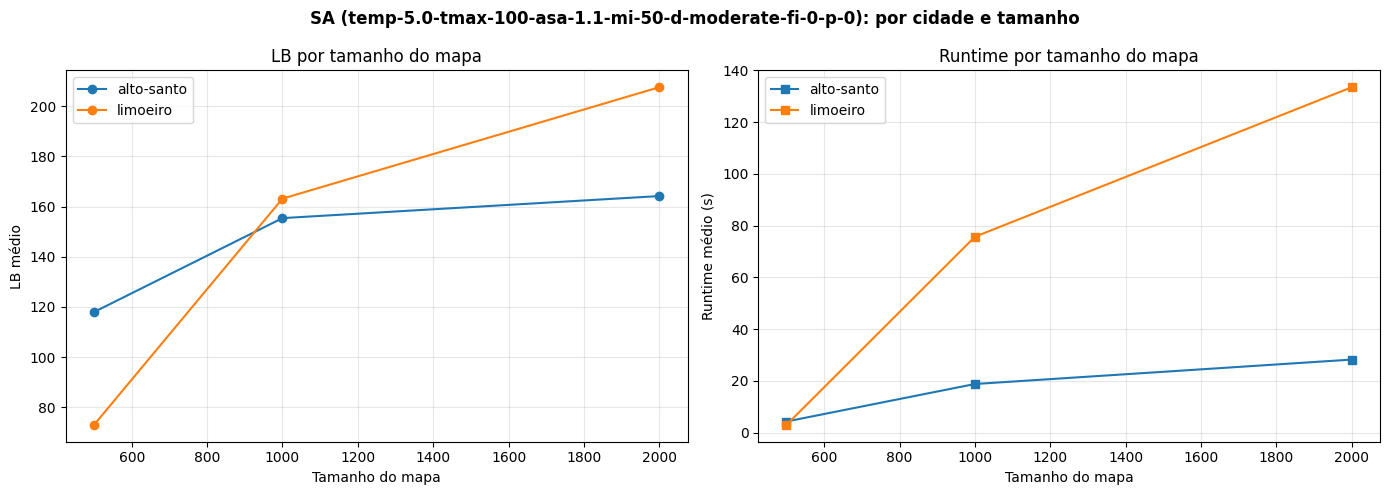

In [330]:
# Gráficos por cidade e mapa: LB e Runtime
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for city in df_merged["city"].unique():
    sub = agg_city[agg_city["city"] == city].sort_values("map_size")
    axes[0].plot(sub["map_size"], sub["LB_medio"], "o-", label=city)
    axes[1].plot(sub["map_size"], sub["runtime_medio"], "s-", label=city)

axes[0].set_xlabel("Tamanho do mapa")
axes[0].set_ylabel("LB médio")
axes[0].set_title("LB por tamanho do mapa")
axes[0].legend()
axes[1].set_xlabel("Tamanho do mapa")
axes[1].set_ylabel("Runtime médio (s)")
axes[1].set_title("Runtime por tamanho do mapa")
axes[1].legend()
plt.suptitle(f"SA ({best_sa_config}): por cidade e tamanho", fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Blocos atendidos no 1º estágio — Grafo de linhas por instância

Para a configuração alvo (temp=5.0, tmax=100, asa=1.1, mi=50, moderate, fi=0, p=0), visualizamos como o número de blocos atendidos no cenário 0 varia com o alpha para **cada instância**.

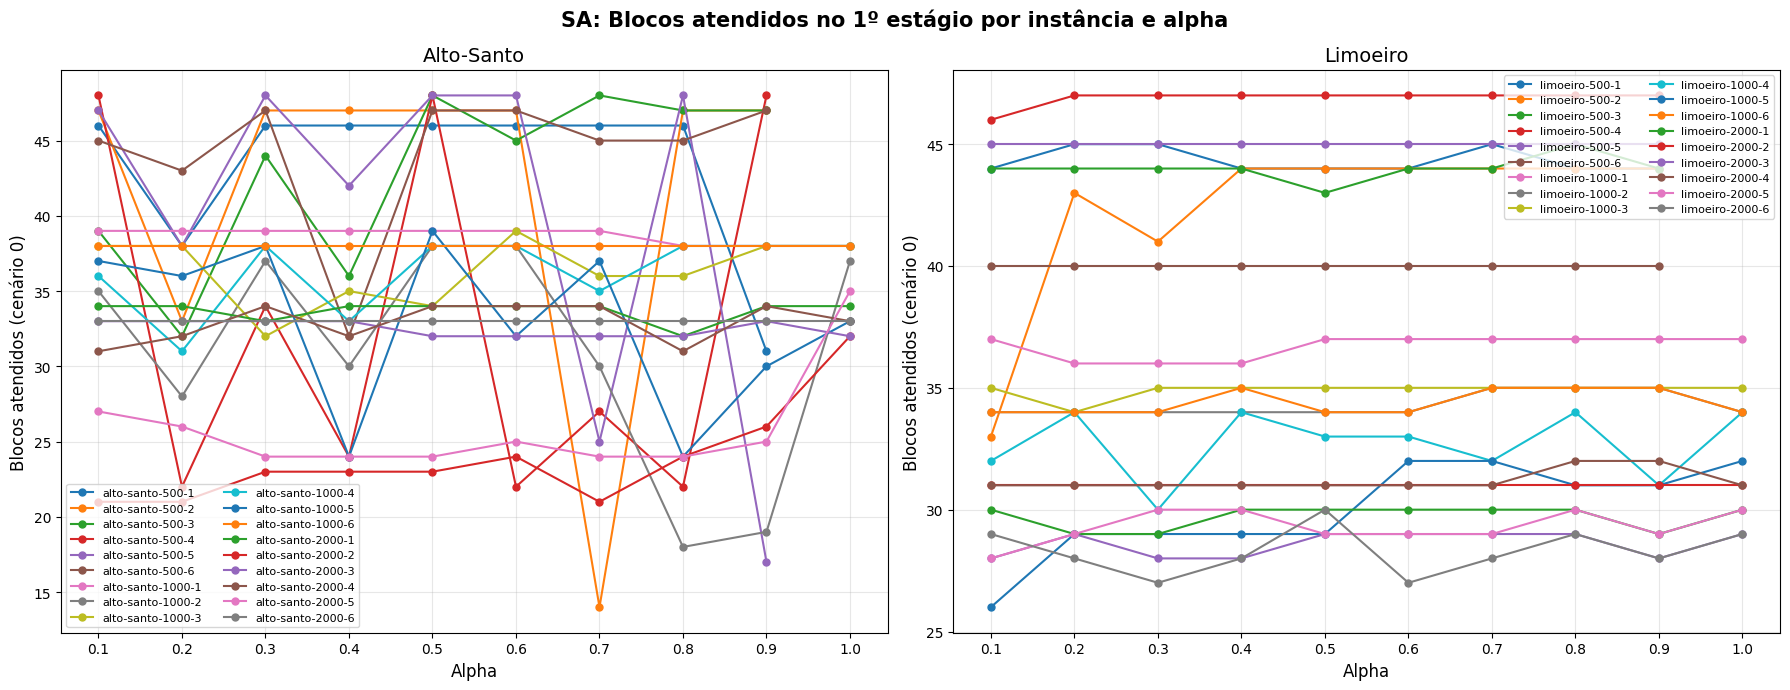

In [331]:
# Grafo de linhas: blocos atendidos (s0) por alpha, uma linha por instância
# Separado por cidade para melhor legibilidade
cities = sorted(df_all["city"].unique())
fig, axes = plt.subplots(1, len(cities), figsize=(9 * len(cities), 7))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_all[df_all["city"] == city]
    instances_sorted = sorted(city_data["instance_name"].unique(), key=instance_sort_key)
    for inst in instances_sorted:
        grp = city_data[city_data["instance_name"] == inst].sort_values("alpha")
        ax.plot(grp["alpha"], grp["attended_s0"], "o-", label=inst, markersize=5, linewidth=1.5)
    ax.set_xlabel("Alpha", fontsize=12)
    ax.set_ylabel("Blocos atendidos (cenário 0)", fontsize=12)
    ax.set_title(f"{city.title()}", fontsize=14)
    ax.legend(fontsize=8, ncol=2, loc="best")
    ax.set_xticks(sorted(df_all["alpha"].unique()))

plt.suptitle("SA: Blocos atendidos no 1º estágio por instância e alpha", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

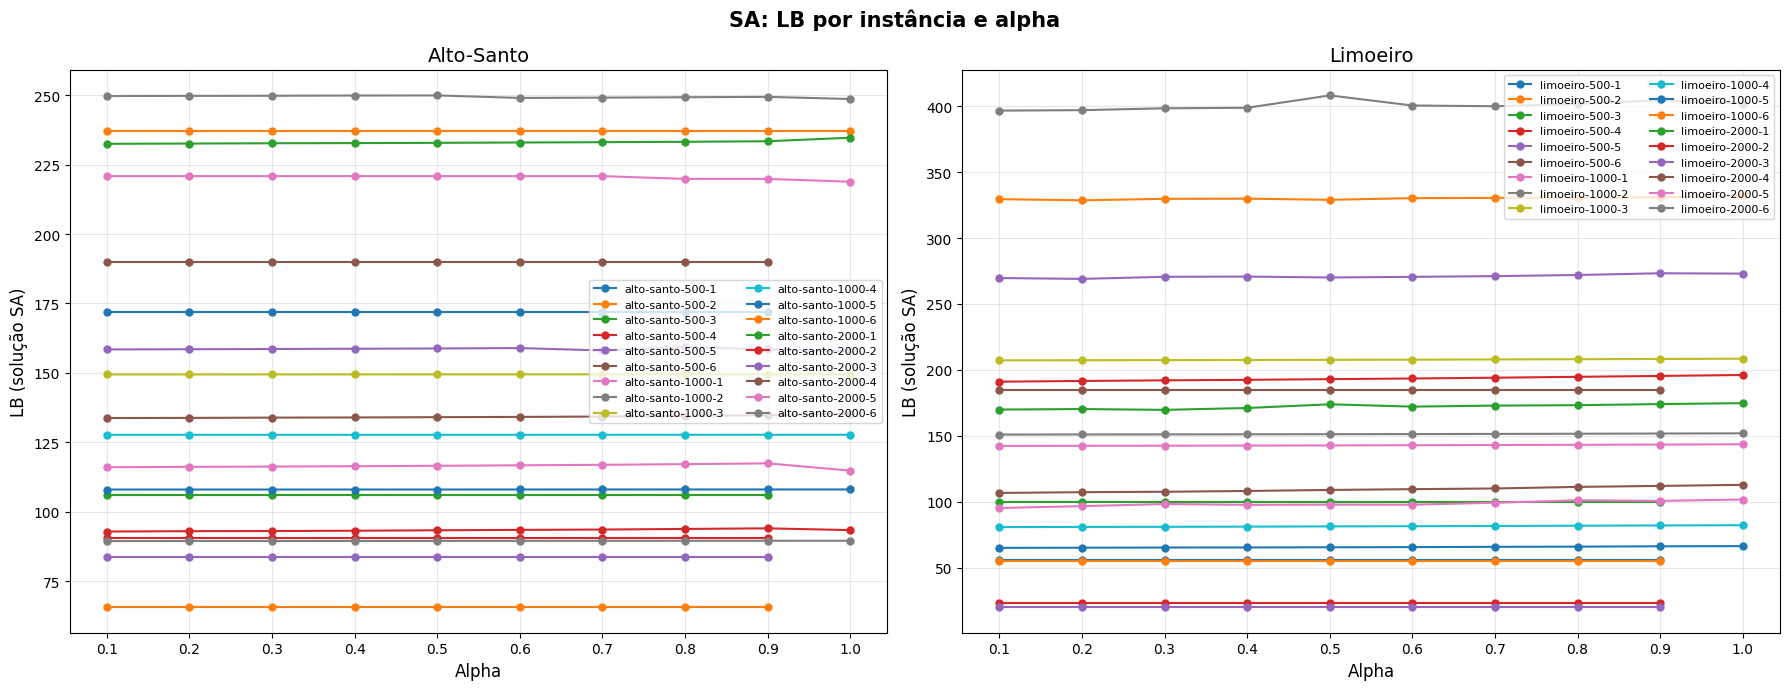

In [332]:
# Versão com LB (valor da solução SA) para comparar
fig, axes = plt.subplots(1, len(cities), figsize=(9 * len(cities), 7))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_all[df_all["city"] == city]
    instances_sorted = sorted(city_data["instance_name"].unique(), key=instance_sort_key)
    for inst in instances_sorted:
        grp = city_data[city_data["instance_name"] == inst].sort_values("alpha")
        ax.plot(grp["alpha"], grp["LB"], "o-", label=inst, markersize=5, linewidth=1.5)
    ax.set_xlabel("Alpha", fontsize=12)
    ax.set_ylabel("LB (solução SA)", fontsize=12)
    ax.set_title(f"{city.title()}", fontsize=14)
    ax.legend(fontsize=8, ncol=2, loc="best")
    ax.set_xticks(sorted(df_all["alpha"].unique()))

plt.suptitle("SA: LB por instância e alpha", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

## 10. Relatório detalhado — Maior instância do conjunto

Identificamos a maior instância (maior número de blocos B) e geramos um relatório completo de como o alpha afeta todos os indicadores.

In [333]:
# Identificar a maior instância (maior B)
inst_sizes = df_all.groupby("instance_name")["B"].first()
largest_inst = inst_sizes.idxmax()
largest_B = inst_sizes.max()
print(f"Maior instância: {largest_inst} (B = {largest_B})")

# Dados da maior instância para todos os alphas
df_largest = df_all[df_all["instance_name"] == largest_inst].sort_values("alpha").copy()

# Calcular métricas adicionais
df_largest["att_s0_pct"] = 100 * df_largest["attended_s0"] / df_largest["B"]
df_largest["avg_att_scenarios"] = df_largest["attended_per_scenario"].apply(
    lambda x: np.mean(x) if isinstance(x, list) and len(x) > 0 else 0
)
df_largest["improvement"] = df_largest["LB"] - df_largest["Start_LB"]
df_largest["improvement_pct"] = np.where(
    df_largest["Start_LB"] > 0,
    100 * df_largest["improvement"] / df_largest["Start_LB"],
    0,
)

# Tabela resumo
report_cols = [
    "alpha", "Start_LB", "LB", "improvement", "improvement_pct",
    "attended_s0", "att_s0_pct", "avg_att_scenarios",
    "route_time_s0", "attend_time_s0", "Runtime",
]
print(f"\n{'='*100}")
print(f"RELATÓRIO DETALHADO: {largest_inst} (N={df_largest.iloc[0]['N']}, M={df_largest.iloc[0]['M']}, B={largest_B}, S={df_largest.iloc[0]['S']})")
print(f"{'='*100}")
print(df_largest[report_cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))

Maior instância: limoeiro-2000-1 (B = 549)

RELATÓRIO DETALHADO: limoeiro-2000-1 (N=1008, M=3112, B=549, S=50)
 alpha  Start_LB     LB  improvement  improvement_pct  attended_s0  att_s0_pct  avg_att_scenarios  route_time_s0  attend_time_s0  Runtime
  0.10    168.87 169.89         1.03             0.61           30        5.46              28.67         449.00          749.00   122.12
  0.20    169.22 170.28         1.06             0.62           29        5.28              28.63         438.00          760.00   129.44
  0.30    169.62 169.66         0.04             0.02           29        5.28              28.63         457.00          743.00   113.38
  0.40    170.09 171.08         0.98             0.58           30        5.46              28.65         458.00          742.00   121.10
  0.50    170.61 173.89         3.28             1.92           30        5.46              28.86         407.00          790.00   143.95
  0.60    171.14 172.13         0.98             0.57        

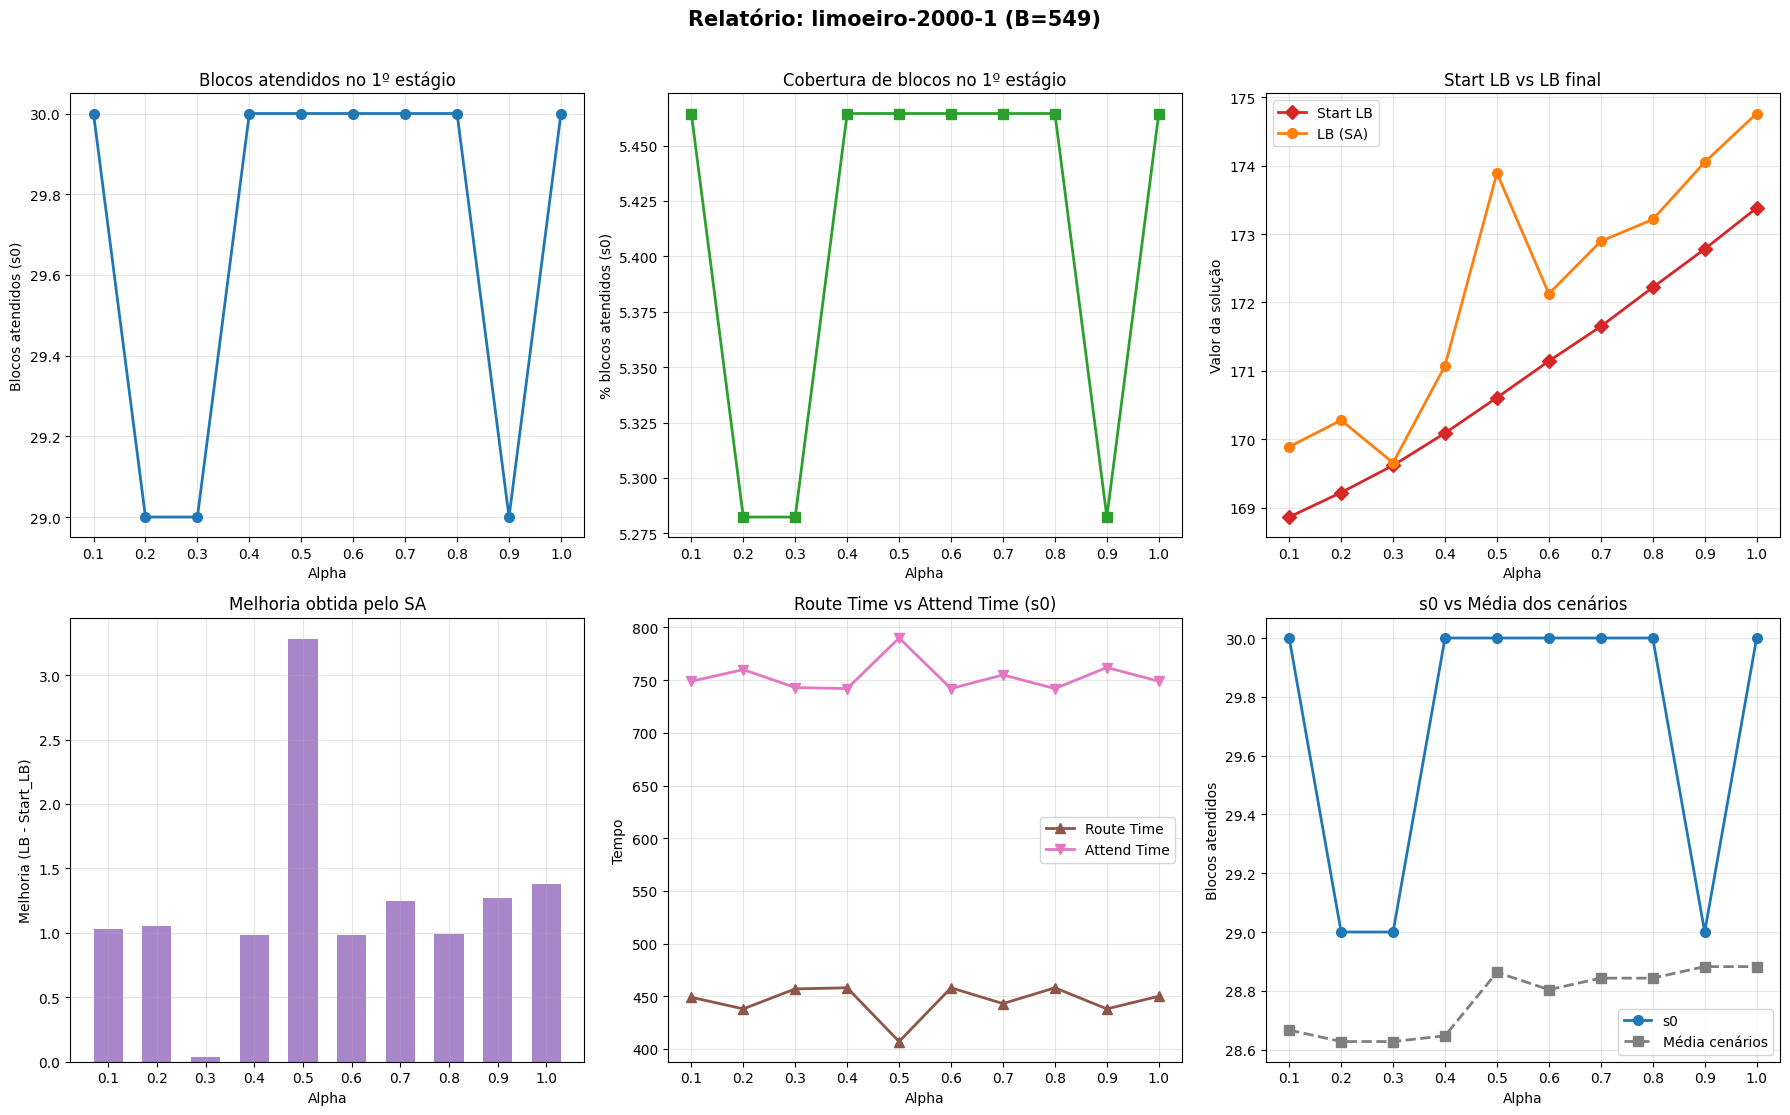

In [334]:
# Painel de gráficos detalhados para a maior instância
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

alphas = df_largest["alpha"].values

# 1. Blocos atendidos (s0) por alpha
ax = axes[0, 0]
ax.plot(alphas, df_largest["attended_s0"].values, "o-", color="C0", linewidth=2, markersize=7)
ax.set_xlabel("Alpha")
ax.set_ylabel("Blocos atendidos (s0)")
ax.set_title("Blocos atendidos no 1º estágio")
ax.set_xticks(alphas)

# 2. % de blocos atendidos (s0) por alpha
ax = axes[0, 1]
ax.plot(alphas, df_largest["att_s0_pct"].values, "s-", color="C2", linewidth=2, markersize=7)
ax.set_xlabel("Alpha")
ax.set_ylabel("% blocos atendidos (s0)")
ax.set_title("Cobertura de blocos no 1º estágio")
ax.set_xticks(alphas)

# 3. Start_LB vs LB (solução SA)
ax = axes[0, 2]
ax.plot(alphas, df_largest["Start_LB"].values, "D-", color="C3", linewidth=2, markersize=7, label="Start LB")
ax.plot(alphas, df_largest["LB"].values, "o-", color="C1", linewidth=2, markersize=7, label="LB (SA)")
ax.set_xlabel("Alpha")
ax.set_ylabel("Valor da solução")
ax.set_title("Start LB vs LB final")
ax.set_xticks(alphas)
ax.legend()

# 4. Melhoria (LB - Start_LB)
ax = axes[1, 0]
ax.bar(alphas, df_largest["improvement"].values, width=0.06, color="C4", alpha=0.8)
ax.set_xlabel("Alpha")
ax.set_ylabel("Melhoria (LB - Start_LB)")
ax.set_title("Melhoria obtida pelo SA")
ax.set_xticks(alphas)

# 5. Route_Time e Attend_Time (s0)
ax = axes[1, 1]
ax.plot(alphas, df_largest["route_time_s0"].values, "^-", color="C5", linewidth=2, markersize=7, label="Route Time")
ax.plot(alphas, df_largest["attend_time_s0"].values, "v-", color="C6", linewidth=2, markersize=7, label="Attend Time")
ax.set_xlabel("Alpha")
ax.set_ylabel("Tempo")
ax.set_title("Route Time vs Attend Time (s0)")
ax.set_xticks(alphas)
ax.legend()

# 6. Atendimento médio nos cenários vs s0
ax = axes[1, 2]
ax.plot(alphas, df_largest["attended_s0"].values, "o-", color="C0", linewidth=2, markersize=7, label="s0")
ax.plot(alphas, df_largest["avg_att_scenarios"].values, "s--", color="C7", linewidth=2, markersize=7, label="Média cenários")
ax.set_xlabel("Alpha")
ax.set_ylabel("Blocos atendidos")
ax.set_title("s0 vs Média dos cenários")
ax.set_xticks(alphas)
ax.legend()

plt.suptitle(f"Relatório: {largest_inst} (B={largest_B})", fontweight="bold", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

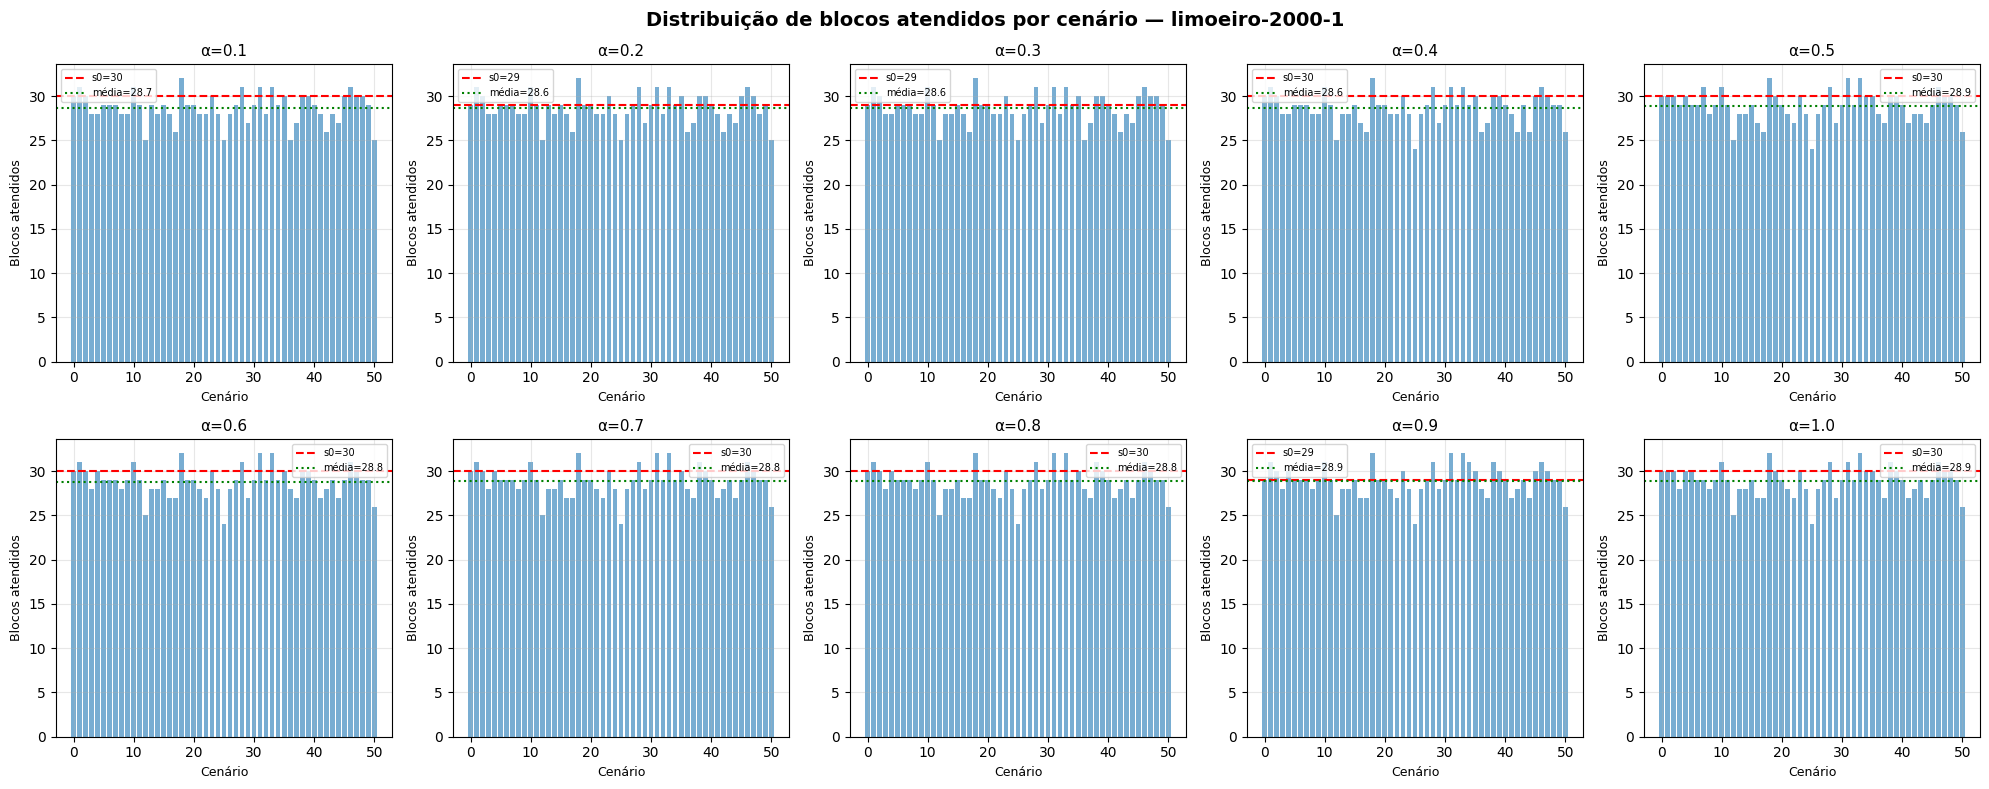

In [335]:
# Distribuição de blocos atendidos por cenário para cada alpha (maior instância)
# Mostra como o alpha afeta não só o s0 mas todos os cenários
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes_flat = axes.flatten()

for i, (_, row) in enumerate(df_largest.iterrows()):
    ax = axes_flat[i]
    att_list = row["attended_per_scenario"]
    if isinstance(att_list, list) and len(att_list) > 0:
        ax.bar(range(len(att_list)), att_list, color="C0", alpha=0.6)
        ax.axhline(y=att_list[0], color="red", linestyle="--", linewidth=1.5, label=f"s0={att_list[0]}")
        ax.axhline(y=np.mean(att_list), color="green", linestyle=":", linewidth=1.5, label=f"média={np.mean(att_list):.1f}")
    ax.set_title(f"α={row['alpha']:.1f}", fontsize=11)
    ax.set_xlabel("Cenário", fontsize=9)
    ax.set_ylabel("Blocos atendidos", fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle(f"Distribuição de blocos atendidos por cenário — {largest_inst}", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [336]:
# Resumo interpretativo para a maior instância
print(f"RESUMO — {largest_inst}")
print(f"{'='*80}")
print(f"Tamanho: N={df_largest.iloc[0]['N']}, M={df_largest.iloc[0]['M']}, B={largest_B}, S={df_largest.iloc[0]['S']}")
print()

# Tendências
att_min_alpha = df_largest.loc[df_largest["attended_s0"].idxmin(), "alpha"]
att_max_alpha = df_largest.loc[df_largest["attended_s0"].idxmax(), "alpha"]
att_min = df_largest["attended_s0"].min()
att_max = df_largest["attended_s0"].max()

lb_min_alpha = df_largest.loc[df_largest["LB"].idxmin(), "alpha"]
lb_max_alpha = df_largest.loc[df_largest["LB"].idxmax(), "alpha"]
lb_min = df_largest["LB"].min()
lb_max = df_largest["LB"].max()

imp_best_alpha = df_largest.loc[df_largest["improvement"].idxmax(), "alpha"]
imp_best = df_largest["improvement"].max()

print(f"Blocos atendidos (s0):")
print(f"  Mínimo: {att_min} (alpha={att_min_alpha})")
print(f"  Máximo: {att_max} (alpha={att_max_alpha})")
print(f"  Variação: {att_max - att_min} blocos ({100*(att_max-att_min)/largest_B:.1f}% de B)")
print()
print(f"LB (solução SA):")
print(f"  Melhor (menor): {lb_min:.2f} (alpha={lb_min_alpha})")
print(f"  Pior (maior):   {lb_max:.2f} (alpha={lb_max_alpha})")
print(f"  Variação:       {lb_max - lb_min:.2f}")
print()
print(f"Melhoria (LB - Start_LB):")
print(f"  Melhor melhoria: {imp_best:.2f} (alpha={imp_best_alpha})")
print(f"  Melhoria média:  {df_largest['improvement'].mean():.2f}")
print()

# Correlação alpha vs métricas
from scipy import stats
for col, label in [("attended_s0", "Blocos atendidos s0"), ("LB", "LB"), ("improvement", "Melhoria")]:
    r, p = stats.pearsonr(df_largest["alpha"], df_largest[col])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"Correlação alpha × {label}: r={r:.3f}, p={p:.4f} ({sig})")

RESUMO — limoeiro-2000-1
Tamanho: N=1008, M=3112, B=549, S=50

Blocos atendidos (s0):
  Mínimo: 29 (alpha=0.2)
  Máximo: 30 (alpha=0.1)
  Variação: 1 blocos (0.2% de B)

LB (solução SA):
  Melhor (menor): 169.66 (alpha=0.3)
  Pior (maior):   174.76 (alpha=1.0)
  Variação:       5.10

Melhoria (LB - Start_LB):
  Melhor melhoria: 3.28 (alpha=0.5)
  Melhoria média:  1.23

Correlação alpha × Blocos atendidos s0: r=0.190, p=0.5992 (ns)
Correlação alpha × LB: r=0.905, p=0.0003 (***)
Correlação alpha × Melhoria: r=0.180, p=0.6195 (ns)


## 11. Relatório: Impacto do Alpha na Função Objetivo

### Como o alpha funciona no modelo estocástico

O problema é de **maximização**: a FO representa o total de casos atendidos (profit).

A função objetivo tem **dois estágios**:

**1º Estágio (cenário 0)** — rota definida *antes* de conhecer os cenários:
- Para cada bloco `b` atendido no s0:
  - Lucro = `cases_det[b] + α × Σ(prob[s] × cases_s[b])`
  - O bloco recebe os casos determinísticos **mais** `α` vezes o valor esperado dos cenários

**2º Estágio (cenários 1..S)** — rotas ajustadas *após* revelar cada cenário:
- Bloco `b` **não atendido** no s0: lucro = `cases_s[b]` (valor integral)
- Bloco `b` **já atendido** no s0: lucro = `(1 - α) × cases_s[b]` (valor reduzido)

### O trade-off do alpha

| Alpha | 1º Estágio | 2º Estágio (blocos já em s0) | Efeito |
|-------|-----------|------------------------------|--------|
| α → 0 | Apenas casos determinísticos | Valor integral dos cenários | Decisão s0 ignora cenários |
| α = 0.5 | Metade do bônus de cenários | Metade do valor no 2º estágio | Equilíbrio |
| α → 1 | Bônus máximo de cenários | Valor zero no 2º estágio | s0 captura tudo, 2º estágio perde valor |

### Consequência direta

- **Alpha alto** → mais incentivo para atender blocos no s0 (coeficientes maiores) → Start_LB cresce monotonicamente
- **Mas** o 2º estágio perde valor para blocos já em s0 → atendimento médio nos cenários **cai drasticamente** quando α=1
- O **LB total** não segue um padrão monotônico porque é o resultado de um **equilíbrio** entre os dois efeitos

In [337]:
# Instâncias selecionadas para análise detalhada
# Critério: variedade de cidades e tamanhos (pequena, média, grande)
SELECTED = [
    "alto-santo-1000-1",   # média, comportamento estável até alpha=0.8
    "alto-santo-1000-3",   # média, queda abrupta de avg_ss em alpha=1
    "alto-santo-2000-1",   # grande (alto-santo)
    "limoeiro-1000-3",     # média (limoeiro)
    "limoeiro-2000-1",     # grande, LB cresce com alpha
    "limoeiro-2000-6",     # grande, alta variabilidade, pico em alpha=0.5
]

alphas_all = sorted(df_all["alpha"].unique())

# Construir tabela completa para instâncias selecionadas
rows = []
for _, row in df_all[df_all["instance_name"].isin(SELECTED)].iterrows():
    aps = row["attended_per_scenario"]
    s0 = aps[0] if isinstance(aps, list) and len(aps) > 0 else 0
    ss_list = aps[1:] if isinstance(aps, list) and len(aps) > 1 else []
    avg_ss = np.mean(ss_list) if ss_list else 0
    min_ss = min(ss_list) if ss_list else 0
    max_ss = max(ss_list) if ss_list else 0
    rows.append({
        "instance": row["instance_name"],
        "alpha": row["alpha"],
        "B": row["B"],
        "Start_LB": row["Start_LB"],
        "LB": row["LB"],
        "improvement": row["improvement"],
        "att_s0": s0,
        "avg_att_ss": avg_ss,
        "min_att_ss": min_ss,
        "max_att_ss": max_ss,
        "route_time": row["route_time_s0"],
        "attend_time": row["attend_time_s0"],
    })

df_report = pd.DataFrame(rows)
df_report = df_report.sort_values(["instance", "alpha"]).reset_index(drop=True)

print(f"Instâncias selecionadas: {len(SELECTED)}")
print(f"Registros: {len(df_report)}")
df_report.head(10)

Instâncias selecionadas: 6
Registros: 60


,instance,alpha,B,Start_LB,LB,improvement,att_s0,avg_att_ss,min_att_ss,max_att_ss,route_time,attend_time
0,alto-santo-1000-1,0.1,84,219.88,220.88,1.0,39,28.02,18,41,136.0,1053.0
1,alto-santo-1000-1,0.2,84,219.88,220.88,1.0,39,28.02,18,41,136.0,1053.0
2,alto-santo-1000-1,0.3,84,219.88,220.88,1.0,39,28.02,18,41,136.0,1053.0
3,alto-santo-1000-1,0.4,84,219.88,220.88,1.0,39,28.02,18,41,135.0,1061.0
4,alto-santo-1000-1,0.5,84,219.88,220.88,1.0,39,28.02,18,41,136.0,1053.0
5,alto-santo-1000-1,0.6,84,219.88,220.88,1.0,39,28.02,18,41,136.0,1053.0
6,alto-santo-1000-1,0.7,84,219.88,220.88,1.0,39,28.02,18,41,136.0,1061.0
7,alto-santo-1000-1,0.8,84,219.88,219.88,0.0,38,28.02,18,41,167.0,1033.0
8,alto-santo-1000-1,0.9,84,217.88,219.88,2.0,38,28.02,18,41,160.0,1037.0
9,alto-santo-1000-1,1.0,84,217.88,218.88,1.0,38,10.64,4,16,160.0,1036.0


### 11.1. Start_LB é monotonicamente crescente com alpha?

O Start_LB (valor do LB antes da melhoria do SA) deve crescer com alpha porque os coeficientes de primeiro estágio aumentam: `cases_det[b] + α × E[cases_s[b]]`.

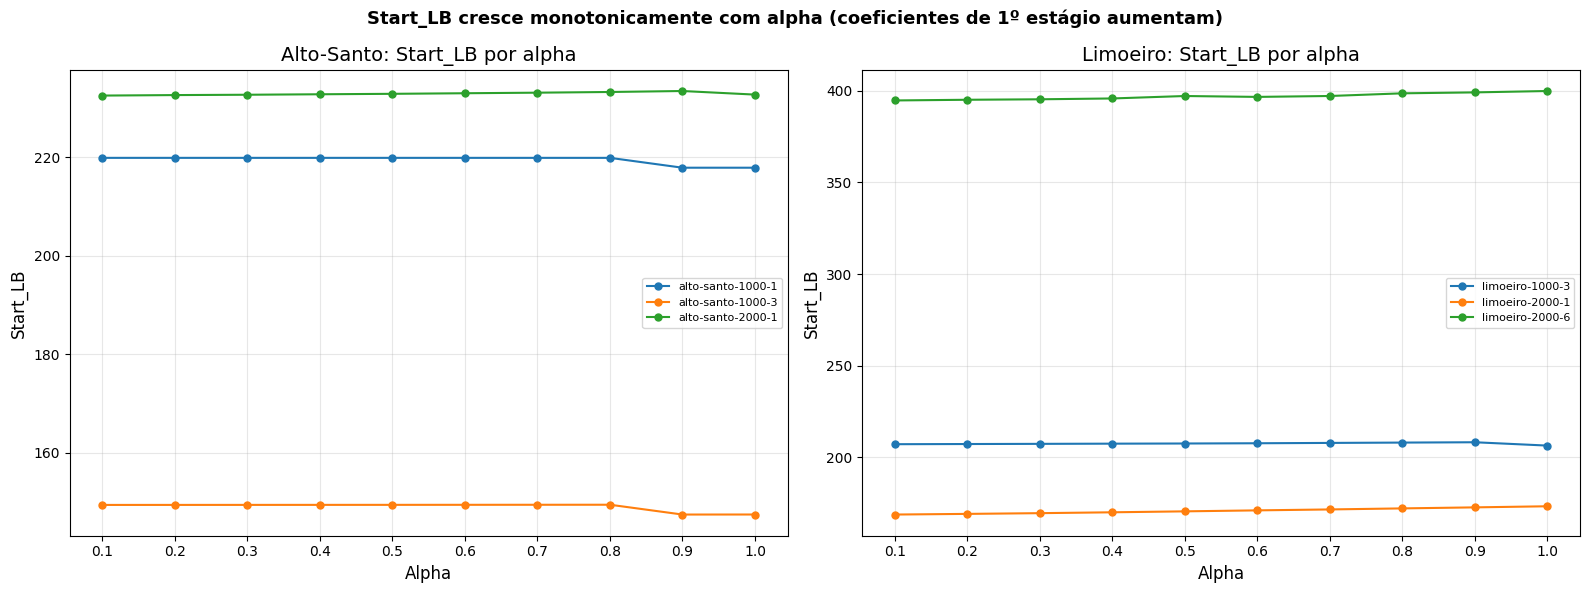


Verificação: Start_LB é monotonicamente crescente?
Instância                  Monotônico?  Start_LB(0.1)  Start_LB(1.0)          Δ
alto-santo-1000-1                NÃO ✗        219.880        217.880     -2.000
alto-santo-1000-3                NÃO ✗        149.424        147.480     -1.944
alto-santo-2000-1                NÃO ✗        232.524        232.720      0.196
limoeiro-1000-3                  NÃO ✗        207.236        206.480     -0.756
limoeiro-2000-1                  SIM ✓        168.866        173.380      4.514
limoeiro-2000-6                  NÃO ✗        394.752        399.900      5.148


In [338]:
# Verificar monotonia do Start_LB para todas as instâncias
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, sorted(df_all["city"].unique())):
    city_df = df_report[df_report["instance"].apply(lambda x: "-".join(x.split("-")[:-2])) == city]
    for inst in sorted(city_df["instance"].unique(), key=instance_sort_key):
        grp = city_df[city_df["instance"] == inst].sort_values("alpha")
        ax.plot(grp["alpha"], grp["Start_LB"], "o-", label=inst, markersize=5, linewidth=1.5)
    ax.set_xlabel("Alpha", fontsize=12)
    ax.set_ylabel("Start_LB", fontsize=12)
    ax.set_title(f"{city.title()}: Start_LB por alpha", fontsize=14)
    ax.legend(fontsize=8)
    ax.set_xticks(alphas_all)

plt.suptitle("Start_LB cresce monotonicamente com alpha (coeficientes de 1º estágio aumentam)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# Verificar se Start_LB é estritamente crescente para cada instância
print("\nVerificação: Start_LB é monotonicamente crescente?")
print(f"{'Instância':<25} {'Monotônico?':>12} {'Start_LB(0.1)':>14} {'Start_LB(1.0)':>14} {'Δ':>10}")
for inst in sorted(df_report["instance"].unique(), key=instance_sort_key):
    grp = df_report[df_report["instance"] == inst].sort_values("alpha")
    vals = grp["Start_LB"].values
    is_mono = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    delta = vals[-1] - vals[0]
    print(f"{inst:<25} {'SIM ✓' if is_mono else 'NÃO ✗':>12} {vals[0]:>14.3f} {vals[-1]:>14.3f} {delta:>10.3f}")

### 11.2. E o LB final (após SA)? Segue o mesmo padrão?

Se o SA melhora o Start_LB para cima, o LB final deveria acompanhar a tendência. Mas a heurística introduz variabilidade.

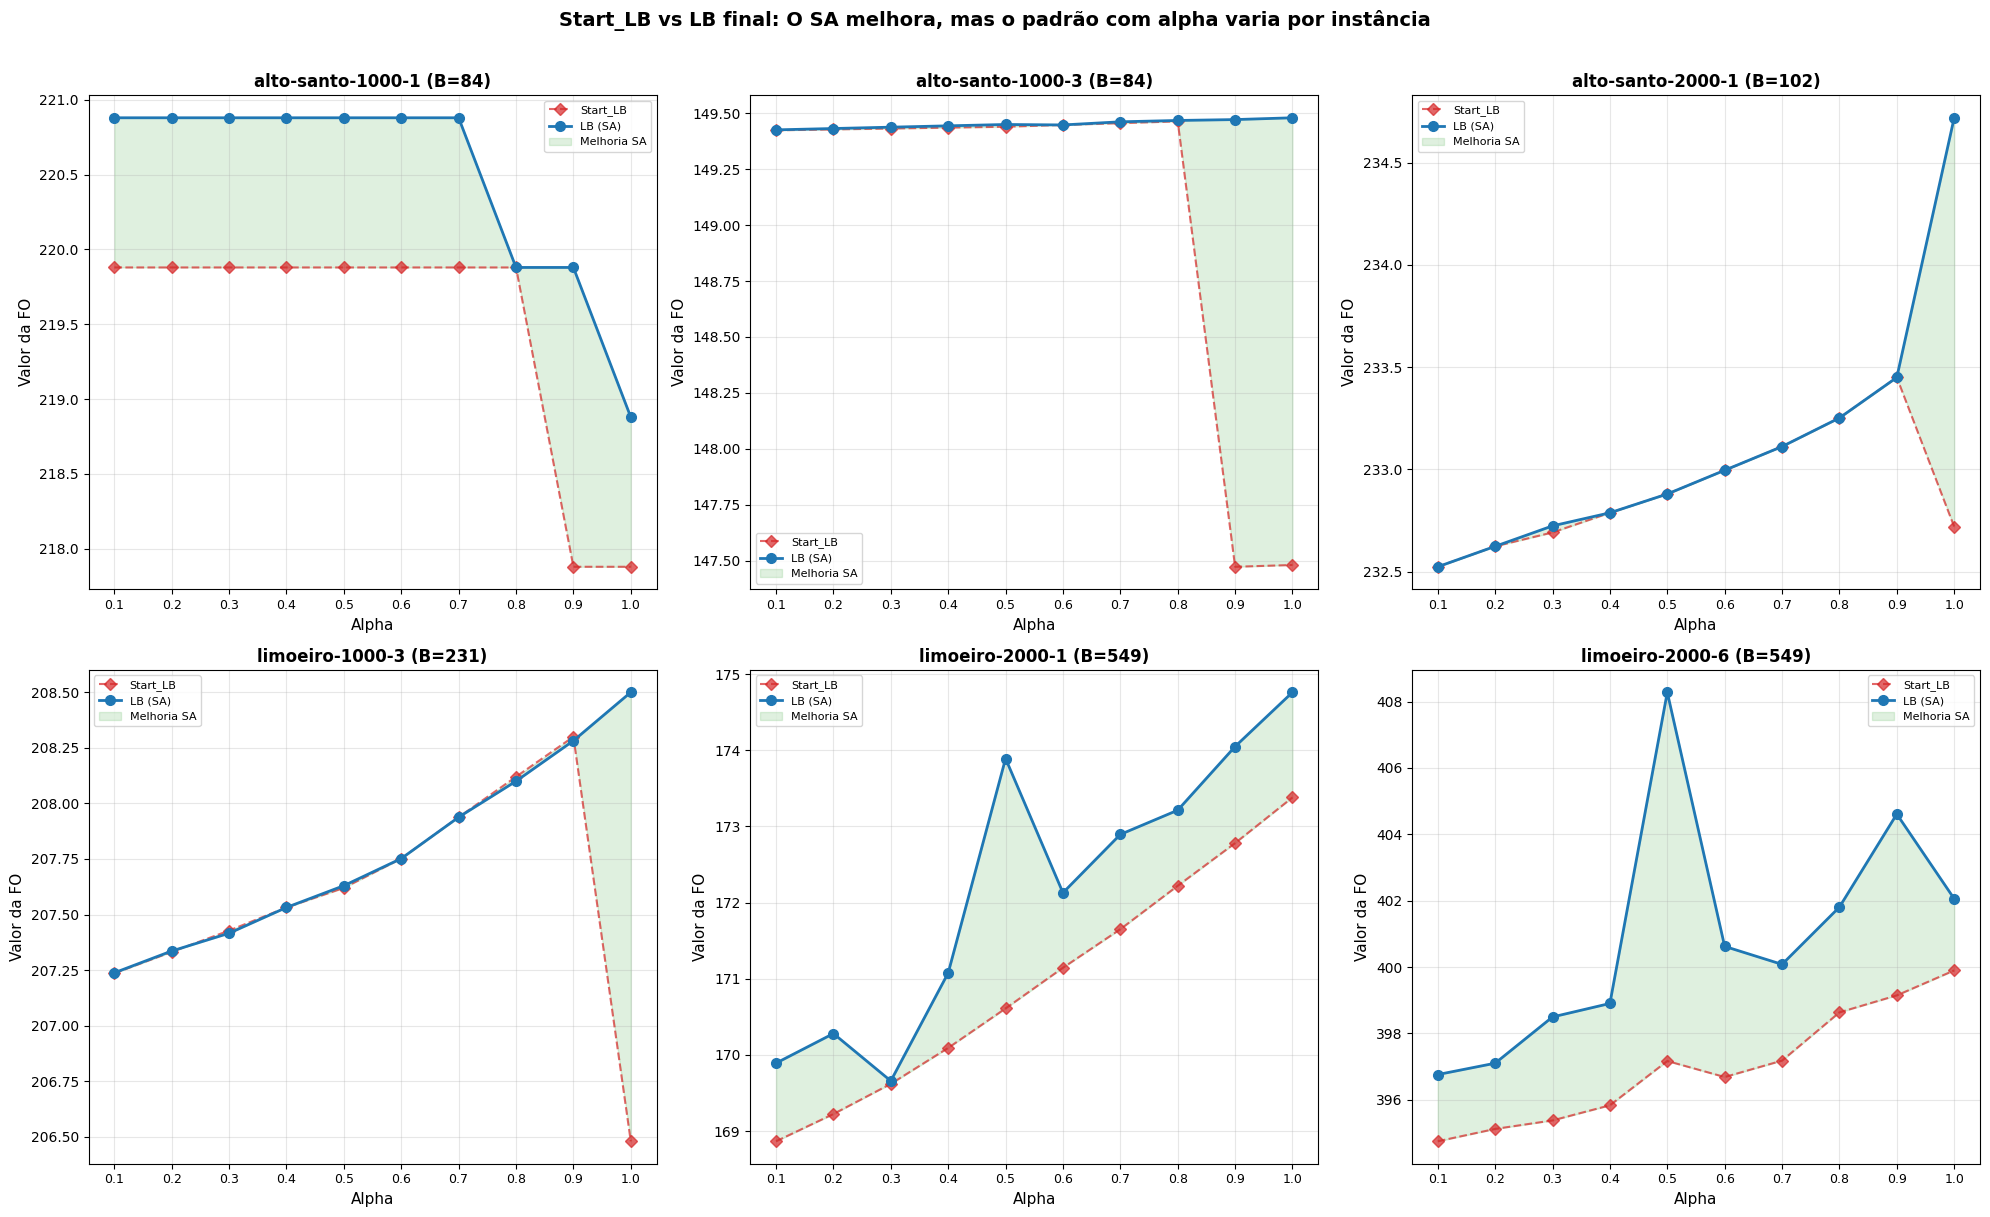


Verificação: LB é monotonicamente crescente?
Instância                  Mono?    LB(0.1)    LB(0.5)    LB(1.0)     LB max α do max
alto-santo-1000-1            NÃO    220.880    220.880    218.880    220.880      0.1
alto-santo-1000-3            NÃO    149.426    149.450    149.480    149.480      1.0
alto-santo-2000-1            SIM    232.524    232.880    234.720    234.720      1.0
limoeiro-1000-3              SIM    207.238    207.630    208.500    208.500      1.0
limoeiro-2000-1              NÃO    169.892    173.890    174.760    174.760      1.0
limoeiro-2000-6              NÃO    396.762    408.280    402.060    408.280      0.5


In [339]:
# Comparar Start_LB vs LB vs tendência
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, inst in enumerate(SELECTED):
    ax = axes_flat[idx]
    grp = df_report[df_report["instance"] == inst].sort_values("alpha")
    
    ax.plot(grp["alpha"], grp["Start_LB"], "D--", color="C3", markersize=6, linewidth=1.5, label="Start_LB", alpha=0.7)
    ax.plot(grp["alpha"], grp["LB"], "o-", color="C0", markersize=7, linewidth=2, label="LB (SA)")
    ax.fill_between(grp["alpha"], grp["Start_LB"], grp["LB"], alpha=0.15, color="C2", label="Melhoria SA")
    
    ax.set_xlabel("Alpha", fontsize=11)
    ax.set_ylabel("Valor da FO", fontsize=11)
    ax.set_title(f"{inst} (B={grp.iloc[0]['B']})", fontsize=12, fontweight="bold")
    ax.set_xticks(alphas_all)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle("Start_LB vs LB final: O SA melhora, mas o padrão com alpha varia por instância",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Verificar se LB é monotonicamente crescente
print("\nVerificação: LB é monotonicamente crescente?")
print(f"{'Instância':<25} {'Mono?':>6} {'LB(0.1)':>10} {'LB(0.5)':>10} {'LB(1.0)':>10} {'LB max':>10} {'α do max':>8}")
for inst in sorted(df_report["instance"].unique(), key=instance_sort_key):
    grp = df_report[df_report["instance"] == inst].sort_values("alpha")
    vals = grp["LB"].values
    is_mono = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    best_idx = grp["LB"].idxmax()
    best_alpha = grp.loc[best_idx, "alpha"]
    print(f"{inst:<25} {'SIM' if is_mono else 'NÃO':>6} {vals[0]:>10.3f} {vals[4]:>10.3f} {vals[-1]:>10.3f} {vals.max():>10.3f} {best_alpha:>8.1f}")

### 11.3. Atendimento no 1º estágio vs 2º estágio — O efeito mais revelador do alpha

Este é o gráfico mais importante: mostra que o **atendimento médio no 2º estágio cai drasticamente em α=1**, enquanto o 1º estágio permanece relativamente estável.

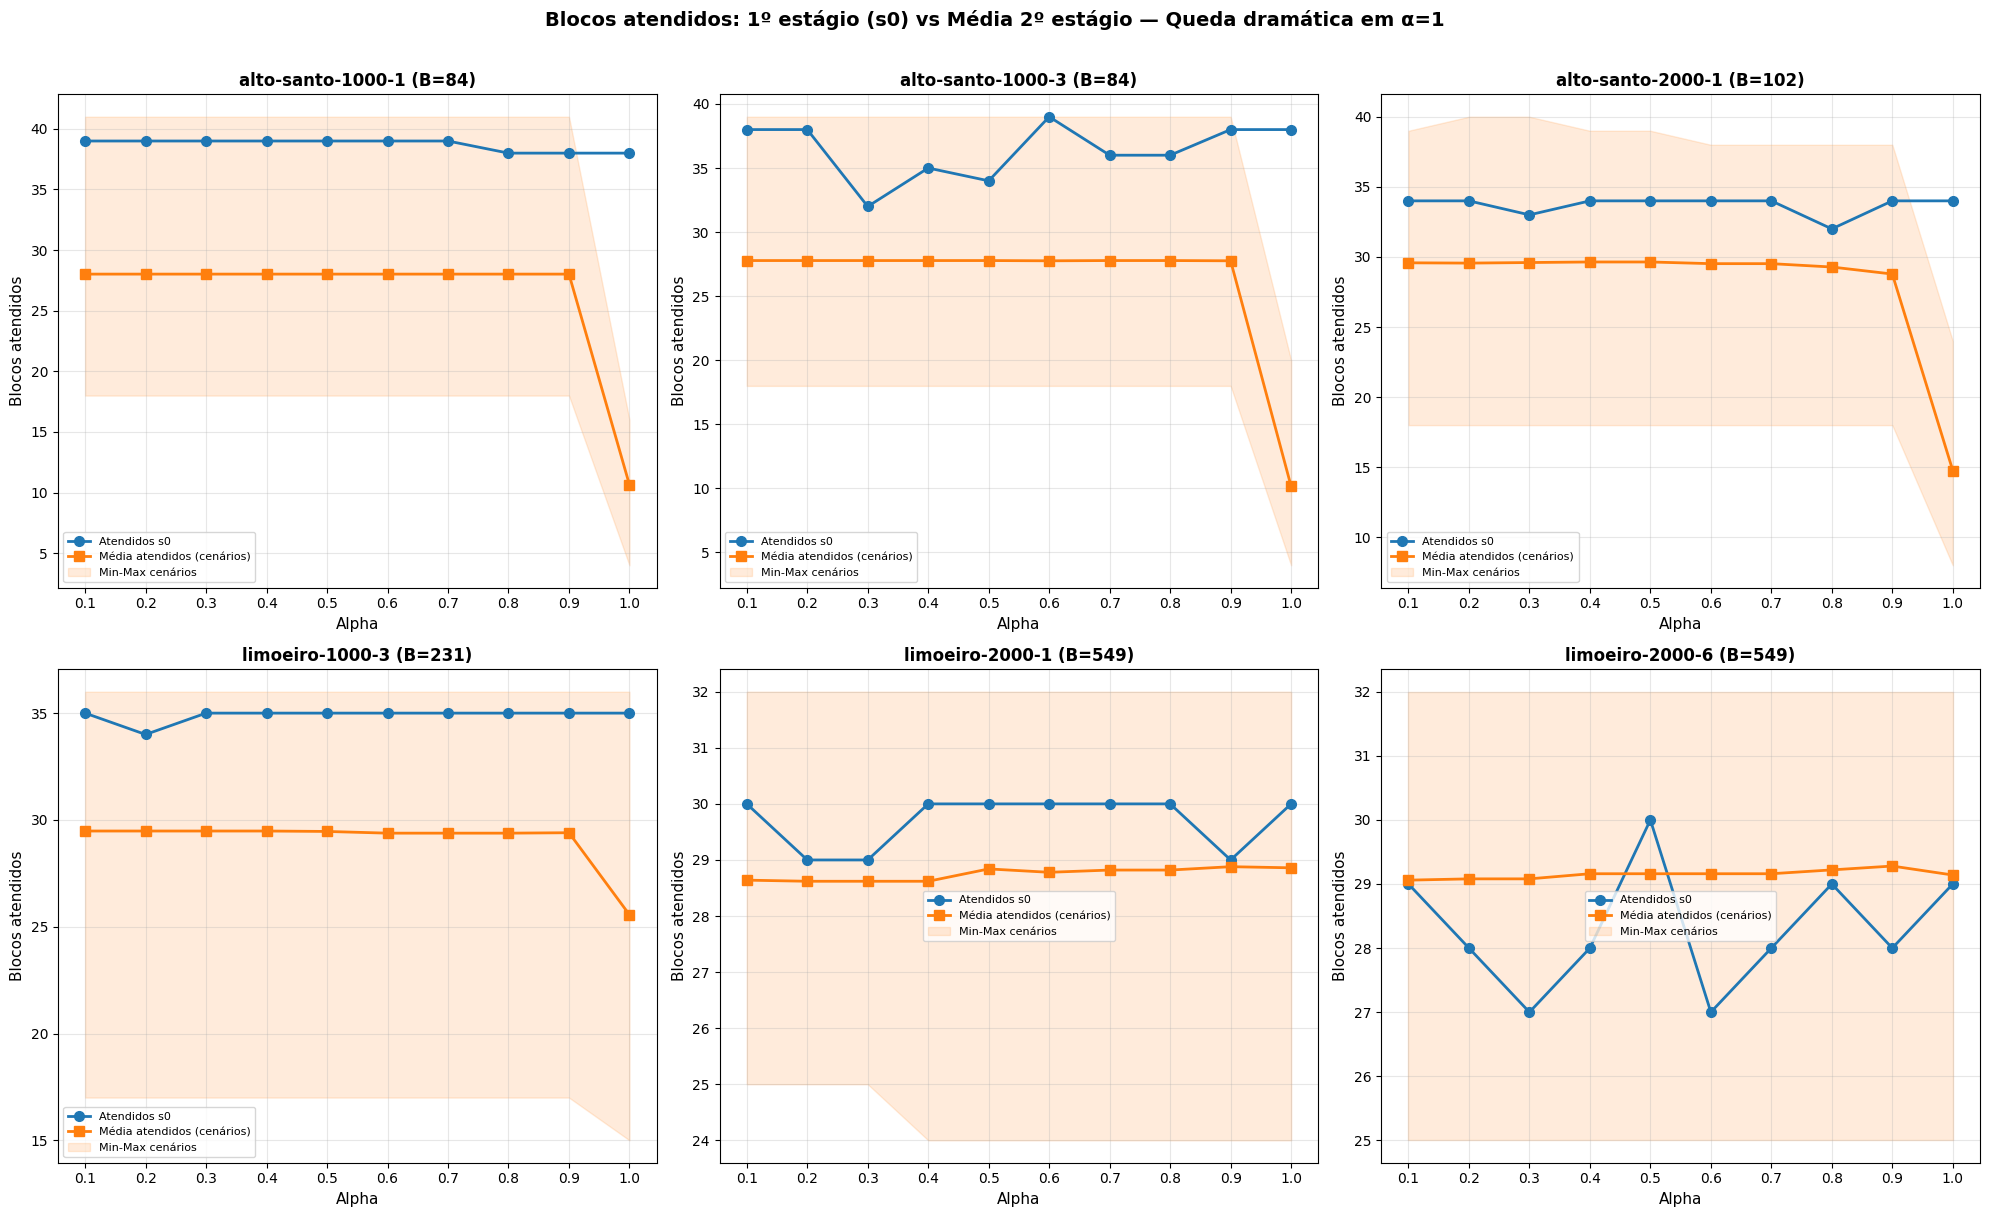


Impacto no atendimento médio do 2º estágio:
Instância                  avg_ss(0.1)  avg_ss(0.9)  avg_ss(1.0)   Queda 0.9→1.0    Queda %
alto-santo-1000-1                28.02        28.02        10.64           17.38      62.0%
alto-santo-1000-3                27.78        27.76        10.16           17.60      63.4%
alto-santo-2000-1                29.58        28.78        14.76           14.02      48.7%
limoeiro-1000-3                  29.48        29.40        25.56            3.84      13.1%
limoeiro-2000-1                  28.64        28.88        28.86            0.02       0.1%
limoeiro-2000-6                  29.06        29.28        29.14            0.14       0.5%


In [340]:
# Gráfico duplo: atendimento s0 e avg_ss por alpha, para cada instância selecionada
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, inst in enumerate(SELECTED):
    ax = axes_flat[idx]
    grp = df_report[df_report["instance"] == inst].sort_values("alpha")
    
    ax.plot(grp["alpha"], grp["att_s0"], "o-", color="C0", markersize=7, linewidth=2, label="Atendidos s0")
    ax.plot(grp["alpha"], grp["avg_att_ss"], "s-", color="C1", markersize=7, linewidth=2, label="Média atendidos (cenários)")
    ax.fill_between(grp["alpha"], grp["min_att_ss"], grp["max_att_ss"],
                     alpha=0.15, color="C1", label="Min-Max cenários")
    
    ax.set_xlabel("Alpha", fontsize=11)
    ax.set_ylabel("Blocos atendidos", fontsize=11)
    ax.set_title(f"{inst} (B={grp.iloc[0]['B']})", fontsize=12, fontweight="bold")
    ax.set_xticks(alphas_all)
    ax.legend(fontsize=8)

plt.suptitle("Blocos atendidos: 1º estágio (s0) vs Média 2º estágio — Queda dramática em α=1",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Quantificar a queda
print("\nImpacto no atendimento médio do 2º estágio:")
print(f"{'Instância':<25} {'avg_ss(0.1)':>12} {'avg_ss(0.9)':>12} {'avg_ss(1.0)':>12} {'Queda 0.9→1.0':>15} {'Queda %':>10}")
for inst in sorted(df_report["instance"].unique(), key=instance_sort_key):
    grp = df_report[df_report["instance"] == inst].sort_values("alpha")
    v01 = grp[grp["alpha"]==0.1]["avg_att_ss"].values[0]
    v09 = grp[grp["alpha"]==0.9]["avg_att_ss"].values[0]
    v10 = grp[grp["alpha"]==1.0]["avg_att_ss"].values[0]
    drop = v09 - v10
    pct = 100*drop/v09 if v09 > 0 else 0
    print(f"{inst:<25} {v01:>12.2f} {v09:>12.2f} {v10:>12.2f} {drop:>15.2f} {pct:>9.1f}%")

### 11.4. Decomposição da FO: Quanto vem do 1º estágio vs 2º estágio?

Para entender por que o LB não é monotônico, precisamos decompor a FO. A fórmula é:

- **Contribuição s0** (para cada bloco b em s0): `cases_det[b] + α × Σ prob[s] × cases_s[b]`
- **Contribuição cenários** (para cada bloco b em cenário s):
  - Se b **não** está em s0: `prob[s] × cases_s[b]`
  - Se b **está** em s0: `prob[s] × (1-α) × cases_s[b]`

Quando α aumenta, a contribuição do s0 cresce mas a do 2º estágio para blocos já visitados cai. O resultado líquido depende da instância.

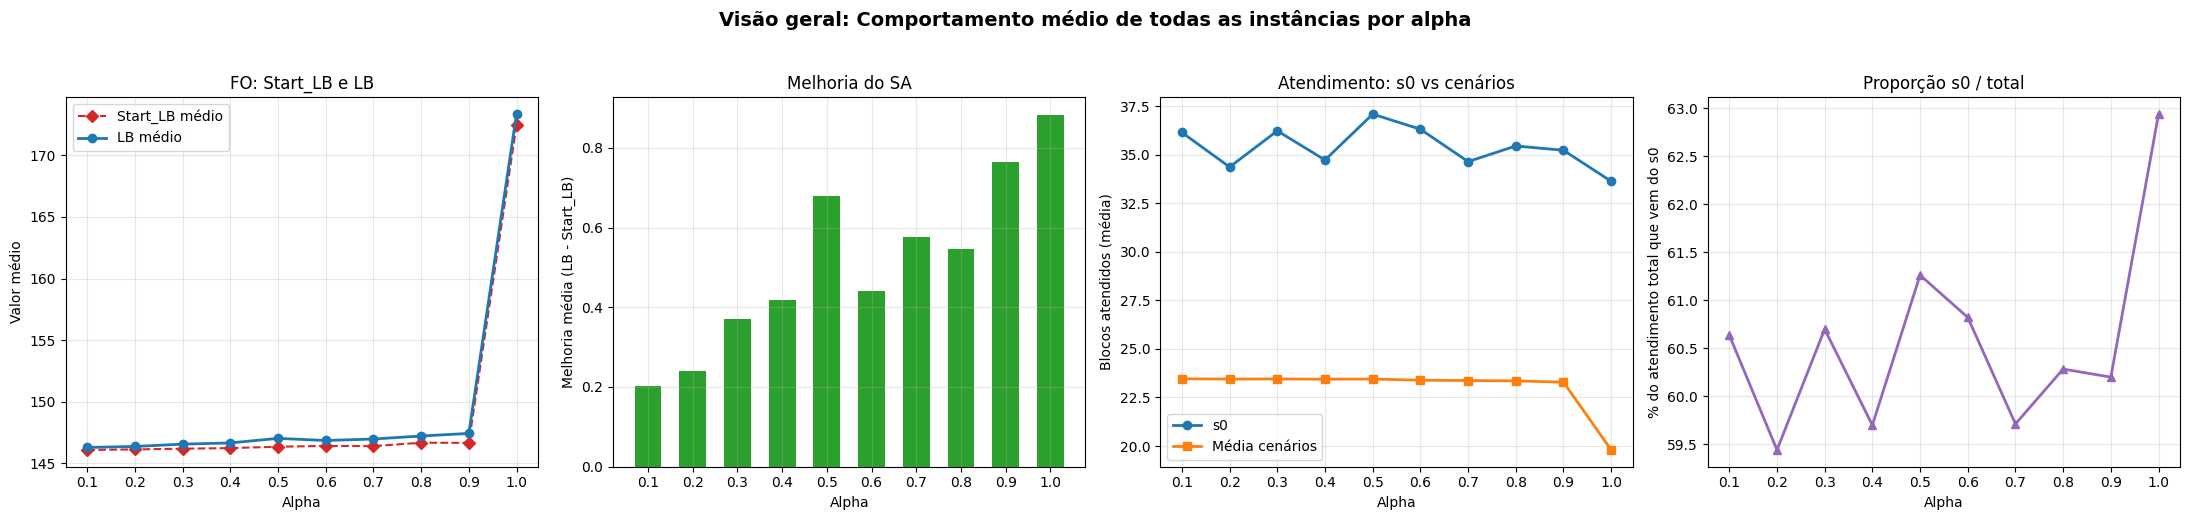

In [341]:
# Análise completa para TODAS as instâncias (não apenas selecionadas)
# Construir df_full_report para todas instâncias com avg_ss
rows_full = []
for _, row in df_all.iterrows():
    aps = row["attended_per_scenario"]
    ss_list = aps[1:] if isinstance(aps, list) and len(aps) > 1 else []
    rows_full.append({
        "instance": row["instance_name"],
        "alpha": row["alpha"],
        "city": row["city"],
        "map_size": row["map_size"],
        "B": row["B"],
        "Start_LB": row["Start_LB"],
        "LB": row["LB"],
        "improvement": row["improvement"],
        "att_s0": aps[0] if isinstance(aps, list) and len(aps) > 0 else 0,
        "avg_att_ss": np.mean(ss_list) if ss_list else 0,
    })
df_full = pd.DataFrame(rows_full)

# Tendências gerais — médias por alpha
agg_alpha = df_full.groupby("alpha").agg(
    LB_medio=("LB", "mean"),
    Start_LB_medio=("Start_LB", "mean"),
    improvement_medio=("improvement", "mean"),
    att_s0_medio=("att_s0", "mean"),
    avg_att_ss_medio=("avg_att_ss", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

ax = axes[0]
ax.plot(agg_alpha["alpha"], agg_alpha["Start_LB_medio"], "D--", color="C3", label="Start_LB médio")
ax.plot(agg_alpha["alpha"], agg_alpha["LB_medio"], "o-", color="C0", linewidth=2, label="LB médio")
ax.set_xlabel("Alpha"); ax.set_ylabel("Valor médio"); ax.set_title("FO: Start_LB e LB")
ax.legend(); ax.set_xticks(alphas_all)

ax = axes[1]
ax.bar(agg_alpha["alpha"], agg_alpha["improvement_medio"], width=0.06, color="C2")
ax.set_xlabel("Alpha"); ax.set_ylabel("Melhoria média (LB - Start_LB)")
ax.set_title("Melhoria do SA"); ax.set_xticks(alphas_all)

ax = axes[2]
ax.plot(agg_alpha["alpha"], agg_alpha["att_s0_medio"], "o-", color="C0", linewidth=2, label="s0")
ax.plot(agg_alpha["alpha"], agg_alpha["avg_att_ss_medio"], "s-", color="C1", linewidth=2, label="Média cenários")
ax.set_xlabel("Alpha"); ax.set_ylabel("Blocos atendidos (média)")
ax.set_title("Atendimento: s0 vs cenários"); ax.legend(); ax.set_xticks(alphas_all)

ax = axes[3]
ratio = agg_alpha["att_s0_medio"] / (agg_alpha["att_s0_medio"] + agg_alpha["avg_att_ss_medio"]) * 100
ax.plot(agg_alpha["alpha"], ratio, "^-", color="C4", linewidth=2)
ax.set_xlabel("Alpha"); ax.set_ylabel("% do atendimento total que vem do s0")
ax.set_title("Proporção s0 / total"); ax.set_xticks(alphas_all)

plt.suptitle("Visão geral: Comportamento médio de todas as instâncias por alpha",
             fontweight="bold", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 11.5. Caso de estudo 1: `alto-santo-1000-3` — Colapso do 2º estágio em α=1

Esta instância ilustra perfeitamente o mecanismo do alpha. De α=0.1 a α=0.9, o atendimento médio nos cenários é estável (~28 blocos). Em α=1.0, cai para ~10 blocos porque `(1-α)=0` anula o valor dos blocos do s0 nos cenários.

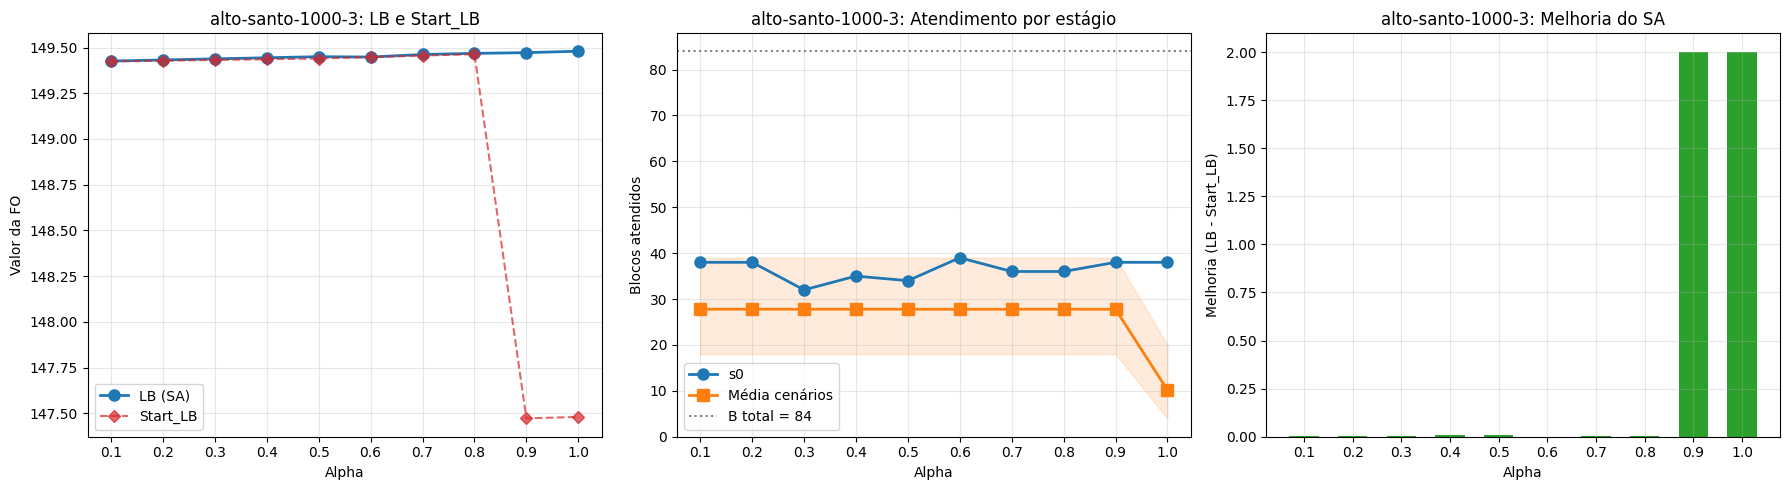


--- alto-santo-1000-3 (B=84) ---
    α   Start_LB         LB        Δ    s0   avg_ss  min_ss  max_ss
  0.1    149.424    149.426    0.002    38    27.78      18      39
  0.2    149.428    149.432    0.004    38    27.78      18      39
  0.3    149.432    149.438    0.006    32    27.78      18      39
  0.4    149.436    149.444    0.008    35    27.78      18      39
  0.5    149.440    149.450    0.010    34    27.78      18      39
  0.6    149.448    149.448    0.000    39    27.76      18      39
  0.7    149.456    149.462    0.006    36    27.78      18      39
  0.8    149.464    149.468    0.004    36    27.78      18      39
  0.9    147.472    149.472    2.000    38    27.76      18      39
  1.0    147.480    149.480    2.000    38    10.16       4      20

→ Observação: De α=0.1 a α=0.9, avg_ss ≈ 27.8
→ Em α=1.0, avg_ss cai para 10.2 (queda de 63%)
→ Motivo: quando α=1, (1-α)=0, logo revisitar blocos do s0 no 2º estágio vale ZERO casos.


In [342]:
# Caso 1: alto-santo-1000-3
inst_case1 = "alto-santo-1000-3"
case1 = df_report[df_report["instance"] == inst_case1].sort_values("alpha")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(case1["alpha"], case1["LB"], "o-", color="C0", linewidth=2, markersize=8)
ax.plot(case1["alpha"], case1["Start_LB"], "D--", color="C3", linewidth=1.5, markersize=6, alpha=0.7)
ax.set_xlabel("Alpha"); ax.set_ylabel("Valor da FO")
ax.set_title(f"{inst_case1}: LB e Start_LB")
ax.legend(["LB (SA)", "Start_LB"]); ax.set_xticks(alphas_all)

ax = axes[1]
ax.plot(case1["alpha"], case1["att_s0"], "o-", color="C0", linewidth=2, markersize=8, label="s0")
ax.plot(case1["alpha"], case1["avg_att_ss"], "s-", color="C1", linewidth=2, markersize=8, label="Média cenários")
ax.fill_between(case1["alpha"], case1["min_att_ss"], case1["max_att_ss"], alpha=0.15, color="C1")
ax.axhline(y=case1.iloc[0]["B"], color="gray", linestyle=":", label=f"B total = {case1.iloc[0]['B']}")
ax.set_xlabel("Alpha"); ax.set_ylabel("Blocos atendidos")
ax.set_title(f"{inst_case1}: Atendimento por estágio")
ax.legend(); ax.set_xticks(alphas_all)

ax = axes[2]
ax.bar(case1["alpha"], case1["improvement"], width=0.06, color="C2")
ax.set_xlabel("Alpha"); ax.set_ylabel("Melhoria (LB - Start_LB)")
ax.set_title(f"{inst_case1}: Melhoria do SA")
ax.set_xticks(alphas_all)

plt.tight_layout()
plt.show()

print(f"\n--- {inst_case1} (B={case1.iloc[0]['B']}) ---")
print(f"{'α':>5} {'Start_LB':>10} {'LB':>10} {'Δ':>8} {'s0':>5} {'avg_ss':>8} {'min_ss':>7} {'max_ss':>7}")
for _, r in case1.iterrows():
    print(f"{r['alpha']:>5.1f} {r['Start_LB']:>10.3f} {r['LB']:>10.3f} {r['improvement']:>8.3f} {int(r['att_s0']):>5} {r['avg_att_ss']:>8.2f} {int(r['min_att_ss']):>7} {int(r['max_att_ss']):>7}")

print(f"\n→ Observação: De α=0.1 a α=0.9, avg_ss ≈ {case1[case1['alpha']<=0.9]['avg_att_ss'].mean():.1f}")
print(f"→ Em α=1.0, avg_ss cai para {case1[case1['alpha']==1.0]['avg_att_ss'].values[0]:.1f} (queda de {100*(1 - case1[case1['alpha']==1.0]['avg_att_ss'].values[0] / case1[case1['alpha']<=0.9]['avg_att_ss'].mean()):.0f}%)")
print(f"→ Motivo: quando α=1, (1-α)=0, logo revisitar blocos do s0 no 2º estágio vale ZERO casos.")

### 11.6. Caso de estudo 2: `limoeiro-2000-1` — Tendência crescente com picos

Esta instância é grande (B=549, N=1008) e mostra um comportamento onde o LB tende a crescer com alpha, com oscilações causadas pela natureza heurística do SA.

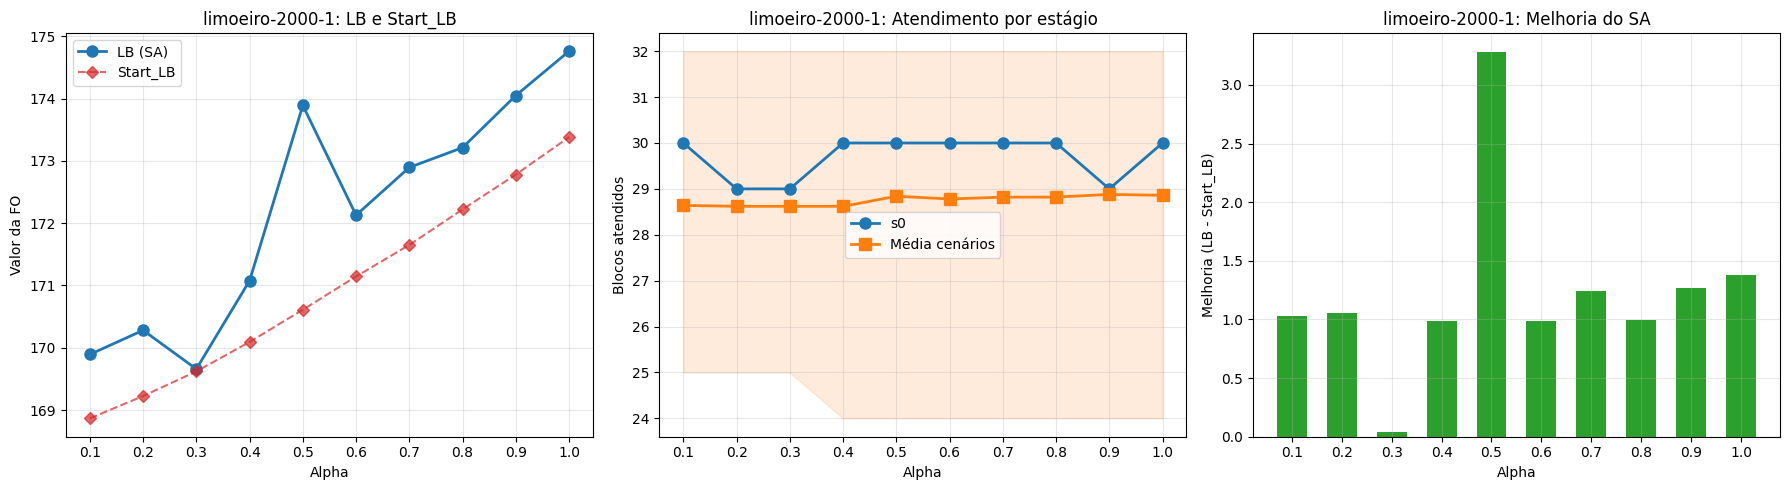


--- limoeiro-2000-1 (B=549) ---
    α   Start_LB         LB        Δ    s0   avg_ss    Δ_ss
  0.1    168.866    169.892    1.026    30    28.64       -
  0.2    169.224    170.280    1.056    29    28.62   -0.02
  0.3    169.620    169.658    0.038    29    28.62   +0.00
  0.4    170.092    171.076    0.984    30    28.62   +0.00
  0.5    170.610    173.890    3.280    30    28.84   +0.22
  0.6    171.144    172.128    0.984    30    28.78   -0.06
  0.7    171.650    172.894    1.244    30    28.82   +0.04
  0.8    172.220    173.212    0.992    30    28.82   +0.00
  0.9    172.780    174.048    1.268    29    28.88   +0.06
  1.0    173.380    174.760    1.380    30    28.86   -0.02

→ LB cresce ~4.9 de α=0.1 a α=1.0
→ Atendimento s0 se mantém estável (~30 blocos de 549)
→ Avg_ss cai levemente mas NÃO colapsa (instância grande tem mais blocos exclusivos do 2º estágio)


In [343]:
# Caso 2: limoeiro-2000-1
inst_case2 = "limoeiro-2000-1"
case2 = df_report[df_report["instance"] == inst_case2].sort_values("alpha")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(case2["alpha"], case2["LB"], "o-", color="C0", linewidth=2, markersize=8)
ax.plot(case2["alpha"], case2["Start_LB"], "D--", color="C3", linewidth=1.5, markersize=6, alpha=0.7)
ax.set_xlabel("Alpha"); ax.set_ylabel("Valor da FO")
ax.set_title(f"{inst_case2}: LB e Start_LB")
ax.legend(["LB (SA)", "Start_LB"]); ax.set_xticks(alphas_all)

ax = axes[1]
ax.plot(case2["alpha"], case2["att_s0"], "o-", color="C0", linewidth=2, markersize=8, label="s0")
ax.plot(case2["alpha"], case2["avg_att_ss"], "s-", color="C1", linewidth=2, markersize=8, label="Média cenários")
ax.fill_between(case2["alpha"], case2["min_att_ss"], case2["max_att_ss"], alpha=0.15, color="C1")
ax.set_xlabel("Alpha"); ax.set_ylabel("Blocos atendidos")
ax.set_title(f"{inst_case2}: Atendimento por estágio")
ax.legend(); ax.set_xticks(alphas_all)

ax = axes[2]
ax.bar(case2["alpha"], case2["improvement"], width=0.06, color="C2")
ax.set_xlabel("Alpha"); ax.set_ylabel("Melhoria (LB - Start_LB)")
ax.set_title(f"{inst_case2}: Melhoria do SA")
ax.set_xticks(alphas_all)

plt.tight_layout()
plt.show()

print(f"\n--- {inst_case2} (B={case2.iloc[0]['B']}) ---")
print(f"{'α':>5} {'Start_LB':>10} {'LB':>10} {'Δ':>8} {'s0':>5} {'avg_ss':>8} {'Δ_ss':>7}")
prev_ss = None
for _, r in case2.iterrows():
    d_ss = f"{r['avg_att_ss'] - prev_ss:>+7.2f}" if prev_ss is not None else "      -"
    prev_ss = r["avg_att_ss"]
    print(f"{r['alpha']:>5.1f} {r['Start_LB']:>10.3f} {r['LB']:>10.3f} {r['improvement']:>8.3f} {int(r['att_s0']):>5} {r['avg_att_ss']:>8.2f} {d_ss}")

print(f"\n→ LB cresce ~{case2['LB'].iloc[-1] - case2['LB'].iloc[0]:.1f} de α=0.1 a α=1.0")
print(f"→ Atendimento s0 se mantém estável (~{case2['att_s0'].mean():.0f} blocos de {case2.iloc[0]['B']})")
print(f"→ Avg_ss cai levemente mas NÃO colapsa (instância grande tem mais blocos exclusivos do 2º estágio)")

### 11.7. Caso de estudo 3: `limoeiro-2000-6` — Alta variabilidade e pico anômalo

Esta instância tem a maior variação de LB e um pico visível em α=0.5. Isso acontece porque o SA encontrou uma solução excepcionalmente boa nesse ponto.

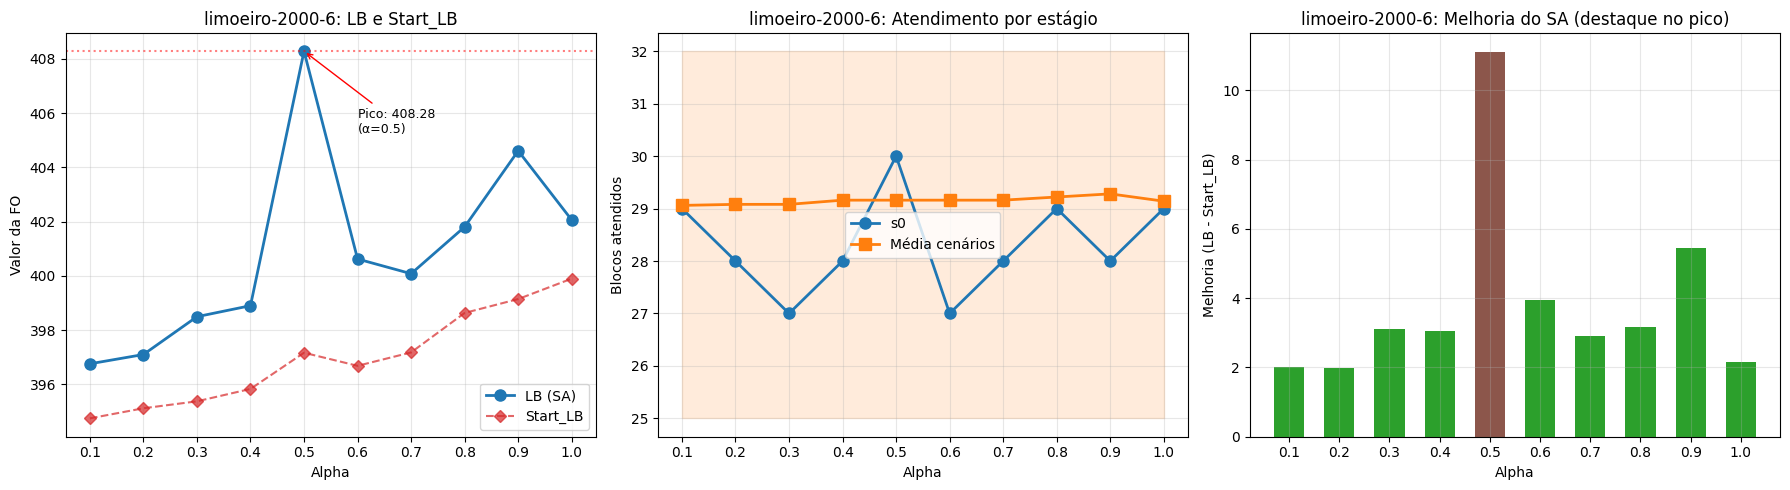


--- limoeiro-2000-6 (B=549) ---
    α   Start_LB         LB     Δ SA    s0   avg_ss
  0.1    394.752    396.762    2.010    29    29.06
  0.2    395.124    397.104    1.980    28    29.08
  0.3    395.380    398.498    3.118    27    29.08
  0.4    395.836    398.904    3.068    28    29.16
  0.5    397.170    408.280   11.110    30    29.16 ◀ PICO
  0.6    396.688    400.624    3.936    27    29.16
  0.7    397.182    400.082    2.900    28    29.16
  0.8    398.636    401.808    3.172    29    29.22
  0.9    399.148    404.610    5.462    28    29.28
  1.0    399.900    402.060    2.160    29    29.14

→ O SA encontrou melhoria de 11.11 em α=0.5 (pico anômalo)
→ Isso NÃO significa que α=0.5 é universalmente melhor
→ O SA é estocástico: a mesma instância com os mesmos parâmetros pode dar resultados diferentes


In [344]:
# Caso 3: limoeiro-2000-6
inst_case3 = "limoeiro-2000-6"
case3 = df_report[df_report["instance"] == inst_case3].sort_values("alpha")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(case3["alpha"], case3["LB"], "o-", color="C0", linewidth=2, markersize=8)
ax.plot(case3["alpha"], case3["Start_LB"], "D--", color="C3", linewidth=1.5, markersize=6, alpha=0.7)
ax.axhline(y=case3["LB"].max(), color="red", linestyle=":", alpha=0.5)
ax.annotate(f"Pico: {case3['LB'].max():.2f}\n(α={case3.loc[case3['LB'].idxmax(), 'alpha']})",
            xy=(case3.loc[case3['LB'].idxmax(), 'alpha'], case3['LB'].max()),
            xytext=(0.6, case3['LB'].max() - 3), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="red"))
ax.set_xlabel("Alpha"); ax.set_ylabel("Valor da FO")
ax.set_title(f"{inst_case3}: LB e Start_LB")
ax.legend(["LB (SA)", "Start_LB"]); ax.set_xticks(alphas_all)

ax = axes[1]
ax.plot(case3["alpha"], case3["att_s0"], "o-", color="C0", linewidth=2, markersize=8, label="s0")
ax.plot(case3["alpha"], case3["avg_att_ss"], "s-", color="C1", linewidth=2, markersize=8, label="Média cenários")
ax.fill_between(case3["alpha"], case3["min_att_ss"], case3["max_att_ss"], alpha=0.15, color="C1")
ax.set_xlabel("Alpha"); ax.set_ylabel("Blocos atendidos")
ax.set_title(f"{inst_case3}: Atendimento por estágio")
ax.legend(); ax.set_xticks(alphas_all)

ax = axes[2]
colors = ["C5" if v == case3["improvement"].max() else "C2" for v in case3["improvement"]]
ax.bar(case3["alpha"], case3["improvement"], width=0.06, color=colors)
ax.set_xlabel("Alpha"); ax.set_ylabel("Melhoria (LB - Start_LB)")
ax.set_title(f"{inst_case3}: Melhoria do SA (destaque no pico)")
ax.set_xticks(alphas_all)

plt.tight_layout()
plt.show()

print(f"\n--- {inst_case3} (B={case3.iloc[0]['B']}) ---")
print(f"{'α':>5} {'Start_LB':>10} {'LB':>10} {'Δ SA':>8} {'s0':>5} {'avg_ss':>8}")
for _, r in case3.iterrows():
    marker = " ◀ PICO" if r['LB'] == case3['LB'].max() else ""
    print(f"{r['alpha']:>5.1f} {r['Start_LB']:>10.3f} {r['LB']:>10.3f} {r['improvement']:>8.3f} {int(r['att_s0']):>5} {r['avg_att_ss']:>8.2f}{marker}")

print(f"\n→ O SA encontrou melhoria de {case3['improvement'].max():.2f} em α=0.5 (pico anômalo)")
print(f"→ Isso NÃO significa que α=0.5 é universalmente melhor")
print(f"→ O SA é estocástico: a mesma instância com os mesmos parâmetros pode dar resultados diferentes")

### 11.8. Síntese: Por que as variações com alpha não são monotônicas?

Vamos consolidar todas as evidências em uma análise final.

In [345]:
# Verificação para TODAS as instâncias: Start_LB é monotônico? LB é monotônico?
all_insts = sorted(df_full["instance"].unique(), key=instance_sort_key)
start_lb_mono = 0
lb_mono = 0
total = len(all_insts)

for inst in all_insts:
    grp = df_full[df_full["instance"] == inst].sort_values("alpha")
    vals_start = grp["Start_LB"].values
    vals_lb = grp["LB"].values
    if all(vals_start[i] <= vals_start[i+1] for i in range(len(vals_start)-1)):
        start_lb_mono += 1
    if all(vals_lb[i] <= vals_lb[i+1] for i in range(len(vals_lb)-1)):
        lb_mono += 1

print("=" * 80)
print("SÍNTESE — IMPACTO DO ALPHA NA FUNÇÃO OBJETIVO")
print("=" * 80)

print(f"\n1. START_LB (antes do SA):")
print(f"   Monotonicamente crescente em {start_lb_mono}/{total} instâncias ({100*start_lb_mono/total:.0f}%)")
print(f"   → ESPERADO: os coeficientes do 1º estágio incluem α×E[cases_s[b]],")
print(f"     logo mais alpha = coeficientes maiores = Start_LB maior")
print(f"   → Exceções surgem apenas quando α=1 altera a estrutura da solução greedy inicial")

print(f"\n2. LB (após SA):")
print(f"   Monotonicamente crescente em {lb_mono}/{total} instâncias ({100*lb_mono/total:.0f}%)")
print(f"   → NÃO É MONOTÔNICO porque:")
print(f"     a) O SA é estocástico (vizinhança, aceitação aleatória)")
print(f"     b) Diferentes alphas geram landscapes diferentes para o SA explorar")
print(f"     c) O equilíbrio entre ganho no s0 e perda no 2º estágio varia por instância")

# Atendimento s0 e cenários
att_s0_changes = []
avg_ss_drops_at_1 = []
for inst in all_insts:
    grp = df_full[df_full["instance"] == inst].sort_values("alpha")
    att_range = grp["att_s0"].max() - grp["att_s0"].min()
    att_s0_changes.append(att_range)
    avg_09 = grp[grp["alpha"]==0.9]["avg_att_ss"].values[0] if 0.9 in grp["alpha"].values else grp["avg_att_ss"].iloc[-2]
    avg_10 = grp[grp["alpha"]==1.0]["avg_att_ss"].values[0] if 1.0 in grp["alpha"].values else grp["avg_att_ss"].iloc[-1]
    if avg_09 > 0:
        avg_ss_drops_at_1.append(100*(avg_09 - avg_10)/avg_09)

print(f"\n3. ATENDIMENTO NO 1º ESTÁGIO (s0):")
print(f"   Variação média de blocos s0 entre α_min e α_max: {np.mean(att_s0_changes):.1f} blocos")
print(f"   → Relativamente estável: o número de blocos no s0 não muda muito com alpha")
print(f"   → O que muda é QUAIS blocos são escolhidos (blocos com mais casos nos cenários")
print(f"     ganham prioridade com alpha alto)")

print(f"\n4. ATENDIMENTO MÉDIO NO 2º ESTÁGIO:")
print(f"   Queda média de α=0.9 para α=1.0: {np.mean(avg_ss_drops_at_1):.1f}%")
print(f"   → EFEITO DRAMÁTICO em α=1: (1-α)=0 anula o valor de revisitar blocos do s0")
print(f"   → Nos cenários, o modelo só atende blocos que NÃO estão no s0")
print(f"   → Em instâncias pequenas (poucos blocos), a queda é mais severa")

print(f"\n5. POR QUE NÃO É MONOTÔNICO?")
print(f"   O LB é o resultado líquido de dois efeitos opostos:")
print(f"   (+) Alpha maior → coeficientes s0 maiores → solução inicial vale mais")
print(f"   (-) Alpha maior → (1-α) menor → 2º estágio perde valor para blocos em s0")
print(f"   O ponto ótimo de alpha depende da razão entre:")
print(f"   • Casos determinísticos vs estocásticos em cada bloco")
print(f"   • Proporção de blocos atendidos no s0 vs total")
print(f"   • Variabilidade entre cenários")
print(f"   → Instâncias grandes (mais blocos exclusivos do 2º estágio) toleram alpha alto")
print(f"   → Instâncias pequenas (muita sobreposição s0/cenários) sofrem mais com alpha alto")

SÍNTESE — IMPACTO DO ALPHA NA FUNÇÃO OBJETIVO

1. START_LB (antes do SA):
   Monotonicamente crescente em 21/36 instâncias (58%)
   → ESPERADO: os coeficientes do 1º estágio incluem α×E[cases_s[b]],
     logo mais alpha = coeficientes maiores = Start_LB maior
   → Exceções surgem apenas quando α=1 altera a estrutura da solução greedy inicial

2. LB (após SA):
   Monotonicamente crescente em 24/36 instâncias (67%)
   → NÃO É MONOTÔNICO porque:
     a) O SA é estocástico (vizinhança, aceitação aleatória)
     b) Diferentes alphas geram landscapes diferentes para o SA explorar
     c) O equilíbrio entre ganho no s0 e perda no 2º estágio varia por instância

3. ATENDIMENTO NO 1º ESTÁGIO (s0):
   Variação média de blocos s0 entre α_min e α_max: 7.0 blocos
   → Relativamente estável: o número de blocos no s0 não muda muito com alpha
   → O que muda é QUAIS blocos são escolhidos (blocos com mais casos nos cenários
     ganham prioridade com alpha alto)

4. ATENDIMENTO MÉDIO NO 2º ESTÁGIO:
   

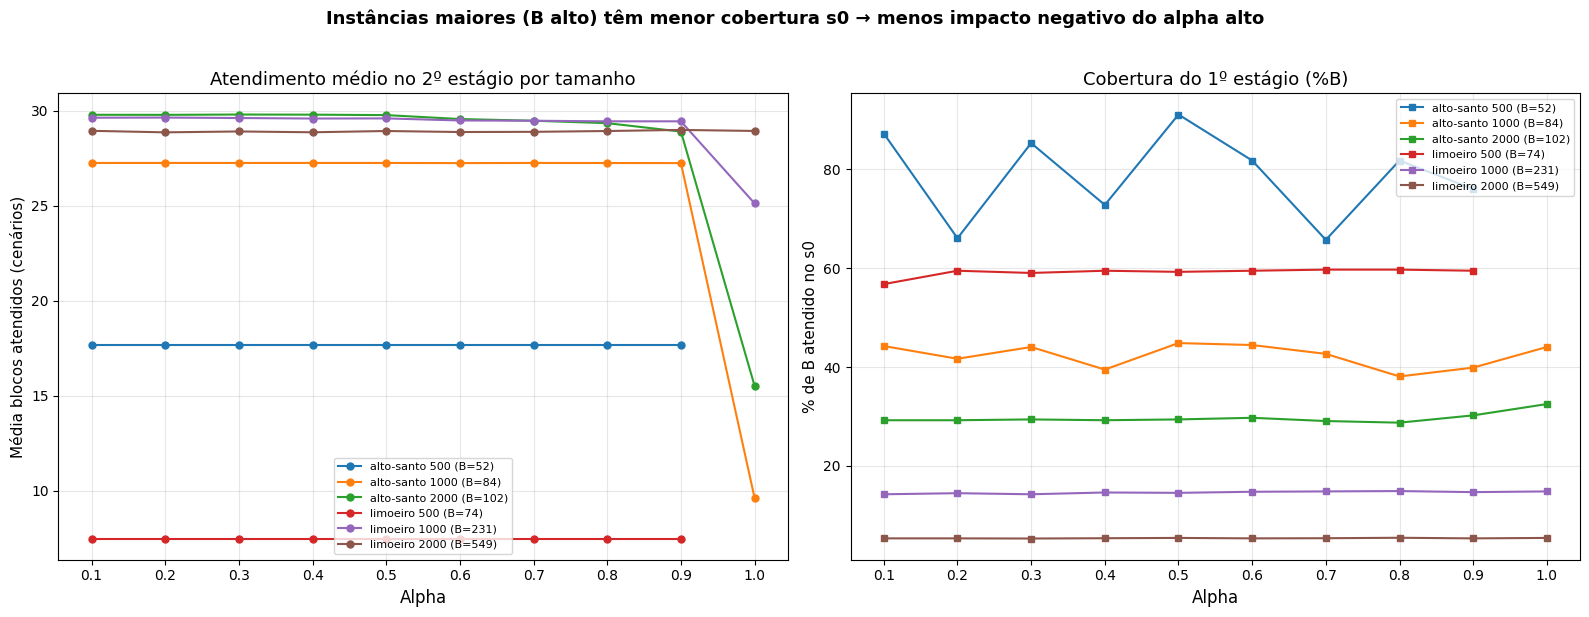


Cobertura média do s0 (% de B atendido no primeiro estágio):
  alto-santo 500 (B=52): α=0.1 → 87.2%, α=0.9 → 76.0%
  alto-santo 1000 (B=84): α=0.1 → 44.2%, α=1.0 → 44.0%
  alto-santo 2000 (B=102): α=0.1 → 29.2%, α=1.0 → 32.5%
  limoeiro 500 (B=74): α=0.1 → 56.8%, α=0.9 → 59.5%
  limoeiro 1000 (B=231): α=0.1 → 14.3%, α=1.0 → 14.9%
  limoeiro 2000 (B=549): α=0.1 → 5.4%, α=1.0 → 5.5%

→ Instâncias com B grande (limoeiro-2000) atendem ~5% no s0
→ Instâncias com B pequeno (alto-santo-1000) atendem ~45% no s0
→ Quando 45% dos blocos já estão no s0 e α=1, o 2º estágio perde valor para quase METADE dos blocos
→ Quando apenas 5% estão no s0, o impacto é mínimo — por isso as instâncias grandes são mais estáveis


In [346]:
# Gráfico final: sobreposição s0 / cenários por tamanho de instância
# Quanto do atendimento do s0 se repete nos cenários?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por city e map_size
agg_size = df_full.groupby(["city", "map_size", "alpha"]).agg(
    att_s0_m=("att_s0", "mean"),
    avg_ss_m=("avg_att_ss", "mean"),
    B_m=("B", "first"),
    LB_m=("LB", "mean"),
).reset_index()

ax = axes[0]
for (city, ms), grp in agg_size.groupby(["city", "map_size"]):
    grp_s = grp.sort_values("alpha")
    label = f"{city} {ms} (B={int(grp_s['B_m'].iloc[0])})"
    ax.plot(grp_s["alpha"], grp_s["avg_ss_m"], "o-", label=label, markersize=5, linewidth=1.5)
ax.set_xlabel("Alpha", fontsize=12); ax.set_ylabel("Média blocos atendidos (cenários)", fontsize=11)
ax.set_title("Atendimento médio no 2º estágio por tamanho", fontsize=13)
ax.legend(fontsize=8); ax.set_xticks(alphas_all)

ax = axes[1]
for (city, ms), grp in agg_size.groupby(["city", "map_size"]):
    grp_s = grp.sort_values("alpha")
    pct = grp_s["att_s0_m"] / grp_s["B_m"] * 100
    label = f"{city} {ms} (B={int(grp_s['B_m'].iloc[0])})"
    ax.plot(grp_s["alpha"], pct, "s-", label=label, markersize=5, linewidth=1.5)
ax.set_xlabel("Alpha", fontsize=12); ax.set_ylabel("% de B atendido no s0", fontsize=11)
ax.set_title("Cobertura do 1º estágio (%B)", fontsize=13)
ax.legend(fontsize=8); ax.set_xticks(alphas_all)

plt.suptitle("Instâncias maiores (B alto) têm menor cobertura s0 → menos impacto negativo do alpha alto",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nCobertura média do s0 (% de B atendido no primeiro estágio):")
for (city, ms), grp in agg_size.groupby(["city", "map_size"]):
    grp_sorted = grp.sort_values("alpha")
    alpha_min = grp_sorted["alpha"].iloc[0]
    alpha_max = grp_sorted["alpha"].iloc[-1]
    pct_min = (grp_sorted.iloc[0]["att_s0_m"] / grp_sorted.iloc[0]["B_m"]) * 100
    pct_max = (grp_sorted.iloc[-1]["att_s0_m"] / grp_sorted.iloc[-1]["B_m"]) * 100
    print(f"  {city} {ms} (B={int(grp_sorted['B_m'].iloc[0])}): α={alpha_min:.1f} → {pct_min:.1f}%, α={alpha_max:.1f} → {pct_max:.1f}%")

print("\n→ Instâncias com B grande (limoeiro-2000) atendem ~5% no s0")
print("→ Instâncias com B pequeno (alto-santo-1000) atendem ~45% no s0")
print("→ Quando 45% dos blocos já estão no s0 e α=1, o 2º estágio perde valor para quase METADE dos blocos")
print("→ Quando apenas 5% estão no s0, o impacto é mínimo — por isso as instâncias grandes são mais estáveis")

### 11.9. Conclusão

**O alpha controla a distribuição de valor entre os estágios.** Os padrões observados são:

1. **Start_LB cresce monotonicamente** com alpha em praticamente todas as instâncias — isso é uma consequência direta da fórmula, pois `α × E[cases_s[b]]` aumenta o valor de cada bloco no primeiro estágio.

2. **O LB final (após SA) tende a crescer**, mas **não é estritamente monotônico** por duas razões:
   - O SA é uma metaheurística estocástica — a mesma configuração pode gerar soluções diferentes
   - O landscape de otimização muda com alpha (diferentes vizinhanças, ótimos locais)

3. **O atendimento de blocos no 1º estágio é surpreendentemente estável** — a quantidade de blocos visitados no s0 não varia muito, o que muda é **quais** blocos são priorizados (aqueles com mais casos esperados nos cenários ganham peso).

4. **O atendimento no 2º estágio cai drasticamente em α=1** — quando `(1-α)=0`, revisitar blocos do s0 vale zero, reduzindo o incentivo para o modelo alocar rotas a esses blocos nos cenários.

5. **O impacto depende do tamanho da instância:**
   - Instâncias pequenas (B≈80-100): ~45% de B atendido no s0 → forte impacto quando α→1 (muitos blocos perdem valor no 2º estágio)
   - Instâncias grandes (B≈550): ~5% de B atendido no s0 → impacto minimal (poucos blocos afetados)

6. **Não existe um alpha universalmente ótimo** — o valor ideal depende da razão entre casos determinísticos e estocásticos, da sobreposição entre estágios, e da variabilidade dos cenários de cada instância.

## 12. Simulação: Mesma solução avaliada em diferentes alphas

**Pergunta:** Se fixarmos a solução obtida com α=0.1, α=0.5 e α=1.0 e recalcularmos a FO variando alpha, como a FO se comporta?

Isso isola o efeito do alpha na **avaliação** da solução, sem o efeito da busca heurística.

A FO para um cenário `s`, dada uma solução fixa (Y[0], Y[s]), é:

```
FO_s = Σ_{b∈Y[0]} (cases_det[b] + α × cases_s[b])
     + Σ_{b∈Y[s], b∉Y[0]} cases_s[b]
     + Σ_{b∈Y[s], b∈Y[0]} (1-α) × cases_s[b]
```

E a FO total: `FO = (1/S) × Σ_s FO_s`

In [347]:
import re as _re
from pathlib import Path as _Path

def parse_graph_cases(filepath):
    """Parse deterministic cases per block from graph file. Returns dict block_id -> cases."""
    lines = _Path(filepath).read_text().splitlines()
    first = lines[0].split()
    N, M, B = int(first[0]), int(first[1]), int(first[2])
    cases = {}
    for line in lines:
        if line.startswith("B "):
            parts = line.split()
            block_id = int(parts[1])
            c = int(parts[2])
            cases[block_id] = cases.get(block_id, 0) + c
    return N, M, B, cases

def parse_scenario_cases(filepath):
    """Parse scenario cases. Returns S, list of dicts [{block_id: cases}, ...]."""
    lines = _Path(filepath).read_text().splitlines()
    S = int(lines[0].strip())
    scenarios = [{} for _ in range(S)]
    for line in lines[1:]:
        if line.startswith("B "):
            parts = line.split()
            s_idx = int(parts[1])
            block_id = int(parts[2])
            c = int(parts[3])
            scenarios[s_idx][block_id] = scenarios[s_idx].get(block_id, 0) + c
    return S, scenarios

def parse_solution_blocks(filepath):
    """Parse SA result file and return Y[0], Y[1], ..., Y[S] as lists of block IDs."""
    lines = _Path(filepath).read_text().splitlines()
    Y = {}
    current_scenario = None
    for line in lines:
        m = _re.match(r"Scenario\s+(\d+):", line)
        if m:
            current_scenario = int(m.group(1))
            continue
        if current_scenario is not None and line.startswith("Y:"):
            y_str = line.split("Y:", 1)[1].strip().rstrip(",")
            if y_str:
                Y[current_scenario] = [int(x) for x in y_str.split(",") if x.strip()]
            else:
                Y[current_scenario] = []
    return Y

def compute_fo(Y, cases_det, scenarios, alpha):
    """
    Compute FO for a fixed solution Y evaluated at a given alpha.
    Y: dict scenario_idx -> list of block IDs
    cases_det: dict block_id -> deterministic cases
    scenarios: list of dicts [{block_id: cases}, ...]
    """
    S = len(scenarios)
    y0 = set(Y.get(0, []))
    total_fo = 0.0

    for s_idx in range(S):
        cases_s = scenarios[s_idx]
        prob = 1.0 / S
        fo_s = 0.0

        # First stage contribution
        for b in y0:
            fo_s += cases_det.get(b, 0) + alpha * cases_s.get(b, 0)

        # Second stage contribution
        y_s = Y.get(s_idx + 1, [])
        for b in y_s:
            if b not in y0:
                fo_s += cases_s.get(b, 0)
            else:
                fo_s += (1.0 - alpha) * cases_s.get(b, 0)

        total_fo += prob * fo_s

    return total_fo

# Verificar que as funções funcionam
print("Funções de simulação definidas.")
print("parse_graph_cases, parse_scenario_cases, parse_solution_blocks, compute_fo")

Funções de simulação definidas.
parse_graph_cases, parse_scenario_cases, parse_solution_blocks, compute_fo


In [348]:
# Simulação para as maiores instâncias de Limoeiro (2000-X)
INSTANCES_SIM = [f"limoeiro-1000-{i}" for i in range(1, 7)]
ALPHA_FIXED = [0.1, 0.5, 1.0]  # soluções de referência
ALPHA_EVAL = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # alphas de avaliação
GRAPH_DIR = Path("instances/simulated-limoeiro")
SA_DIR = Path("stochastic-results-sa")

results_sim = []

for inst in INSTANCES_SIM:
    # Carregar dados de entrada
    graph_file = GRAPH_DIR / f"{inst}.txt"
    scenario_file = GRAPH_DIR / f"scenarios-{inst}.txt"
    N, M, B, cases_det = parse_graph_cases(graph_file)
    S, scenarios = parse_scenario_cases(scenario_file)

    for alpha_fix in ALPHA_FIXED:
        # Carregar solução obtida com alpha_fix
        sa_file = SA_DIR / f"experiment-{alpha_fix}-5.0-100-1.1-50-moderate-0-0" / f"{inst}.txt"
        Y = parse_solution_blocks(sa_file)
        n_blocks_s0 = len(Y.get(0, []))

        for alpha_eval in ALPHA_EVAL:
            fo = compute_fo(Y, cases_det, scenarios, alpha_eval)
            results_sim.append({
                "instance": inst,
                "alpha_solution": alpha_fix,
                "alpha_eval": alpha_eval,
                "FO": fo,
                "blocks_s0": n_blocks_s0,
                "B": B,
            })

df_sim = pd.DataFrame(results_sim)
print(f"Simulação completa: {len(df_sim)} registros")
print(f"Instâncias: {df_sim['instance'].nunique()}")
print(f"Soluções de referência (alpha_fix): {sorted(df_sim['alpha_solution'].unique())}")
print(f"Alphas de avaliação: {sorted(df_sim['alpha_eval'].unique())}")
df_sim.head(12)

Simulação completa: 180 registros
Instâncias: 6
Soluções de referência (alpha_fix): [np.float64(0.1), np.float64(0.5), np.float64(1.0)]
Alphas de avaliação: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]


,instance,alpha_solution,alpha_eval,FO,blocks_s0,B
0,limoeiro-1000-1,0.1,0.1,142.298,37,231
1,limoeiro-1000-1,0.1,0.2,142.376,37,231
2,limoeiro-1000-1,0.1,0.3,142.454,37,231
3,limoeiro-1000-1,0.1,0.4,142.532,37,231
4,limoeiro-1000-1,0.1,0.5,142.610,37,231
5,limoeiro-1000-1,0.1,0.6,142.688,37,231
6,limoeiro-1000-1,0.1,0.7,142.766,37,231
7,limoeiro-1000-1,0.1,0.8,142.844,37,231
8,limoeiro-1000-1,0.1,0.9,142.922,37,231
9,limoeiro-1000-1,0.1,1.0,143.000,37,231


### 12.1. Resultado por instância: FO da solução fixa avaliada em todos os alphas

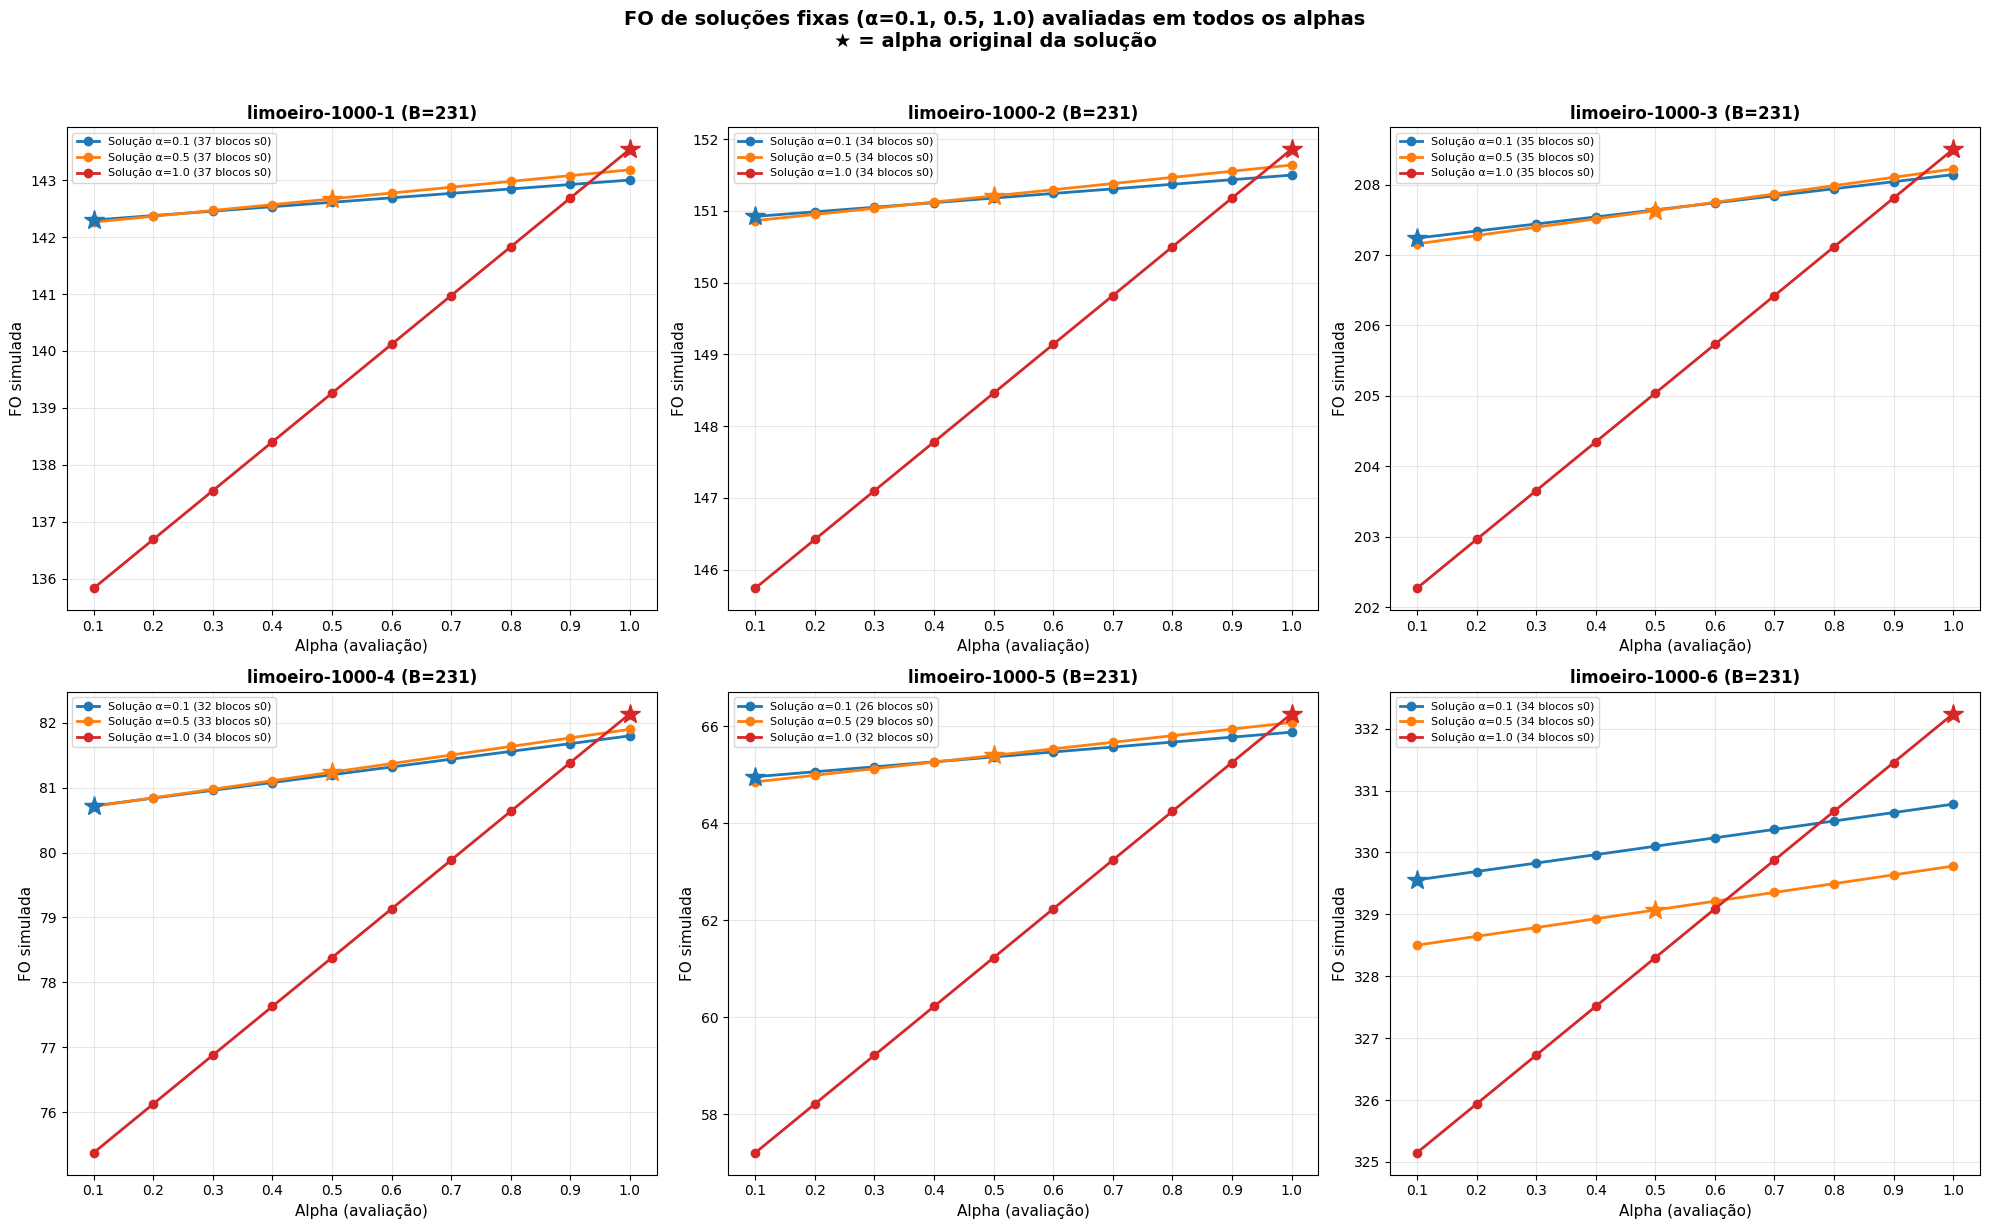

In [349]:
# Gráfico por instância: 6 painéis (um por limoeiro-2000-X)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

colors_fix = {0.1: "C0", 0.5: "C1", 1.0: "C3"}
labels_fix = {0.1: "Solução α=0.1", 0.5: "Solução α=0.5", 1.0: "Solução α=1.0"}

for idx, inst in enumerate(INSTANCES_SIM):
    ax = axes_flat[idx]
    inst_data = df_sim[df_sim["instance"] == inst]
    if inst_data.empty:
        ax.set_title(f"{inst} (sem dados)"); continue
    B_inst = inst_data["B"].iloc[0]

    for alpha_fix in ALPHA_FIXED:
        sub = inst_data[np.isclose(inst_data["alpha_solution"], alpha_fix)].sort_values("alpha_eval")
        if sub.empty:
            continue
        n_s0 = sub["blocks_s0"].iloc[0]
        ax.plot(sub["alpha_eval"], sub["FO"], "o-",
                color=colors_fix[alpha_fix], linewidth=2, markersize=6,
                label=f"{labels_fix[alpha_fix]} ({n_s0} blocos s0)")

    # Marcar o LB real obtido pelo SA em cada alpha
    for alpha_fix in ALPHA_FIXED:
        sub = inst_data[np.isclose(inst_data["alpha_solution"], alpha_fix)]
        row_self = sub[np.isclose(sub["alpha_eval"], alpha_fix)]
        if len(row_self) > 0:
            ax.plot(alpha_fix, row_self["FO"].values[0], "*",
                    color=colors_fix[alpha_fix], markersize=15, zorder=5)

    ax.set_xlabel("Alpha (avaliação)", fontsize=11)
    ax.set_ylabel("FO simulada", fontsize=11)
    ax.set_title(f"{inst} (B={B_inst})", fontsize=12, fontweight="bold")
    ax.set_xticks(ALPHA_EVAL)
    ax.legend(fontsize=8)

plt.suptitle("FO de soluções fixas (α=0.1, 0.5, 1.0) avaliadas em todos os alphas\n"
             "★ = alpha original da solução",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 12.2. Visão média: comportamento agregado

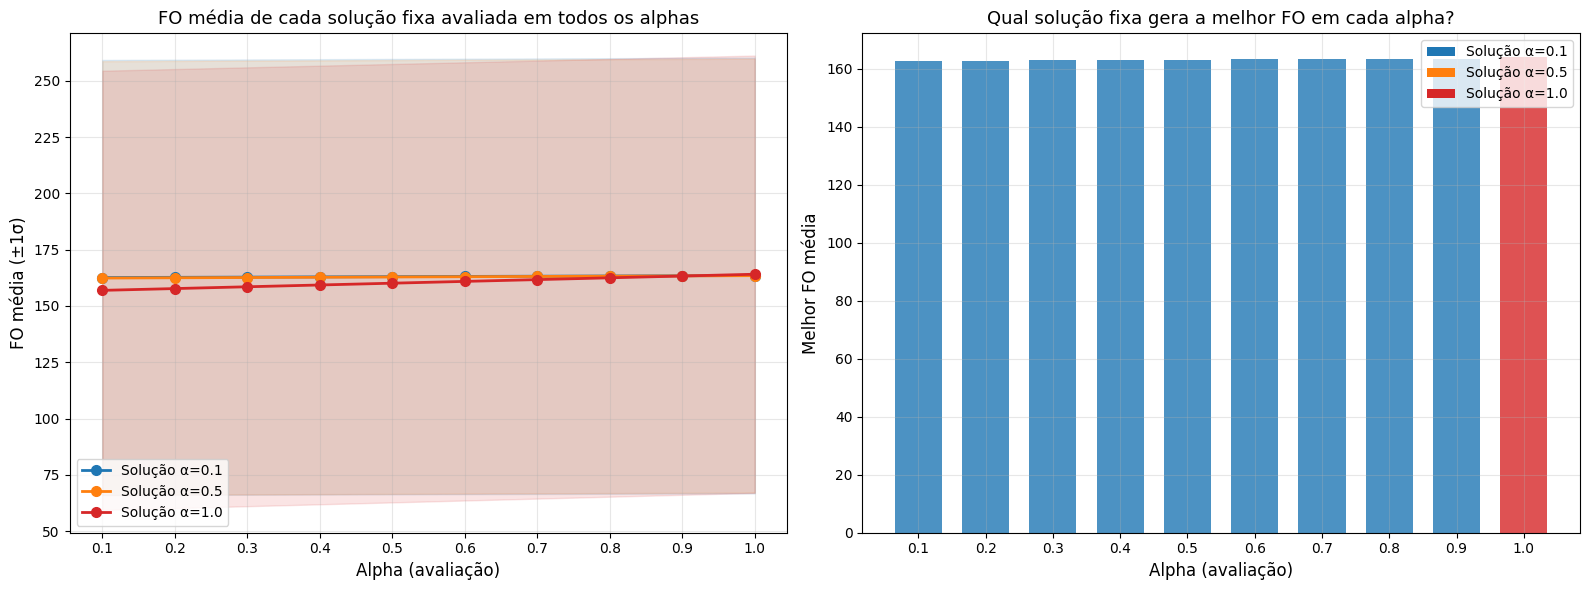

In [350]:
# Média de FO por alpha_eval e alpha_solution (agregando instâncias)
agg_sim = df_sim.groupby(["alpha_solution", "alpha_eval"]).agg(
    FO_medio=("FO", "mean"),
    FO_std=("FO", "std"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Esquerda: FO média por alpha_eval para cada solução fixa
ax = axes[0]
for alpha_fix in ALPHA_FIXED:
    sub = agg_sim[np.isclose(agg_sim["alpha_solution"], alpha_fix)].sort_values("alpha_eval")
    ax.plot(sub["alpha_eval"], sub["FO_medio"], "o-",
            color=colors_fix[alpha_fix], linewidth=2, markersize=7,
            label=labels_fix[alpha_fix])
    ax.fill_between(sub["alpha_eval"],
                     sub["FO_medio"] - sub["FO_std"],
                     sub["FO_medio"] + sub["FO_std"],
                     alpha=0.12, color=colors_fix[alpha_fix])
ax.set_xlabel("Alpha (avaliação)", fontsize=12)
ax.set_ylabel("FO média (±1σ)", fontsize=12)
ax.set_title("FO média de cada solução fixa avaliada em todos os alphas", fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(ALPHA_EVAL)

# Direita: Qual solução é melhor em cada alpha?
ax = axes[1]
for alpha_eval in ALPHA_EVAL:
    sub = agg_sim[np.isclose(agg_sim["alpha_eval"], alpha_eval)]
    if sub.empty:
        continue
    best = sub.loc[sub["FO_medio"].idxmax()]
    best_alpha_sol = min(ALPHA_FIXED, key=lambda a: abs(a - best["alpha_solution"]))
    ax.bar(alpha_eval, best["FO_medio"], width=0.07,
           color=colors_fix[best_alpha_sol], alpha=0.8)
ax.set_xlabel("Alpha (avaliação)", fontsize=12)
ax.set_ylabel("Melhor FO média", fontsize=12)
ax.set_title("Qual solução fixa gera a melhor FO em cada alpha?", fontsize=13)
ax.set_xticks(ALPHA_EVAL)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_fix[a], label=labels_fix[a]) for a in ALPHA_FIXED]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

### 12.3. Tabela numérica e decomposição do efeito

In [351]:
# Tabela por instância: FO de cada solução fixa avaliada em todos os alphas
for inst in INSTANCES_SIM:
    inst_data = df_sim[df_sim["instance"] == inst]
    B_inst = inst_data["B"].iloc[0]
    print(f"\n{'='*90}")
    print(f"  {inst} (B={B_inst})")
    print(f"{'='*90}")

    header = f"{'α_eval':>7}"
    for af in ALPHA_FIXED:
        sub_af = inst_data[np.isclose(inst_data["alpha_solution"], af)]
        n_s0 = sub_af["blocks_s0"].iloc[0] if len(sub_af) > 0 else "?"
        header += f" | {'Sol α='+str(af)+' ('+str(n_s0)+' bl)':>22}"
    header += " |  Melhor"
    print(header)
    print("-" * len(header))

    for ae in ALPHA_EVAL:
        row_str = f"{ae:>7.1f}"
        fos = {}
        for af in ALPHA_FIXED:
            sub = inst_data[np.isclose(inst_data["alpha_solution"], af) & np.isclose(inst_data["alpha_eval"], ae)]
            if len(sub) == 0:
                row_str += f" | {'N/A':>22}"; continue
            fo = sub["FO"].values[0]
            fos[af] = fo
            marker = " ★" if np.isclose(ae, af) else "  "
            row_str += f" | {fo:>20.3f}{marker}"
        best_af = max(fos, key=fos.get) if fos else "-"
        row_str += f" |  α={best_af}"
        print(row_str)

    # Resumo
    print(f"\n  Legenda: ★ = alpha original usado para obter essa solução")
    fo_diag = []
    for af in ALPHA_FIXED:
        sub = inst_data[np.isclose(inst_data["alpha_solution"], af) & np.isclose(inst_data["alpha_eval"], af)]
        fo_diag.append(sub["FO"].values[0] if len(sub) > 0 else float("nan"))
    print(f"  FO no alpha original: α=0.1→{fo_diag[0]:.3f}, α=0.5→{fo_diag[1]:.3f}, α=1.0→{fo_diag[2]:.3f}")


  limoeiro-1000-1 (B=231)
 α_eval |      Sol α=0.1 (37 bl) |      Sol α=0.5 (37 bl) |      Sol α=1.0 (37 bl) |  Melhor
--------------------------------------------------------------------------------------------
    0.1 |              142.298 ★ |              142.262   |              135.836   |  α=0.1
    0.2 |              142.376   |              142.364   |              136.692   |  α=0.1
    0.3 |              142.454   |              142.466   |              137.548   |  α=0.5
    0.4 |              142.532   |              142.568   |              138.404   |  α=0.5
    0.5 |              142.610   |              142.670 ★ |              139.260   |  α=0.5
    0.6 |              142.688   |              142.772   |              140.116   |  α=0.5
    0.7 |              142.766   |              142.874   |              140.972   |  α=0.5
    0.8 |              142.844   |              142.976   |              141.828   |  α=0.5
    0.9 |              142.922   |              143

### 12.4. Decomposição: contribuição do 1º e 2º estágio por alpha

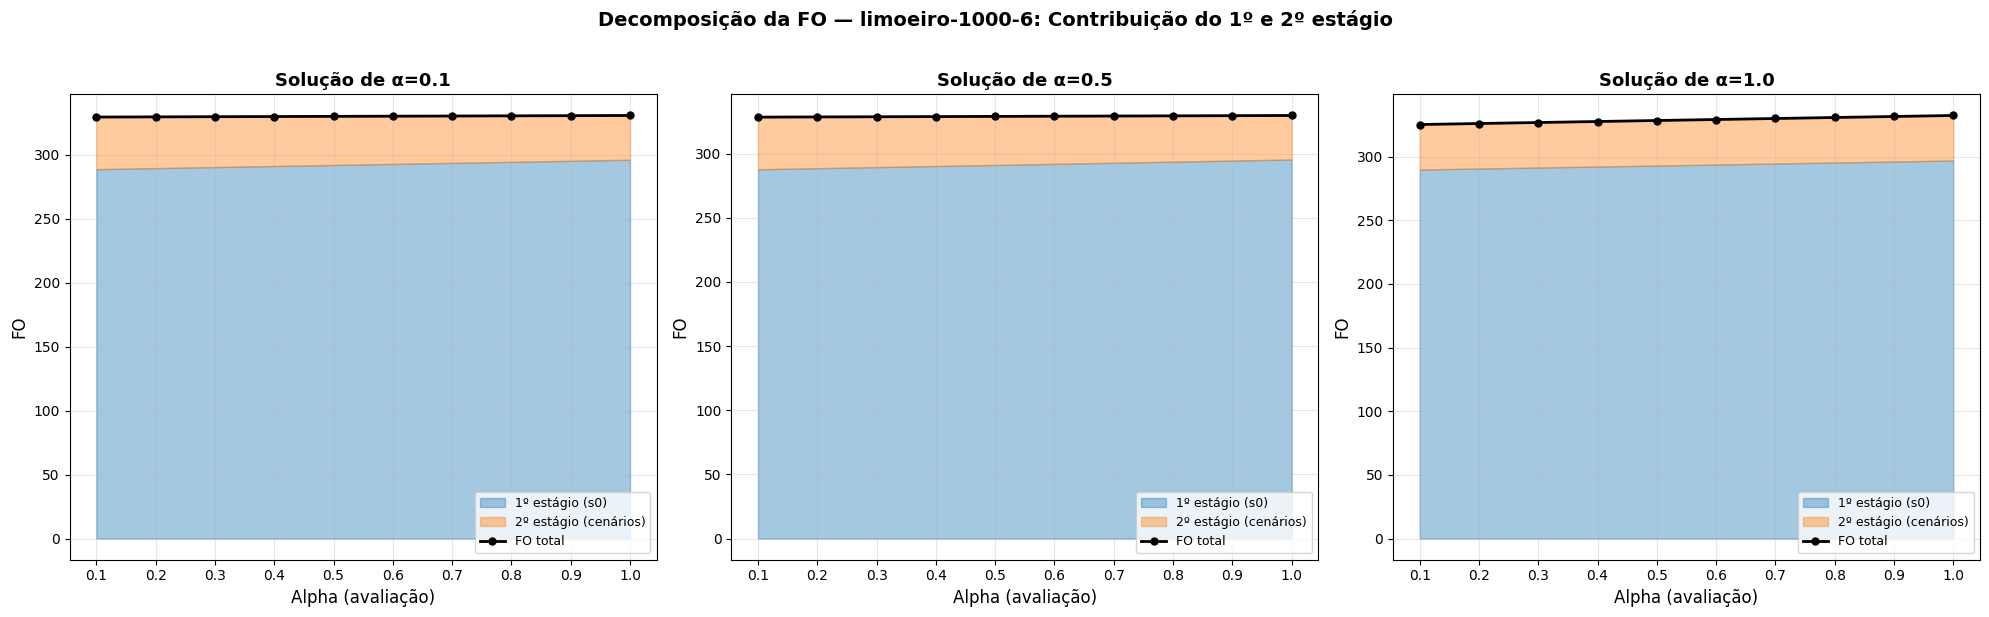


Decomposição numérica — limoeiro-1000-6

--- Solução obtida com α=0.1 ---
 α_eval      FO_s0      FO_ss   FO_total     %s0
    0.1     288.82      40.74     329.56   87.6%
    0.2     289.64      40.06     329.69   87.9%
    0.3     290.45      39.37     329.83   88.1%
    0.4     291.27      38.69     329.96   88.3%
    0.5     292.09      38.01     330.10   88.5%
    0.6     292.91      37.33     330.24   88.7%
    0.7     293.73      36.65     330.37   88.9%
    0.8     294.54      35.96     330.51   89.1%
    0.9     295.36      35.28     330.64   89.3%
    1.0     296.18      34.60     330.78   89.5%

--- Solução obtida com α=0.5 ---
 α_eval      FO_s0      FO_ss   FO_total     %s0
    0.1     287.85      40.66     328.50   87.6%
    0.2     288.69      39.95     328.64   87.8%
    0.3     289.54      39.25     328.79   88.1%
    0.4     290.38      38.54     328.93   88.3%
    0.5     291.23      37.84     329.07   88.5%
    0.6     292.08      37.14     329.21   88.7%
    0.7  

In [352]:
def decompose_fo(Y, cases_det, scenarios, alpha):
    """Decompor FO em contribuição do 1º estágio e 2º estágio."""
    S = len(scenarios)
    y0 = set(Y.get(0, []))
    fo_s0_total = 0.0
    fo_ss_total = 0.0

    for s_idx in range(S):
        cases_s = scenarios[s_idx]
        prob = 1.0 / S

        # First stage
        fo_s0 = sum(cases_det.get(b, 0) + alpha * cases_s.get(b, 0) for b in y0)

        # Second stage
        fo_ss = 0.0
        for b in Y.get(s_idx + 1, []):
            if b not in y0:
                fo_ss += cases_s.get(b, 0)
            else:
                fo_ss += (1.0 - alpha) * cases_s.get(b, 0)

        fo_s0_total += prob * fo_s0
        fo_ss_total += prob * fo_ss

    return fo_s0_total, fo_ss_total

# Decompor para uma instância representativa: limoeiro-2000-1
inst_decomp = "limoeiro-1000-6"
N, M, B, cases_det = parse_graph_cases(GRAPH_DIR / f"{inst_decomp}.txt")
S, scenarios = parse_scenario_cases(GRAPH_DIR / f"scenarios-{inst_decomp}.txt")

decomp_rows = []
for alpha_fix in ALPHA_FIXED:
    sa_file = SA_DIR / f"experiment-{alpha_fix}-5.0-100-1.1-50-moderate-0-0" / f"{inst_decomp}.txt"
    Y = parse_solution_blocks(sa_file)

    for alpha_eval in ALPHA_EVAL:
        fo_s0, fo_ss = decompose_fo(Y, cases_det, scenarios, alpha_eval)
        decomp_rows.append({
            "alpha_solution": alpha_fix,
            "alpha_eval": alpha_eval,
            "FO_s0": fo_s0,
            "FO_ss": fo_ss,
            "FO_total": fo_s0 + fo_ss,
            "pct_s0": 100 * fo_s0 / (fo_s0 + fo_ss) if (fo_s0 + fo_ss) > 0 else 0,
        })

df_decomp = pd.DataFrame(decomp_rows)

# Plot de decomposição
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, alpha_fix in enumerate(ALPHA_FIXED):
    ax = axes[idx]
    sub = df_decomp[np.isclose(df_decomp["alpha_solution"], alpha_fix)].sort_values("alpha_eval")

    ax.fill_between(sub["alpha_eval"], 0, sub["FO_s0"], alpha=0.4, color="C0", label="1º estágio (s0)")
    ax.fill_between(sub["alpha_eval"], sub["FO_s0"], sub["FO_total"], alpha=0.4, color="C1", label="2º estágio (cenários)")
    ax.plot(sub["alpha_eval"], sub["FO_total"], "o-", color="black", linewidth=2, markersize=5, label="FO total")

    ax.set_xlabel("Alpha (avaliação)", fontsize=12)
    ax.set_ylabel("FO", fontsize=12)
    ax.set_title(f"Solução de α={alpha_fix}", fontsize=13, fontweight="bold")
    ax.set_xticks(ALPHA_EVAL)
    ax.legend(fontsize=9, loc="lower right")

plt.suptitle(f"Decomposição da FO — {inst_decomp}: Contribuição do 1º e 2º estágio",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabela numérica
print(f"\nDecomposição numérica — {inst_decomp}")
for alpha_fix in ALPHA_FIXED:
    print(f"\n--- Solução obtida com α={alpha_fix} ---")
    print(f"{'α_eval':>7} {'FO_s0':>10} {'FO_ss':>10} {'FO_total':>10} {'%s0':>7}")
    sub = df_decomp[np.isclose(df_decomp["alpha_solution"], alpha_fix)].sort_values("alpha_eval")
    for _, r in sub.iterrows():
        print(f"{r['alpha_eval']:>7.1f} {r['FO_s0']:>10.2f} {r['FO_ss']:>10.2f} {r['FO_total']:>10.2f} {r['pct_s0']:>6.1f}%")

### 12.5. Diferença entre soluções: Qual solução é estruturalmente diferente?

In [353]:
# Comparar blocos no s0 entre as 3 soluções para cada instância
for inst in INSTANCES_SIM:
    graph_file = GRAPH_DIR / f"{inst}.txt"
    N, M, B, cases_det = parse_graph_cases(graph_file)
    S_inst, scenarios_inst = parse_scenario_cases(GRAPH_DIR / f"scenarios-{inst}.txt")

    solutions = {}
    for af in ALPHA_FIXED:
        sa_file = SA_DIR / f"experiment-{af}-5.0-100-1.1-50-moderate-0-0" / f"{inst}.txt"
        Y = parse_solution_blocks(sa_file)
        solutions[af] = set(Y.get(0, []))

    y01 = solutions[0.1]
    y05 = solutions[0.5]
    y10 = solutions[1.0]

    print(f"\n{'='*80}")
    print(f"  {inst} (B={B})")
    print(f"{'='*80}")
    print(f"  Blocos no s0: α=0.1 → {len(y01)},  α=0.5 → {len(y05)},  α=1.0 → {len(y10)}")
    print(f"  Interseção (0.1 ∩ 0.5):  {len(y01 & y05)} blocos")
    print(f"  Interseção (0.1 ∩ 1.0):  {len(y01 & y10)} blocos")
    print(f"  Interseção (0.5 ∩ 1.0):  {len(y05 & y10)} blocos")
    print(f"  Interseção (todos):       {len(y01 & y05 & y10)} blocos")
    print(f"  União (todos):            {len(y01 | y05 | y10)} blocos")

    # Blocos exclusivos
    only_01 = y01 - y05 - y10
    only_05 = y05 - y01 - y10
    only_10 = y10 - y01 - y05
    print(f"  Exclusivos α=0.1: {len(only_01)} blocos")
    print(f"  Exclusivos α=0.5: {len(only_05)} blocos")
    print(f"  Exclusivos α=1.0: {len(only_10)} blocos")

    # Comparar soma de casos determinísticos dos blocos em cada solução
    det_01 = sum(cases_det.get(b, 0) for b in y01)
    det_05 = sum(cases_det.get(b, 0) for b in y05)
    det_10 = sum(cases_det.get(b, 0) for b in y10)
    # Soma de casos estocásticos esperados
    exp_01 = sum(np.mean([scenarios_inst[s].get(b, 0) for s in range(S_inst)]) for b in y01)
    exp_05 = sum(np.mean([scenarios_inst[s].get(b, 0) for s in range(S_inst)]) for b in y05)
    exp_10 = sum(np.mean([scenarios_inst[s].get(b, 0) for s in range(S_inst)]) for b in y10)

    print(f"\n  Σ cases_det dos blocos s0: α=0.1 → {det_01},  α=0.5 → {det_05},  α=1.0 → {det_10}")
    print(f"  Σ E[cases_s] dos blocos s0: α=0.1 → {exp_01:.1f},  α=0.5 → {exp_05:.1f},  α=1.0 → {exp_10:.1f}")


  limoeiro-1000-1 (B=231)
  Blocos no s0: α=0.1 → 37,  α=0.5 → 37,  α=1.0 → 37
  Interseção (0.1 ∩ 0.5):  37 blocos
  Interseção (0.1 ∩ 1.0):  37 blocos
  Interseção (0.5 ∩ 1.0):  37 blocos
  Interseção (todos):       37 blocos
  União (todos):            37 blocos
  Exclusivos α=0.1: 0 blocos
  Exclusivos α=0.5: 0 blocos
  Exclusivos α=1.0: 0 blocos

  Σ cases_det dos blocos s0: α=0.1 → 103,  α=0.5 → 103,  α=1.0 → 103
  Σ E[cases_s] dos blocos s0: α=0.1 → 8.6,  α=0.5 → 8.6,  α=1.0 → 8.6

  limoeiro-1000-2 (B=231)
  Blocos no s0: α=0.1 → 34,  α=0.5 → 34,  α=1.0 → 34
  Interseção (0.1 ∩ 0.5):  34 blocos
  Interseção (0.1 ∩ 1.0):  34 blocos
  Interseção (0.5 ∩ 1.0):  34 blocos
  Interseção (todos):       34 blocos
  União (todos):            34 blocos
  Exclusivos α=0.1: 0 blocos
  Exclusivos α=0.5: 0 blocos
  Exclusivos α=1.0: 0 blocos

  Σ cases_det dos blocos s0: α=0.1 → 112,  α=0.5 → 112,  α=1.0 → 112
  Σ E[cases_s] dos blocos s0: α=0.1 → 6.8,  α=0.5 → 6.8,  α=1.0 → 6.8

  limoeiro-

### 12.6. Interpretação dos resultados da simulação

**O que esperamos observar:**

1. **Todas as curvas são lineares em alpha** para uma solução fixa. Isso é uma consequência direta da fórmula:
   - `FO(α) = [termos independentes de α] + α × [Σ_{b∈Y[0]} E[cases_s[b]]] - α × [Σ_{b∈Y[s]∩Y[0]} E[cases_s[b]]]`
   - Os termos com α são lineares → FO(α) é uma reta para uma solução fixa!

2. **Inclinação da reta depende da solução:**
   - Soluções com mais blocos no s0 que têm muitos casos nos cenários → inclinação mais positiva (1º estágio) mas perda mais negativa (2º estágio)
   - O efeito líquido depende do trade-off específico

3. **A solução de α=0.1 pode NÃO ser a melhor quando avaliada em α=1.0**, e vice-versa. Cada solução foi otimizada para o landscape do seu alpha original.

4. **O cruzamento das retas** indica onde uma estratégia passa a ser melhor que outra — isso reforça que não existe um alpha universalmente ótimo.

**Resultado principal:** O alpha não só muda a *avaliação* da solução, mas também muda *qual solução é ótima*. Dois efeitos se somam:
- **Efeito direto** (avaliação): a mesma solução vale diferente para diferentes alphas
- **Efeito indireto** (otimização): o SA busca em landscapes diferentes e encontra soluções estruturalmente distintas

/tmp/ipykernel_6716/380779155.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


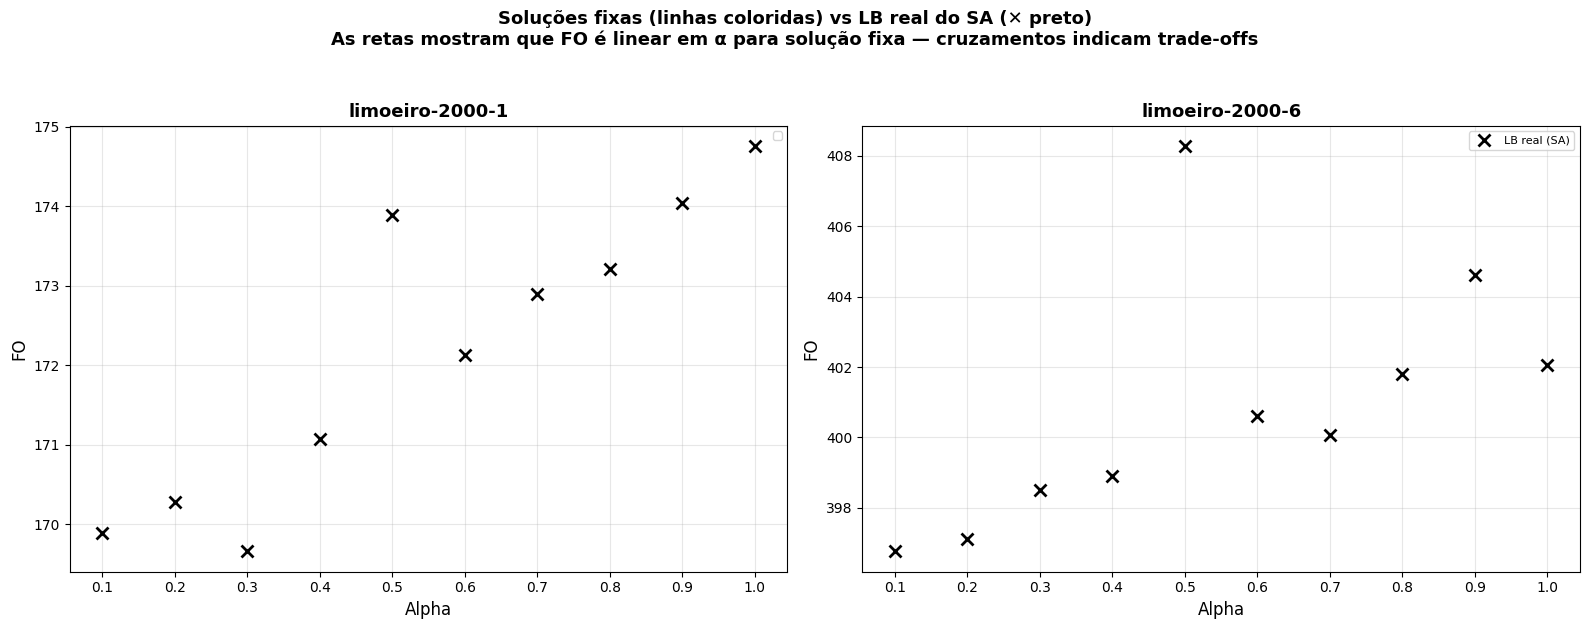

Verificação de linearidade (R² da regressão linear FO ~ α):

  limoeiro-2000-1:
    Sol α=0.1: FO = nan + nan×α  (R²=nan, inclinação=↓)
    Sol α=0.5: FO = nan + nan×α  (R²=nan, inclinação=↓)
    Sol α=1.0: FO = nan + nan×α  (R²=nan, inclinação=↓)

  limoeiro-2000-6:
    Sol α=0.1: FO = nan + nan×α  (R²=nan, inclinação=↓)
    Sol α=0.5: FO = nan + nan×α  (R²=nan, inclinação=↓)
    Sol α=1.0: FO = nan + nan×α  (R²=nan, inclinação=↓)


/tmp/ipykernel_6716/380779155.py:49: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, p, se = linregress(sub["alpha_eval"], sub["FO"])


In [354]:
# Gráfico final: Visualizar a linearidade + cruzamentos para limoeiro-2000-1 e limoeiro-2000-6
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, inst in zip(axes, ["limoeiro-2000-1", "limoeiro-2000-6"]):
    inst_data = df_sim[df_sim["instance"] == inst]

    for alpha_fix in ALPHA_FIXED:
        sub = inst_data[np.isclose(inst_data["alpha_solution"], alpha_fix)].sort_values("alpha_eval")
        if sub.empty:
            continue
        n_s0 = sub["blocks_s0"].iloc[0]
        ax.plot(sub["alpha_eval"], sub["FO"], "o-",
                color=colors_fix[alpha_fix], linewidth=2, markersize=6,
                label=f"Sol α={alpha_fix} ({n_s0} bl)")

    # Comparar com o LB real obtido pelo SA em cada alpha
    for a_eval in ALPHA_EVAL:
        real_row = df_all[(df_all["instance_name"]==inst) & (np.isclose(df_all["alpha"], a_eval))]
        if len(real_row) > 0:
            ax.plot(a_eval, real_row["LB"].values[0], "kx", markersize=8, markeredgewidth=2)

    ax.set_xlabel("Alpha", fontsize=12)
    ax.set_ylabel("FO", fontsize=12)
    ax.set_title(f"{inst}", fontsize=13, fontweight="bold")
    ax.set_xticks(ALPHA_EVAL)
    ax.legend(fontsize=8)

from matplotlib.lines import Line2D
custom = [Line2D([0], [0], marker="x", color="black", markersize=8, linestyle="None", markeredgewidth=2)]
axes[1].legend(
    axes[1].get_legend_handles_labels()[0] + custom,
    axes[1].get_legend_handles_labels()[1] + ["LB real (SA)"],
    fontsize=8
)

plt.suptitle("Soluções fixas (linhas coloridas) vs LB real do SA (✕ preto)\n"
             "As retas mostram que FO é linear em α para solução fixa — cruzamentos indicam trade-offs",
             fontweight="bold", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

# Verificar linearidade
print("Verificação de linearidade (R² da regressão linear FO ~ α):")
from scipy.stats import linregress
for inst in ["limoeiro-2000-1", "limoeiro-2000-6"]:
    print(f"\n  {inst}:")
    for af in ALPHA_FIXED:
        sub = df_sim[(df_sim["instance"]==inst) & (df_sim["alpha_solution"]==af)].sort_values("alpha_eval")
        slope, intercept, r, p, se = linregress(sub["alpha_eval"], sub["FO"])
        print(f"    Sol α={af}: FO = {intercept:.2f} + {slope:.2f}×α  (R²={r**2:.6f}, inclinação={'↑' if slope>0 else '↓'})")